## ComplyPilot JB - Final LangGraph State & Node Flow

### 0. 미션

이번 LangGraph 설계의 목표는 금융 대고객 콘텐츠를 업로드하면 AI Agent가 준법 리스크를 1차 검토하고, 근거 검색·수정안 생성·Guardrail 검증·조건부 Routing까지 수행하는 최종 Workflow를 검증하는 것이다.

ComplyPilot JB는 단순한 문구 탐지기가 아니라, 하나의 Agent State를 공유하는 여러 노드가 순차적으로 상태를 업데이트하고, 리스크 등급과 Guardrail 결과에 따라 다음 실행 경로를 선택하는 Routing + Reflection Hybrid Graph 구조를 가진다.

최종 목표 흐름은 다음과 같다.

input text/file
→ file intake
→ extract text
→ detect product/channel/language
→ user confirmation
→ map review criteria
→ detect risks
→ check missing disclaimers
→ retrieve evidence
→ judge risk
→ generate rewrite
→ check guardrail
→ route next action
→ report / retrieve retry / rewrite retry / HITL
→ save result
→ end

본 그래프의 핵심 목적은 다음과 같다.

금융 광고·마케팅 콘텐츠의 위험 표현과 필수 고지 누락 가능성을 탐지한다.
공개 금융규제 문서와 광고 가이드라인에서 관련 근거를 검색한다.
리스크 등급을 High / Medium / Low / Pass로 산정한다.
위험 문구에 대한 수정안과 필수 고지 문구를 생성한다.
AI가 생성한 수정안과 판단 결과를 Guardrail Checker로 재검증한다.
근거 부족 또는 수정안 오류가 발생하면 재검색 또는 재작성 루프로 되돌린다.
고위험, 근거 부족, 재시도 초과, OCR 불확실 건은 준법관리자 검토 대상으로 전환한다.

### 1. 최종 LangGraph 구조

ComplyPilot JB의 최종 그래프는 다음과 같은 노드로 구성된다.<br>

__start__<br>
→ file_intake<br>
→ text_extractor<br>
→ content_auto_detector<br>
→ user_confirmation<br>
→ review_criteria_mapper<br>
→ risk_detector<br>
→ disclaimer_checker<br>
→ evidence_retriever<br>
→ risk_judge<br>
→ rewrite_generator<br>
→ guardrail_checker<br>
→ routing<br>

routing 노드 이후에는 조건에 따라 다음 경로로 분기한다.<br>

routing
├─ report   → report_output → save_result → __end__<br>
├─ hitl     → hitl_review → save_result → __end__<br>
├─ retrieve → evidence_retriever 재검색 루프<br>
└─ rewrite  → rewrite_generator 재작성 루프<br>

이 구조는 단순 순차 그래프가 아니라, 리스크 등급과 Guardrail 상태에 따라 실행 경로가 달라지는 Routing Graph이며, 동시에 근거 부족·수정안 오류 발생 시 재검색/재작성 루프를 수행하는 Reflection 구조를 포함한다.

### 2. 환경 준비
2-1. 라이브러리 로딩<br>
목적: LangGraph Workflow 구현에 필요한 기본 라이브러리 로딩<br>
입력: 없음<br>
출력: Python 실행 환경<br>
처리:<br>
typing, pathlib, json, re, pandas 로딩<br>
LangGraph의 StateGraph, START, END 로딩<br>
필요 시 PDF, DOCX, OCR, RAG 관련 라이브러리 로딩<br>
2-2. 프로젝트 경로 설정<br>
목적: 노트북에서 프로젝트 내부 모듈과 데이터 파일을 안정적으로 불러오기<br>
입력: 현재 노트북 경로<br>
출력: PROJECT_ROOT<br>
처리:<br>
프로젝트 루트 경로 설정<br>
core/, graph/, data/ 경로 import 가능하게 구성<br>
JSON 룰 파일과 규정 문서 경로 확인

In [125]:
# ============================================================
# 2-1. 라이브러리 로딩
# 목적:
# - LangGraph Workflow 구현에 필요한 기본 라이브러리 로딩
# - PDF, DOCX, OCR, RAG, Vector DB 관련 라이브러리 로딩
# ============================================================

from __future__ import annotations

import os
import re
import sys
import json
from pathlib import Path
from typing import Any, TypedDict, Literal

import pandas as pd

from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END

# RAG / Vector DB 관련 라이브러리
from langchain_community.document_loaders import DirectoryLoader, PyMuPDFLoader
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_chroma import Chroma

# Legacy Chain / Memory 사용 시
from langchain_classic.chains import ConversationalRetrievalChain
from langchain_classic.memory import ConversationBufferMemory

In [126]:
# ============================================================
# 2-2. 프로젝트 경로 설정
# 목적:
# - 노트북에서 core/, graph/, data/ 모듈을 안정적으로 불러오기
# - JSON 룰 파일, 샘플 데이터, 규정 문서 경로를 고정
# ============================================================

def find_project_root(start_path: Path | None = None) -> Path:
    """
    현재 위치에서 상위 폴더로 올라가며 프로젝트 루트를 찾는다.

    프로젝트 루트 판단 기준:
    - README.md 또는 AGENTS.md가 있고
    - data/ 폴더가 존재하는 위치
    """
    current_path = (start_path or Path.cwd()).resolve()

    for path in [current_path, *current_path.parents]:
        has_marker = (path / "README.md").exists() or (path / "AGENTS.md").exists()
        has_data_dir = (path / "data").exists()

        if has_marker and has_data_dir:
            return path

    # 못 찾으면 현재 작업 디렉터리를 프로젝트 루트로 사용
    return current_path


PROJECT_ROOT = find_project_root()

# Python import 경로에 프로젝트 루트 추가
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
RULES_DIR = DATA_DIR / "rules"
REGULATIONS_DIR = DATA_DIR / "regulations"
SAMPLES_DIR = DATA_DIR / "samples"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
REPORTS_DIR = OUTPUTS_DIR / "reports"
VECTOR_DB_DIR = PROJECT_ROOT / "vector_db"

# 필요한 폴더가 없으면 생성
for directory in [DATA_DIR, RULES_DIR, REGULATIONS_DIR, SAMPLES_DIR, OUTPUTS_DIR, REPORTS_DIR, VECTOR_DB_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"✅ PROJECT_ROOT: {PROJECT_ROOT}")
print(f"✅ DATA_DIR: {DATA_DIR}")
print(f"✅ RULES_DIR: {RULES_DIR}")
print(f"✅ REGULATIONS_DIR: {REGULATIONS_DIR}")
print(f"✅ SAMPLES_DIR: {SAMPLES_DIR}")
print(f"✅ VECTOR_DB_DIR: {VECTOR_DB_DIR}")

✅ PROJECT_ROOT: C:\Users\USER\Desktop\complypilot-jb
✅ DATA_DIR: C:\Users\USER\Desktop\complypilot-jb\data
✅ RULES_DIR: C:\Users\USER\Desktop\complypilot-jb\data\rules
✅ REGULATIONS_DIR: C:\Users\USER\Desktop\complypilot-jb\data\regulations
✅ SAMPLES_DIR: C:\Users\USER\Desktop\complypilot-jb\data\samples
✅ VECTOR_DB_DIR: C:\Users\USER\Desktop\complypilot-jb\vector_db


In [127]:
# ============================================================
# 2-3. 환경변수 로딩
# 목적:
# - OPENAI_API_KEY 등 민감한 값을 .env에서 로드
# - API Key가 없어도 룰 기반 / BM25 fallback은 동작 가능하게 구성
# ============================================================

ENV_PATH = PROJECT_ROOT / ".env"

if ENV_PATH.exists():
    load_dotenv(ENV_PATH, override=True)
    print("✅ .env 파일 로딩 완료")
else:
    print("⚠️ .env 파일이 없습니다. OpenAI 기반 기능은 비활성화될 수 있습니다.")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if OPENAI_API_KEY:
    print("✅ OPENAI_API_KEY 확인 완료")
else:
    print("⚠️ OPENAI_API_KEY 없음: OpenAI Embedding/LLM 기능은 fallback으로 처리하세요.")

✅ .env 파일 로딩 완료
✅ OPENAI_API_KEY 확인 완료


In [128]:
# ============================================================
# 2-4. 주요 파일 경로 확인
# 목적:
# - 룰 JSON, 규정 문서, 샘플 입력 데이터가 있는지 확인
# ============================================================

rule_files = {
    "product_keywords": RULES_DIR / "product_keywords.json",
    "risk_rules": RULES_DIR / "risk_rules.json",
    "disclaimer_rules": RULES_DIR / "disclaimer_rules.json",
    "rewrite_templates": RULES_DIR / "rewrite_templates.json",
}

for name, path in rule_files.items():
    status = "✅ 존재" if path.exists() else "⚠️ 없음"
    print(f"{name}: {status} - {path}")

print("\n📄 regulations files:")
for file_path in REGULATIONS_DIR.glob("*"):
    print("-", file_path.name)

print("\n📁 sample files:")
for file_path in SAMPLES_DIR.rglob("*"):
    if file_path.is_file():
        print("-", file_path.relative_to(SAMPLES_DIR))

product_keywords: ✅ 존재 - C:\Users\USER\Desktop\complypilot-jb\data\rules\product_keywords.json
risk_rules: ✅ 존재 - C:\Users\USER\Desktop\complypilot-jb\data\rules\risk_rules.json
disclaimer_rules: ✅ 존재 - C:\Users\USER\Desktop\complypilot-jb\data\rules\disclaimer_rules.json
rewrite_templates: ✅ 존재 - C:\Users\USER\Desktop\complypilot-jb\data\rules\rewrite_templates.json

📄 regulations files:
- fair_advertising_law.txt
- financial_ad_guideline.txt
- financial_consumer_protection.txt

📁 sample files:
- high_investment_01.pdf
- high_loan_01.pdf
- K패스+신용카드_상품설명서.pdf
- low_card_01.pdf
- low_deposit_01.pdf
- low_loan_01.pdf
- medium_card_01.pdf
- medium_investment_01.pdf
- medium_loan_01.pdf
- pass_card_01.pdf
- pass_deposit_01.pdf
- pass_loan_01.pdf
- sample_high_risk.txt
- sample_missing_disclaimer.txt
- sample_normal.txt
- 가계대출 상품설명서.pdf
- 가계대출_상품설명서.pdf
- 부동산 담보대출 약관_개정_20260226시행.pdf
- 주택담보대출_상품설명서.pdf


### 3. Agent State Schema

각 노드는 하나의 ComplianceState를 공유한다.
이전 노드의 처리 결과는 State에 저장되고, 다음 노드는 해당 State를 이어받아 자신이 담당하는 필드만 업데이트한다.

목적: 전체 Agent Workflow에서 공유되는 상태값 정의
입력: 없음
출력: ComplianceState
처리:
파일 정보, 추출 텍스트, 상품/채널/언어 탐지 결과 저장
사용자 확인값과 검토 기준 저장
위험 표현, 누락 고지, RAG 근거, 리스크 등급 저장
수정안, Guardrail 결과, Routing 결과, 최종 Report 저장
재검색·재작성 반복 횟수와 HITL 필요 여부 저장

주요 State 항목은 다음과 같다.

File/Input:
- uploaded_file
- file_name
- file_type

Extraction:
- raw_text
- ocr_text
- extracted_text
- extraction_confidence

Detection:
- detected_product_type
- detected_channel
- detected_language
- confirmed_product_type
- confirmed_channel
- confirmed_language

Review:
- review_criteria
- optional_conditions
- sentences
- detected_risks
- missing_disclaimers

Evidence/Judgment:
- evidence_list
- evidence_score
- risk_level
- risk_reason
- review_required

Output/Control:
- rewrite_text
- required_disclaimer
- guardrail_status
- retry_count
- max_retry
- next_action
- report

In [129]:
# ============================================================
# 3. Agent State Schema
# 목적:
# - 전체 Agent Workflow에서 공유되는 상태값 정의
# - 각 노드는 자신이 담당하는 필드만 업데이트
# - 파일 처리, 추출, 탐지, 근거 검색, 판단, 수정안, Guardrail, Routing, 저장 결과를 관리
# ============================================================

from __future__ import annotations

from typing import Any, TypedDict, Literal


FileType = Literal["pdf", "docx", "txt", "image", "unknown"]
FileStatus = Literal[
    "ok",
    "missing",
    "invalid",
    "unreadable",
    "empty",
    "unsupported",
    "too_large",
    "no_input",
]

RiskLevel = Literal["Pass", "Low", "Medium", "High"]

EvidenceQuality = Literal["none", "weak", "sufficient", "strong"]

GuardrailStatus = Literal[
    "ok",
    "insufficient_evidence",
    "legal_assertion",
    "rewrite_needed",
    "extraction_check_required",
    "error",
]

NextAction = Literal["report", "rewrite", "retrieve", "hitl", "end"]

WorkflowStatus = Literal[
    "initialized",
    "running",
    "completed",
    "failed",
]


class ComplianceState(TypedDict, total=False):
    # Run Metadata
    run_id: str
    current_node: str
    workflow_status: WorkflowStatus
    created_at: str
    updated_at: str
    completed_at: str
    errors: list[dict[str, Any]]
    warnings: list[str]

    # File/Input
    uploaded_file: Any
    file_path: str
    file_name: str
    file_type: FileType
    file_ext: str
    mime_type: str
    file_size: int
    file_status: FileStatus
    is_supported_file: bool
    file_error: str
    input_mode: str

    # Extraction
    raw_text: str
    ocr_text: str
    extracted_text: str
    extraction_confidence: float
    extraction_method: str
    extraction_quality: dict[str, Any]

    # Detection
    detected_product_type: str
    detected_product_label: str
    detected_channel: str
    detected_language: str
    detection_detail: dict[str, Any]

    # User Confirmation
    user_product_type: str
    user_channel: str
    user_language: str
    confirmed_product_type: str
    confirmed_product_label: str
    confirmed_channel: str
    confirmed_channel_label: str
    confirmed_language: str
    confirmed_language_label: str
    confirmation_detail: dict[str, Any]

    # Review Criteria
    review_criteria: dict[str, Any]
    optional_conditions: dict[str, Any]

    # Risk Detection
    sentences: list[str]
    detected_risks: list[dict[str, Any]]
    risk_detection_summary: dict[str, Any]

    # Disclaimer Check
    disclaimer_results: list[dict[str, Any]]
    missing_disclaimers: list[dict[str, Any]]
    disclaimer_check_summary: dict[str, Any]

    # Evidence Retrieval
    evidence_queries: list[dict[str, Any]]
    evidence_list: list[dict[str, Any]]
    evidence_score: float
    evidence_quality: EvidenceQuality
    evidence_summary: dict[str, Any]

    # Judgment
    risk_level: RiskLevel
    risk_reason: str
    action_required: bool
    compliance_review_required: bool
    review_required: bool
    judgment_detail: dict[str, Any]

    # Rewrite
    rewrite_text: str
    required_disclaimer: str
    rewrite_detail: dict[str, Any]

    # Guardrail
    guardrail_status: GuardrailStatus
    needs_hitl: bool
    needs_rewrite: bool
    needs_retrieval_retry: bool
    guardrail_detail: dict[str, Any]

    # Routing
    retry_count: int
    retrieval_retry_count: int
    rewrite_retry_count: int
    max_retry: int
    next_action: NextAction
    routing_detail: dict[str, Any]

    # Report
    report: dict[str, Any]
    report_tables: dict[str, list[dict[str, Any]]]

    # HITL
    review_status: str
    hitl_detail: dict[str, Any]

    # Save Result
    saved_result: dict[str, Any]

    # End
    is_done: bool
    final_message: str
    final_result: dict[str, Any]

### 4. Node 1 - File Intake
목적: 업로드된 파일을 수집하고 파일 형식을 판별 <br>
입력: uploaded_file<br>
출력: file_name, file_type<br>
처리:<br>
파일명 추출<br>
확장자 또는 MIME type 확인<br>
PDF / DOCX / Image 지원 여부 검증<br>
지원하지 않는 형식이면 오류 상태 반환<br>
구현 방향: 룰 기반<br>
AI 사용 여부: 사용하지 않음<br>

In [130]:
# ============================================================
# 4. Node 1 - File Intake
# 목적:
# - 업로드 파일, 로컬 파일 경로, 직접 입력 텍스트를 확인
# - 파일명, 확장자, MIME type, 파일 크기, 지원 여부를 State에 저장
# ============================================================

from __future__ import annotations

from pathlib import Path
from datetime import datetime
from typing import Any


SUPPORTED_FILE_TYPES = {
    ".pdf": "pdf",
    ".docx": "docx",
    ".txt": "txt",
    ".png": "image",
    ".jpg": "image",
    ".jpeg": "image",
}

SUPPORTED_MIME_TYPES = {
    "application/pdf": "pdf",
    "application/vnd.openxmlformats-officedocument.wordprocessingml.document": "docx",
    "text/plain": "txt",
    "image/png": "image",
    "image/jpeg": "image",
}

MAX_FILE_SIZE_BYTES = 20 * 1024 * 1024  # 20MB


def now_iso() -> str:
    """
    현재 시간을 ISO 문자열로 반환한다.

    Args:
        없음

    Returns:
        str: ISO 형식의 현재 시간 문자열
    """
    return datetime.now().isoformat(timespec="seconds")


def resolve_project_path(path_value: str | Path | None) -> Path | None:
    """
    입력된 파일 경로를 프로젝트 루트 기준 경로로 변환한다.

    Args:
        path_value: 문자열 또는 Path 형태의 파일 경로

    Returns:
        Path | None: 해석된 파일 경로. 입력이 없으면 None
    """
    if not path_value:
        return None

    path = Path(path_value)

    if path.is_absolute():
        return path

    # 상대 경로는 프로젝트 루트 기준으로 해석한다.
    return PROJECT_ROOT / path


def get_uploaded_file_size(uploaded_file: Any) -> int | None:
    """
    Streamlit UploadedFile 객체 또는 유사 파일 객체의 크기를 확인한다.

    Args:
        uploaded_file: 업로드 파일 객체

    Returns:
        int | None: 파일 크기. 확인 실패 시 None
    """
    size = getattr(uploaded_file, "size", None)
    if isinstance(size, int):
        return size

    try:
        return len(uploaded_file.getvalue())
    except Exception:
        return None


def append_error(
    state: ComplianceState,
    node_name: str,
    error_type: str,
    message: str,
) -> None:
    """
    State에 에러 정보를 추가한다.

    Args:
        state: 현재 ComplianceState
        node_name: 에러가 발생한 노드명
        error_type: 에러 유형
        message: 에러 메시지

    Returns:
        None
    """
    state.setdefault("errors", [])
    state["errors"].append(
        {
            "node": node_name,
            "type": error_type,
            "message": message,
            "time": now_iso(),
        }
    )


def append_warning(state: ComplianceState, message: str) -> None:
    """
    State에 경고 메시지를 추가한다.

    Args:
        state: 현재 ComplianceState
        message: 경고 메시지

    Returns:
        None
    """
    state.setdefault("warnings", [])
    state["warnings"].append(message)


def set_file_error(
    state: ComplianceState,
    status: FileStatus,
    message: str,
    file_name: str = "",
    file_type: FileType = "unknown",
    file_ext: str = "",
    mime_type: str = "",
    file_size: int = 0,
    input_mode: str = "none",
) -> ComplianceState:
    """
    File Intake 단계의 오류 상태를 State에 기록한다.

    Args:
        state: 현재 ComplianceState
        status: 파일 처리 상태
        message: 오류 메시지
        file_name: 파일명
        file_type: 파일 유형
        file_ext: 파일 확장자
        mime_type: MIME type
        file_size: 파일 크기
        input_mode: 입력 모드

    Returns:
        ComplianceState: 오류 정보가 반영된 State
    """
    updated_state = dict(state)

    updated_state["current_node"] = "file_intake"
    updated_state["workflow_status"] = "failed"
    updated_state["updated_at"] = now_iso()

    updated_state["input_mode"] = input_mode
    updated_state["file_name"] = file_name
    updated_state["file_type"] = file_type
    updated_state["file_ext"] = file_ext
    updated_state["mime_type"] = mime_type
    updated_state["file_size"] = file_size
    updated_state["file_status"] = status
    updated_state["is_supported_file"] = False
    updated_state["file_error"] = message

    # 파일 입력 오류는 준법관리자 검토 대상이 아니라 입력 수정 대상
    updated_state["action_required"] = True
    updated_state["compliance_review_required"] = False
    updated_state["review_required"] = False

    # 다음 노드로 진행하지 않고 종료
    updated_state["next_action"] = "end"

    append_error(
        updated_state,
        node_name="file_intake",
        error_type=status,
        message=message,
    )

    return updated_state


def file_intake_node(state: ComplianceState) -> ComplianceState:
    """
    파일 또는 직접 입력 텍스트를 수집하고 파일 형식을 판별한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        ComplianceState: 파일 메타데이터와 파일 상태가 반영된 State
    """
    updated_state = dict(state)

    updated_state["current_node"] = "file_intake"
    updated_state["workflow_status"] = "running"
    updated_state["updated_at"] = now_iso()

    uploaded_file = updated_state.get("uploaded_file")
    file_path_value = updated_state.get("file_path")
    extracted_text = updated_state.get("extracted_text", "")

    file_name = ""
    file_size: int | None = None
    mime_type = ""
    input_mode = "none"

    resolved_file_path = resolve_project_path(file_path_value)

    # 1. Streamlit 업로드 파일
    if uploaded_file is not None:
        input_mode = "uploaded_file"
        file_name = getattr(uploaded_file, "name", None) or "uploaded_file"
        mime_type = getattr(uploaded_file, "type", "") or ""
        file_size = get_uploaded_file_size(uploaded_file)

    # 2. 로컬 파일 경로
    elif resolved_file_path is not None:
        input_mode = "file_path"
        file_name = resolved_file_path.name
        updated_state["file_path"] = str(resolved_file_path)

        if not resolved_file_path.exists():
            return set_file_error(
                state=updated_state,
                status="missing",
                message=f"파일을 찾을 수 없습니다: {resolved_file_path}",
                file_name=file_name,
                file_type="unknown",
                file_ext=resolved_file_path.suffix.lower(),
                mime_type="",
                file_size=0,
                input_mode=input_mode,
            )

        if not resolved_file_path.is_file():
            return set_file_error(
                state=updated_state,
                status="invalid",
                message=f"파일이 아닙니다: {resolved_file_path}",
                file_name=file_name,
                file_type="unknown",
                file_ext=resolved_file_path.suffix.lower(),
                mime_type="",
                file_size=0,
                input_mode=input_mode,
            )

        file_size = resolved_file_path.stat().st_size

        try:
            with resolved_file_path.open("rb") as file:
                file.read(1)
        except OSError as exc:
            return set_file_error(
                state=updated_state,
                status="unreadable",
                message=f"파일을 읽을 수 없습니다: {exc}",
                file_name=file_name,
                file_type="unknown",
                file_ext=resolved_file_path.suffix.lower(),
                mime_type="",
                file_size=file_size,
                input_mode=input_mode,
            )

    # 3. 직접 텍스트 입력
    elif extracted_text:
        input_mode = "direct_text"
        file_name = "direct_text.txt"
        file_size = len(extracted_text.encode("utf-8"))
        mime_type = "text/plain"

    # 4. 입력 없음
    else:
        return set_file_error(
            state=updated_state,
            status="no_input",
            message="업로드 파일, 파일 경로, 직접 입력 텍스트가 없습니다.",
            file_name="",
            file_type="unknown",
            file_ext="",
            mime_type="",
            file_size=0,
            input_mode="none",
        )

    file_ext = Path(file_name).suffix.lower()
    file_type = SUPPORTED_FILE_TYPES.get(file_ext)

    # 확장자 판별 실패 시 MIME type으로 보조 판별
    if file_type is None and mime_type:
        file_type = SUPPORTED_MIME_TYPES.get(mime_type)

    updated_state["input_mode"] = input_mode
    updated_state["file_name"] = file_name
    updated_state["file_ext"] = file_ext
    updated_state["mime_type"] = mime_type
    updated_state["file_size"] = file_size if file_size is not None else -1

    # 파일 크기 확인 실패
    if file_size is None:
        append_warning(updated_state, "파일 크기를 확인하지 못했습니다.")

    # 빈 파일 또는 빈 직접 입력
    if file_size == 0:
        return set_file_error(
            state=updated_state,
            status="empty",
            message="파일 또는 입력 텍스트가 비어 있습니다.",
            file_name=file_name,
            file_type=file_type or "unknown",
            file_ext=file_ext,
            mime_type=mime_type,
            file_size=0,
            input_mode=input_mode,
        )

    # 파일 크기 제한
    if file_size is not None and file_size > MAX_FILE_SIZE_BYTES:
        return set_file_error(
            state=updated_state,
            status="too_large",
            message=f"파일 크기가 제한을 초과했습니다: {file_size} bytes",
            file_name=file_name,
            file_type=file_type or "unknown",
            file_ext=file_ext,
            mime_type=mime_type,
            file_size=file_size,
            input_mode=input_mode,
        )

    # 지원하지 않는 파일 형식
    if file_type is None:
        return set_file_error(
            state=updated_state,
            status="unsupported",
            message=f"지원하지 않는 파일 형식입니다: {file_ext or mime_type or '확장자 없음'}",
            file_name=file_name,
            file_type="unknown",
            file_ext=file_ext,
            mime_type=mime_type,
            file_size=file_size or 0,
            input_mode=input_mode,
        )

    # 정상 처리
    updated_state["file_type"] = file_type
    updated_state["file_status"] = "ok"
    updated_state["is_supported_file"] = True
    updated_state["file_error"] = ""

    # direct_text는 이미 텍스트가 있으므로 Text Extractor에서 그대로 통과 가능
    if input_mode == "direct_text":
        updated_state["raw_text"] = extracted_text
        updated_state["extraction_method"] = "direct_text"
        updated_state["extraction_confidence"] = 1.0
        updated_state["extraction_quality"] = {
            "source": "direct_text",
            "text_length": len(extracted_text),
            "warnings": [],
        }

    return updated_state

In [131]:
# ============================================================
# data/samples 실제 파일 목록 확인
# ============================================================

sample_files = sorted([p for p in SAMPLES_DIR.rglob("*") if p.is_file()])

print(f"✅ sample file count: {len(sample_files)}")
print("-" * 100)

for idx, path in enumerate(sample_files, start=1):
    relative_path = path.relative_to(PROJECT_ROOT)
    print(f"{idx:02d}. {relative_path} | {path.suffix.lower()} | {path.stat().st_size:,} bytes")

✅ sample file count: 19
----------------------------------------------------------------------------------------------------
01. data\samples\high_investment_01.pdf | .pdf | 300,292 bytes
02. data\samples\high_loan_01.pdf | .pdf | 301,162 bytes
03. data\samples\K패스+신용카드_상품설명서.pdf | .pdf | 365,579 bytes
04. data\samples\low_card_01.pdf | .pdf | 302,230 bytes
05. data\samples\low_deposit_01.pdf | .pdf | 300,409 bytes
06. data\samples\low_loan_01.pdf | .pdf | 302,633 bytes
07. data\samples\medium_card_01.pdf | .pdf | 303,392 bytes
08. data\samples\medium_investment_01.pdf | .pdf | 303,564 bytes
09. data\samples\medium_loan_01.pdf | .pdf | 299,994 bytes
10. data\samples\pass_card_01.pdf | .pdf | 305,992 bytes
11. data\samples\pass_deposit_01.pdf | .pdf | 303,611 bytes
12. data\samples\pass_loan_01.pdf | .pdf | 303,152 bytes
13. data\samples\sample_high_risk.txt | .txt | 100 bytes
14. data\samples\sample_missing_disclaimer.txt | .txt | 68 bytes
15. data\samples\sample_normal.txt | .txt | 64

In [132]:
sample_pdf = next(p for p in sample_files if p.suffix.lower() == ".pdf")

state: ComplianceState = {
    "file_path": str(sample_pdf),
    "uploaded_file": None,
}

state_after_file_intake = file_intake_node(state)
state_after_file_intake

{'file_path': 'C:\\Users\\USER\\Desktop\\complypilot-jb\\data\\samples\\high_investment_01.pdf',
 'uploaded_file': None,
 'current_node': 'file_intake',
 'workflow_status': 'running',
 'updated_at': '2026-06-09T16:45:02',
 'input_mode': 'file_path',
 'file_name': 'high_investment_01.pdf',
 'file_ext': '.pdf',
 'mime_type': '',
 'file_size': 300292,
 'file_type': 'pdf',
 'file_status': 'ok',
 'is_supported_file': True,
 'file_error': ''}

### 5. Node 2 - Text Extractor
목적: PDF, Word, 이미지에서 분석 대상 문구 추출<br>
입력: uploaded_file, file_type<br>
출력: raw_text, ocr_text, extracted_text, extraction_confidence<br>
처리:<br>
PDF는 PyMuPDF로 텍스트 추출<br>
Word는 python-docx로 텍스트 추출<br>
이미지는 OCR로 문구 추출<br>
줄바꿈, 특수문자, 중복 공백 정리<br>
추출 신뢰도가 낮으면 extraction_check_required 후보 상태로 표시<br>
구현 방향: 문서 파서 + OCR 기반<br>
AI 사용 여부: 기본적으로 사용하지 않음

In [133]:
# ============================================================
# 5. Node 2 - Text Extractor
# 목적:
# - file_intake_node 이후 파일에서 텍스트 추출
# - raw_text에는 원본 추출 결과 보존
# - extracted_text에는 분석용 정제 텍스트 저장
# - PDF 추출 중 발생하는 연속 중복 줄, 깨진 줄 일부 완화
# ============================================================

from __future__ import annotations

import io
import os
import re
import json
import time
import unicodedata
from pathlib import Path
from typing import Any
from difflib import SequenceMatcher


SUPPORTED_EXTRACT_FILE_TYPES = ["pdf", "docx", "txt", "image"]


def normalize_whitespace(text: str) -> str:
    """
    공백과 특수 공백 문자를 정규화한다.

    Args:
        text: 원본 텍스트

    Returns:
        str: 공백이 정리된 텍스트
    """
    if not text:
        return ""

    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\u00a0", " ")
    text = text.replace("\ufeff", "")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n[ \t]+", "\n", text)
    text = re.sub(r"[ \t]+\n", "\n", text)
    text = re.sub(r"\n{4,}", "\n\n\n", text)

    return text.strip()


def normalize_line_for_duplicate_check(line: str) -> str:
    """
    중복 줄 비교를 위해 줄 텍스트를 단순화한다.

    Args:
        line: 한 줄 텍스트

    Returns:
        str: 비교용 정규화 텍스트
    """
    if not line:
        return ""

    line = unicodedata.normalize("NFKC", line)
    line = re.sub(r"\s+", "", line)
    line = re.sub(r"[^\w가-힣]", "", line)

    return line.lower()


def score_line_quality(line: str) -> float:
    """
    비슷한 중복 줄 중 더 품질이 좋은 줄을 고르기 위한 점수를 계산한다.

    Args:
        line: 한 줄 텍스트

    Returns:
        float: 줄 품질 점수
    """
    if not line:
        return 0.0

    score = 0.0
    stripped = line.strip()

    score += min(len(stripped) / 50, 5)

    if re.search(r"[.!?。]", stripped):
        score += 2.0

    if " " in stripped:
        score += 1.0

    if "·" in stripped or ":" in stripped:
        score += 0.5

    if len(stripped) <= 2:
        score -= 3.0

    # PDF 추출 중 생기는 조각 줄에 대한 약한 패널티
    if stripped in ["제", "다", "호", "□", "ㅇ"]:
        score -= 4.0

    return score


def choose_better_duplicate_line(previous_line: str, current_line: str) -> str:
    """
    연속 중복 또는 유사 중복 줄 중 더 나은 줄을 선택한다.

    Args:
        previous_line: 이전 줄
        current_line: 현재 줄

    Returns:
        str: 더 보존할 가치가 높은 줄
    """
    prev = previous_line.strip()
    curr = current_line.strip()

    if not prev:
        return curr

    if not curr:
        return prev

    # 예: "준법감시인 심의필" vs "준법감시인 심의필제"
    # 뒤에 한두 글자가 깨져 붙은 경우는 짧은 원문을 선호
    if curr.startswith(prev) and len(curr) - len(prev) <= 2:
        suffix = curr[len(prev):]
        if suffix in ["제", "다", "호"]:
            return prev

    if prev.startswith(curr) and len(prev) - len(curr) <= 2:
        suffix = prev[len(curr):]
        if suffix in ["제", "다", "호"]:
            return curr

    prev_score = score_line_quality(prev)
    curr_score = score_line_quality(curr)

    if curr_score > prev_score:
        return curr

    return prev


def is_near_duplicate_line(previous_line: str, current_line: str) -> bool:
    """
    두 줄이 연속 중복 또는 유사 중복인지 판단한다.

    Args:
        previous_line: 이전 줄
        current_line: 현재 줄

    Returns:
        bool: 중복 또는 유사 중복이면 True
    """
    prev_norm = normalize_line_for_duplicate_check(previous_line)
    curr_norm = normalize_line_for_duplicate_check(current_line)

    if not prev_norm or not curr_norm:
        return False

    if prev_norm == curr_norm:
        return True

    # 너무 짧은 줄은 과도하게 제거하지 않기 위해 별도 처리
    if len(prev_norm) <= 3 or len(curr_norm) <= 3:
        return False

    if prev_norm in curr_norm and abs(len(prev_norm) - len(curr_norm)) <= 3:
        return True

    if curr_norm in prev_norm and abs(len(prev_norm) - len(curr_norm)) <= 3:
        return True

    similarity = SequenceMatcher(None, prev_norm, curr_norm).ratio()

    return similarity >= 0.92


def remove_near_duplicate_lines(text: str) -> tuple[str, dict[str, Any]]:
    """
    PDF 추출 과정에서 생기는 연속 중복 줄을 제거한다.

    Args:
        text: 원본 추출 텍스트

    Returns:
        tuple[str, dict[str, Any]]: 중복 제거 텍스트와 처리 통계
    """
    if not text:
        return "", {
            "line_count_before": 0,
            "line_count_after": 0,
            "removed_duplicate_line_count": 0,
            "duplicate_line_ratio": 0.0,
        }

    lines = [line.strip() for line in text.splitlines()]
    lines = [line for line in lines if line]

    cleaned_lines: list[str] = []
    removed_count = 0

    for line in lines:
        if not cleaned_lines:
            cleaned_lines.append(line)
            continue

        previous_line = cleaned_lines[-1]

        if is_near_duplicate_line(previous_line, line):
            cleaned_lines[-1] = choose_better_duplicate_line(previous_line, line)
            removed_count += 1
            continue

        cleaned_lines.append(line)

    before_count = len(lines)
    after_count = len(cleaned_lines)

    duplicate_line_ratio = round(
        removed_count / before_count,
        3,
    ) if before_count else 0.0

    return "\n".join(cleaned_lines), {
        "line_count_before": before_count,
        "line_count_after": after_count,
        "removed_duplicate_line_count": removed_count,
        "duplicate_line_ratio": duplicate_line_ratio,
    }


def normalize_extracted_text(
    text: str,
    remove_duplicate_lines: bool = False,
) -> str:
    """
    추출 텍스트를 분석 가능한 형태로 정규화한다.

    Args:
        text: 원본 추출 텍스트
        remove_duplicate_lines: 연속 중복 줄 제거 여부

    Returns:
        str: 정규화된 텍스트
    """
    if not text:
        return ""

    text = normalize_whitespace(text)

    # 붙어버린 문장 일부 보정
    # 예: "상품입니다반드시" → "상품입니다 반드시"
    text = re.sub(r"(입니다|합니다|됩니다|있습니다|없습니다)(?=[가-힣])", r"\1 ", text)
    text = re.sub(r"([.!?])(?=[가-힣A-Za-z0-9])", r"\1 ", text)

    text = re.sub(r"\n{3,}", "\n\n", text)

    if remove_duplicate_lines:
        text, _ = remove_near_duplicate_lines(text)

    return text.strip()


def build_text_preview(text: str, max_length: int = 2000) -> str:
    """
    화면 표시용 preview 텍스트를 생성한다.

    Args:
        text: 전체 텍스트
        max_length: 최대 표시 길이

    Returns:
        str: preview 텍스트
    """
    if not text:
        return ""

    if len(text) <= max_length:
        return text

    return text[:max_length].rstrip() + "\n\n... [이하 생략]"


def analyze_text_quality(
    raw_text: str,
    cleaned_text: str,
    duplicate_stats: dict[str, Any] | None = None,
) -> dict[str, Any]:
    """
    추출 텍스트 품질을 분석한다.

    Args:
        raw_text: 원본 추출 텍스트
        cleaned_text: 정제된 텍스트
        duplicate_stats: 중복 줄 제거 통계

    Returns:
        dict[str, Any]: 텍스트 품질 정보
    """
    duplicate_stats = duplicate_stats or {}

    raw_text = raw_text or ""
    cleaned_text = cleaned_text or ""

    char_count = len(cleaned_text)
    raw_char_count = len(raw_text)

    lines = [line.strip() for line in cleaned_text.splitlines() if line.strip()]
    line_count = len(lines)
    unique_line_count = len(set(lines))

    unique_line_ratio = round(
        unique_line_count / line_count,
        3,
    ) if line_count else 0.0

    broken_chars = re.findall(r"[�□■◆◇●○◦▪▫]", cleaned_text)
    broken_char_ratio = round(
        len(broken_chars) / max(char_count, 1),
        4,
    )

    hangul_chars = re.findall(r"[가-힣]", cleaned_text)
    hangul_ratio = round(
        len(hangul_chars) / max(char_count, 1),
        4,
    )

    too_short = char_count < 30
    too_many_broken_chars = broken_char_ratio >= 0.03
    too_many_duplicates = duplicate_stats.get("duplicate_line_ratio", 0.0) >= 0.45

    needs_user_check = bool(
        too_short
        or too_many_broken_chars
        or too_many_duplicates
    )

    quality = {
        "raw_char_count": raw_char_count,
        "char_count": char_count,
        "line_count": line_count,
        "unique_line_count": unique_line_count,
        "unique_line_ratio": unique_line_ratio,
        "broken_char_count": len(broken_chars),
        "broken_char_ratio": broken_char_ratio,
        "hangul_ratio": hangul_ratio,
        "too_short": too_short,
        "too_many_broken_chars": too_many_broken_chars,
        "too_many_duplicates": too_many_duplicates,
        "needs_user_check": needs_user_check,
        "duplicate_stats": duplicate_stats,
        "preview_text": build_text_preview(cleaned_text),
    }

    return quality


def calculate_extraction_confidence(
    file_type: str,
    extraction_method: str,
    extraction_quality: dict[str, Any],
) -> float:
    """
    추출 신뢰도를 계산한다.

    Args:
        file_type: 파일 유형
        extraction_method: 추출 방식
        extraction_quality: 추출 품질 정보

    Returns:
        float: 0~1 사이 추출 신뢰도
    """
    if extraction_quality.get("too_short"):
        return 0.1

    base_score_map = {
        "pdf": 0.92,
        "docx": 0.95,
        "txt": 0.98,
        "image": 0.75,
    }

    score = base_score_map.get(file_type, 0.5)

    broken_char_ratio = float(extraction_quality.get("broken_char_ratio", 0.0))
    duplicate_line_ratio = float(
        extraction_quality.get("duplicate_stats", {}).get("duplicate_line_ratio", 0.0)
    )

    if broken_char_ratio > 0.01:
        score -= min(broken_char_ratio * 5, 0.25)

    # 중복은 정제 전 발생할 수 있으므로 강한 패널티는 주지 않음
    if duplicate_line_ratio > 0.3:
        score -= min((duplicate_line_ratio - 0.3) * 0.3, 0.1)

    if extraction_method in ["image_ocr", "naver_ocr"]:
        score -= 0.1

    if extraction_quality.get("needs_user_check"):
        score -= 0.15

    return round(max(0.0, min(1.0, score)), 3)


def get_file_bytes_from_state(state: ComplianceState) -> bytes | None:
    """
    state에서 업로드 파일 bytes를 가져온다.

    Args:
        state: 현재 ComplianceState

    Returns:
        bytes | None: 파일 bytes
    """
    uploaded_file = state.get("uploaded_file")

    if uploaded_file is None:
        return None

    if isinstance(uploaded_file, bytes):
        return uploaded_file

    if hasattr(uploaded_file, "getvalue"):
        return uploaded_file.getvalue()

    if hasattr(uploaded_file, "read"):
        try:
            if hasattr(uploaded_file, "seek"):
                uploaded_file.seek(0)

            data = uploaded_file.read()

            if hasattr(uploaded_file, "seek"):
                uploaded_file.seek(0)

            return data

        except Exception:
            return None

    return None


def extract_pdf_text(state: ComplianceState) -> tuple[str, dict[str, Any]]:
    """
    PDF에서 텍스트를 추출한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        tuple[str, dict[str, Any]]: 추출 텍스트와 메타 정보
    """
    try:
        import fitz

        file_bytes = get_file_bytes_from_state(state)
        file_path = state.get("file_path", "")

        if file_bytes:
            doc = fitz.open(stream=file_bytes, filetype="pdf")
        else:
            doc = fitz.open(file_path)

        page_texts = []

        with doc:
            page_count = len(doc)

            for page_index, page in enumerate(doc):
                page_text = page.get_text("text")
                page_texts.append(page_text)

        text = "\n\n".join(page_texts)

        return text, {
            "extraction_method": "pymupdf",
            "page_count": page_count,
            "error": "",
        }

    except Exception as exc:
        return "", {
            "extraction_method": "pymupdf",
            "page_count": 0,
            "error": f"PDF text extraction failed: {exc}",
        }


def extract_docx_text(state: ComplianceState) -> tuple[str, dict[str, Any]]:
    """
    DOCX에서 문단과 표 텍스트를 추출한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        tuple[str, dict[str, Any]]: 추출 텍스트와 메타 정보
    """
    try:
        from docx import Document

        file_bytes = get_file_bytes_from_state(state)
        file_path = state.get("file_path", "")

        if file_bytes:
            document = Document(io.BytesIO(file_bytes))
        else:
            document = Document(file_path)

        parts = []

        for paragraph in document.paragraphs:
            text = paragraph.text.strip()
            if text:
                parts.append(text)

        for table in document.tables:
            for row in table.rows:
                cells = [cell.text.strip() for cell in row.cells if cell.text.strip()]
                if cells:
                    parts.append(" | ".join(cells))

        return "\n".join(parts), {
            "extraction_method": "python-docx",
            "paragraph_count": len(document.paragraphs),
            "table_count": len(document.tables),
            "error": "",
        }

    except Exception as exc:
        return "", {
            "extraction_method": "python-docx",
            "paragraph_count": 0,
            "table_count": 0,
            "error": f"DOCX text extraction failed: {exc}",
        }


def extract_txt_text(state: ComplianceState) -> tuple[str, dict[str, Any]]:
    """
    TXT 파일에서 텍스트를 추출한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        tuple[str, dict[str, Any]]: 추출 텍스트와 메타 정보
    """
    file_bytes = get_file_bytes_from_state(state)
    file_path = state.get("file_path", "")

    encodings = ["utf-8", "cp949", "euc-kr", "latin-1"]

    try:
        if file_bytes:
            for encoding in encodings:
                try:
                    return file_bytes.decode(encoding), {
                        "extraction_method": f"txt_decode_{encoding}",
                        "encoding": encoding,
                        "error": "",
                    }
                except UnicodeDecodeError:
                    continue

            return file_bytes.decode("utf-8", errors="ignore"), {
                "extraction_method": "txt_decode_utf8_ignore",
                "encoding": "utf-8-ignore",
                "error": "",
            }

        path = Path(file_path)

        for encoding in encodings:
            try:
                return path.read_text(encoding=encoding), {
                    "extraction_method": f"txt_read_{encoding}",
                    "encoding": encoding,
                    "error": "",
                }
            except UnicodeDecodeError:
                continue

        return path.read_text(encoding="utf-8", errors="ignore"), {
            "extraction_method": "txt_read_utf8_ignore",
            "encoding": "utf-8-ignore",
            "error": "",
        }

    except Exception as exc:
        return "", {
            "extraction_method": "txt",
            "encoding": "",
            "error": f"TXT text extraction failed: {exc}",
        }


def extract_image_text(state: ComplianceState) -> tuple[str, dict[str, Any]]:
    """
    이미지 파일에서 OCR 텍스트를 추출한다.
    현재는 NAVER OCR 환경변수가 없으면 실패 상태를 반환한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        tuple[str, dict[str, Any]]: OCR 텍스트와 메타 정보
    """
    naver_ocr_url = os.getenv("NAVER_OCR_URL")
    naver_ocr_secret = os.getenv("NAVER_OCR_SECRET")

    if not naver_ocr_url or not naver_ocr_secret:
        return "", {
            "extraction_method": "image_ocr",
            "error": "NAVER_OCR_URL 또는 NAVER_OCR_SECRET 환경변수가 없습니다.",
        }

    try:
        import requests

        file_bytes = get_file_bytes_from_state(state)
        file_path = state.get("file_path", "")
        file_name = state.get("file_name", "uploaded_image")

        if not file_bytes and file_path:
            file_bytes = Path(file_path).read_bytes()

        if not file_bytes:
            return "", {
                "extraction_method": "naver_ocr",
                "error": "이미지 bytes를 읽을 수 없습니다.",
            }

        request_json = {
            "images": [
                {
                    "format": Path(file_name).suffix.replace(".", "") or "jpg",
                    "name": file_name,
                }
            ],
            "requestId": str(int(time.time() * 1000)),
            "version": "V2",
            "timestamp": int(time.time() * 1000),
        }

        files = {
            "file": (file_name, file_bytes),
            "message": (None, json.dumps(request_json), "application/json"),
        }

        headers = {
            "X-OCR-SECRET": naver_ocr_secret,
        }

        response = requests.post(
            naver_ocr_url,
            headers=headers,
            files=files,
            timeout=30,
        )
        response.raise_for_status()

        result = response.json()
        fields = result.get("images", [{}])[0].get("fields", [])

        texts = [
            field.get("inferText", "")
            for field in fields
            if field.get("inferText")
        ]

        return "\n".join(texts), {
            "extraction_method": "naver_ocr",
            "field_count": len(fields),
            "error": "",
        }

    except Exception as exc:
        return "", {
            "extraction_method": "naver_ocr",
            "error": f"Image OCR failed: {exc}",
        }


def extract_text_by_file_type(state: ComplianceState) -> tuple[str, dict[str, Any]]:
    """
    file_type에 따라 적절한 추출 함수를 실행한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        tuple[str, dict[str, Any]]: 원본 추출 텍스트와 추출 메타 정보
    """
    file_type = state.get("file_type", "unknown")

    if file_type == "pdf":
        return extract_pdf_text(state)

    if file_type == "docx":
        return extract_docx_text(state)

    if file_type == "txt":
        return extract_txt_text(state)

    if file_type == "image":
        return extract_image_text(state)

    return "", {
        "extraction_method": "unsupported",
        "error": f"지원하지 않는 file_type입니다: {file_type}",
    }


def finalize_extracted_text_for_state(
    raw_extracted_text: str,
    file_type: str,
) -> tuple[str, dict[str, Any], float]:
    """
    추출 텍스트를 state 저장용으로 정제하고 품질/신뢰도를 계산한다.

    Args:
        raw_extracted_text: 원본 추출 텍스트
        file_type: 파일 유형

    Returns:
        tuple[str, dict[str, Any], float]: 정제 텍스트, 품질 정보, 신뢰도
    """
    normalized_text = normalize_extracted_text(raw_extracted_text)

    # PDF는 중복 줄이 자주 발생하므로 연속 유사 중복 제거 적용
    if file_type == "pdf":
        deduped_text, duplicate_stats = remove_near_duplicate_lines(normalized_text)
    else:
        deduped_text = normalized_text
        duplicate_stats = {
            "line_count_before": len([line for line in normalized_text.splitlines() if line.strip()]),
            "line_count_after": len([line for line in normalized_text.splitlines() if line.strip()]),
            "removed_duplicate_line_count": 0,
            "duplicate_line_ratio": 0.0,
        }

    cleaned_text = normalize_extracted_text(deduped_text)

    extraction_quality = analyze_text_quality(
        raw_text=raw_extracted_text,
        cleaned_text=cleaned_text,
        duplicate_stats=duplicate_stats,
    )

    extraction_confidence = calculate_extraction_confidence(
        file_type=file_type,
        extraction_method="",
        extraction_quality=extraction_quality,
    )

    return cleaned_text, extraction_quality, extraction_confidence


def text_extractor_node(state: ComplianceState) -> ComplianceState:
    """
    파일에서 텍스트를 추출하고 분석용 텍스트를 정제한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        ComplianceState: raw_text, extracted_text, extraction_quality,
        extraction_confidence 등이 반영된 State
    """
    updated_state = dict(state)

    updated_state["current_node"] = "text_extractor"
    updated_state["workflow_status"] = "running"
    updated_state["updated_at"] = now_iso()

    file_status = updated_state.get("file_status")
    file_type = updated_state.get("file_type", "unknown")

    if file_status not in [None, "ok"]:
        warning_message = f"file_status가 ok가 아니므로 텍스트 추출을 건너뜁니다: {file_status}"
        updated_state.setdefault("warnings", []).append(warning_message)
        updated_state["raw_text"] = ""
        updated_state["extracted_text"] = ""
        updated_state["extraction_confidence"] = 0.0
        updated_state["extraction_method"] = "skipped"
        updated_state["extraction_quality"] = {
            "needs_user_check": True,
            "reason": warning_message,
        }
        return updated_state

    if file_type not in SUPPORTED_EXTRACT_FILE_TYPES:
        error_message = f"지원하지 않는 파일 유형입니다: {file_type}"
        updated_state.setdefault("warnings", []).append(error_message)
        updated_state["raw_text"] = ""
        updated_state["extracted_text"] = ""
        updated_state["extraction_confidence"] = 0.0
        updated_state["extraction_method"] = "unsupported"
        updated_state["extraction_quality"] = {
            "needs_user_check": True,
            "reason": error_message,
        }
        return updated_state

    raw_extracted_text, extraction_meta = extract_text_by_file_type(updated_state)

    extraction_method = extraction_meta.get("extraction_method", "unknown")
    extraction_error = extraction_meta.get("error", "")

    cleaned_text, extraction_quality, extraction_confidence = finalize_extracted_text_for_state(
        raw_extracted_text=raw_extracted_text,
        file_type=file_type,
    )

    extraction_confidence = calculate_extraction_confidence(
        file_type=file_type,
        extraction_method=extraction_method,
        extraction_quality=extraction_quality,
    )

    updated_state["raw_text"] = raw_extracted_text
    updated_state["ocr_text"] = raw_extracted_text if file_type == "image" else ""
    updated_state["extracted_text"] = cleaned_text
    updated_state["extraction_confidence"] = extraction_confidence
    updated_state["extraction_method"] = extraction_method
    updated_state["extraction_quality"] = {
        **extraction_quality,
        "extraction_meta": extraction_meta,
        "extraction_error": extraction_error,
    }

    if extraction_error:
        updated_state.setdefault("warnings", []).append(extraction_error)

    if extraction_quality.get("needs_user_check"):
        updated_state["action_required"] = True
        updated_state["compliance_review_required"] = False
        updated_state["review_required"] = False
        updated_state.setdefault("warnings", []).append(
            "텍스트 추출 품질 확인이 필요합니다."
        )

    return updated_state

In [134]:
test_state = {
    "file_path": "data/samples/가계대출 상품설명서.pdf",
    "retry_count": 0,
    "max_retry": 2,
}

state_after_file = file_intake_node(test_state)
state_after_extract = text_extractor_node(state_after_file)

print(state_after_extract["file_type"])
print(state_after_extract["extraction_method"])
print(state_after_extract["extraction_confidence"])
print(state_after_extract["extraction_quality"])
print(state_after_extract["extracted_text"][:1000])

pdf
pymupdf
0.92
{'raw_char_count': 19934, 'char_count': 17871, 'line_count': 702, 'unique_line_count': 336, 'unique_line_ratio': 0.479, 'broken_char_count': 85, 'broken_char_ratio': 0.0048, 'hangul_ratio': 0.6714, 'too_short': False, 'too_many_broken_chars': False, 'too_many_duplicates': False, 'needs_user_check': False, 'duplicate_stats': {'line_count_before': 712, 'line_count_after': 702, 'removed_duplicate_line_count': 10, 'duplicate_line_ratio': 0.014}, 'preview_text': '은행용\n\uf02a\uf031\uf031\uf031\uf030\uf039\uf030\uf030\uf035\uf030\uf02a\n준법감시인 심의필 제2018-나-195호 (심의일 : 2018. 4. 17. 현재)\n가계대출 상품설명서\n1\n상품 개요 및 상품의 특성\n⋅상품명 :\n⋅대출신청금액 : 원\n⋅적용예정금리(보증료율) : %\n⋅금리적용방식 : □ 변동 □ 고정\n⋅대출기간 : 취급 후 개월\n⋅예상 실질유효금리 : %\n이 설명서는 은행이용자의 상품에 대한 이해를 돕고 약관의 중요내용을 알려드리기 위한 참고자료이며, 실제\n계약은 대출거래약정서(가계용), 여신거래기본약관(가계용)이 적용됩니다. 계약을 신청하는 경우 약관이, 계약을\n체결하는 경우 계약서류가 교부됩니다.\n은행은 금융소비자 보호를 위하여 대출거래의 주요내용 및 고객부담비용에 대하여 충분히 설명하여야 하며, 특\n히 취약한 금융소비자에 대해서는 금융소비자의 불이익사항을 다른 정보보다 우선적으로 설명하고 그 이해여부\n를 확인하여야 합니다.

> 문제점: 입력 데이터 글자가 깨지는 문제 발생

### 6. Node 3 - Content Auto Detector
목적: 추출 문구를 기반으로 상품 유형, 콘텐츠 채널, 사용 언어 자동 탐지<br>
입력: extracted_text, file_type<br>
출력: detected_product_type, detected_channel, detected_language<br>
처리:<br>
product_keywords.json 기반 상품 유형 탐지<br>
예금 / 대출 / 카드 / 투자 / 이벤트 키워드 매칭<br>
파일 형식과 문구 길이로 채널 추정<br>
한글 포함 여부로 언어 탐지<br>
애매한 경우 사용자 확인 단계로 넘김<br>
구현 방향: 룰 기반 + AI 보조 가능<br>
AI 사용 여부: 선택적으로 사용

In [135]:
# ============================================================
# 6. Node 3 - Content Auto Detector
# 목적:
# - 추출 문구를 기반으로 상품 유형, 콘텐츠 채널, 사용 언어 자동 탐지
# - product_keywords.json 기반 탐지를 우선 사용
# - JSON이 없거나 비어 있으면 fallback 키워드 사용
# ============================================================

from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Any


DEFAULT_PRODUCT_RULES = {
    "loan": {
        "label_ko": "대출",
        "keywords": [
            "대출", "신용대출", "가계대출", "주택담보대출", "담보대출",
            "전세자금대출", "한도", "상환", "금리", "이자", "신용도",
            "신용점수", "승인", "심사", "연체", "중도상환수수료"
        ],
        "strong_keywords": [
            "대출금리", "대출한도", "대출심사", "대출승인", "상환방식"
        ],
    },
    "deposit": {
        "label_ko": "예금",
        "keywords": [
            "예금", "적금", "정기예금", "정기적금", "우대금리",
            "만기", "납입", "이자율", "예치", "가입기간"
        ],
        "strong_keywords": [
            "정기예금", "정기적금", "우대금리", "만기이자"
        ],
    },
    "card": {
        "label_ko": "카드",
        "keywords": [
            "카드", "신용카드", "체크카드", "연회비", "전월실적",
            "캐시백", "포인트", "할인", "청구할인", "가맹점",
            "리볼빙", "교통카드", "K패스"
        ],
        "strong_keywords": [
            "신용카드", "체크카드", "전월실적", "연회비", "카드혜택", "청구할인"
        ],
    },
    "investment": {
        "label_ko": "투자",
        "keywords": [
            "투자", "펀드", "수익률", "원금", "손실", "주식",
            "채권", "ETF", "ELS", "파생", "위험등급", "투자위험"
        ],
        "strong_keywords": [
            "원금손실", "투자위험", "수익률", "펀드", "ELS", "ETF"
        ],
    },
    "event": {
        "label_ko": "이벤트",
        "keywords": [
            "이벤트", "혜택", "쿠폰", "경품", "응모", "추첨",
            "지급", "기간", "대상고객", "프로모션", "증정", "사은품"
        ],
        "strong_keywords": [
            "이벤트기간", "대상고객", "혜택지급", "응모", "프로모션"
        ],
    },
}


PRODUCT_LABELS = {
    "loan": "대출",
    "deposit": "예금",
    "card": "카드",
    "investment": "투자",
    "event": "이벤트",
    "unknown": "확인 필요",
}


CHANNEL_LABELS = {
    "document": "문서형 콘텐츠",
    "sns_cardnews": "SNS 카드뉴스",
    "app_banner": "앱 배너",
    "homepage": "홈페이지/랜딩페이지",
    "general_text": "일반 텍스트",
    "unknown": "확인 필요",
}


LANGUAGE_LABELS = {
    "ko": "한국어",
    "en": "영어",
    "ko-en": "한영 혼합",
    "unknown": "확인 필요",
}


def normalize_for_match(text: str) -> str:
    """
    키워드 매칭을 위해 공백과 일부 특수문자를 제거한다.

    Args:
        text: 원본 텍스트

    Returns:
        str: 매칭용 정규화 텍스트
    """
    if not text:
        return ""

    text = text.lower()
    text = re.sub(r"\s+", "", text)
    text = re.sub(r"[·ㆍ\-_()/\[\]{}]", "", text)

    return text


def load_product_keyword_rules() -> dict[str, dict[str, Any]]:
    """
    product_keywords.json에서 상품 유형별 키워드 룰을 로딩한다.

    지원 구조:
    1. {"product_types": {"loan": {"label_ko": "...", "keywords": [...], "strong_keywords": [...]}}}
    2. {"products": {"loan": [...]}}
    3. {"loan": [...]}

    Returns:
        dict[str, dict[str, Any]]: 상품 유형별 키워드 룰
    """
    rule_path = RULES_DIR / "product_keywords.json"

    if not rule_path.exists():
        return DEFAULT_PRODUCT_RULES

    try:
        with rule_path.open("r", encoding="utf-8") as file:
            data = json.load(file)

        if not isinstance(data, dict) or not data:
            return DEFAULT_PRODUCT_RULES

        if isinstance(data.get("product_types"), dict):
            raw_rules = data["product_types"]

        elif isinstance(data.get("products"), dict):
            raw_rules = data["products"]

        elif data.get("products") == []:
            return DEFAULT_PRODUCT_RULES

        else:
            raw_rules = data

        normalized_rules: dict[str, dict[str, Any]] = {}

        for product_type, value in raw_rules.items():
            if product_type in ["schema_version", "channels", "languages"]:
                continue

            if isinstance(value, list):
                normalized_rules[product_type] = {
                    "label_ko": PRODUCT_LABELS.get(product_type, product_type),
                    "keywords": [str(keyword) for keyword in value],
                    "strong_keywords": [],
                }

            elif isinstance(value, dict):
                keywords = value.get("keywords", [])
                strong_keywords = value.get("strong_keywords", [])
                label_ko = value.get("label_ko", PRODUCT_LABELS.get(product_type, product_type))

                if isinstance(keywords, list):
                    normalized_rules[product_type] = {
                        "label_ko": label_ko,
                        "keywords": [str(keyword) for keyword in keywords],
                        "strong_keywords": [str(keyword) for keyword in strong_keywords]
                        if isinstance(strong_keywords, list)
                        else [],
                    }

        return normalized_rules or DEFAULT_PRODUCT_RULES

    except Exception as exc:
        return DEFAULT_PRODUCT_RULES


def detect_language(text: str) -> tuple[str, dict[str, Any]]:
    """
    텍스트의 언어를 한글/영문 문자 비율 기반으로 탐지한다.

    Args:
        text: 추출 텍스트

    Returns:
        tuple[str, dict[str, Any]]: 언어 코드와 탐지 상세 정보
    """
    if not text.strip():
        return "unknown", {
            "korean_count": 0,
            "english_count": 0,
            "confidence": 0.0,
            "reason": "텍스트가 비어 있습니다.",
        }

    korean_count = len(re.findall(r"[가-힣]", text))
    english_count = len(re.findall(r"[A-Za-z]", text))
    total_letters = korean_count + english_count

    if total_letters == 0:
        return "unknown", {
            "korean_count": korean_count,
            "english_count": english_count,
            "confidence": 0.0,
            "reason": "한글 또는 영문 문자가 거의 없습니다.",
        }

    korean_ratio = korean_count / total_letters
    english_ratio = english_count / total_letters

    if korean_count > 0 and english_count > korean_count * 0.5:
        language = "ko-en"
        confidence = round(max(korean_ratio, english_ratio), 3)
        reason = "한글과 영문이 함께 포함되어 있습니다."

    elif korean_count > 0:
        language = "ko"
        confidence = round(korean_ratio, 3)
        reason = "한글 비율이 높습니다."

    elif english_count > 0:
        language = "en"
        confidence = round(english_ratio, 3)
        reason = "영문 비율이 높습니다."

    else:
        language = "unknown"
        confidence = 0.0
        reason = "언어를 판단할 수 없습니다."

    return language, {
        "korean_count": korean_count,
        "english_count": english_count,
        "korean_ratio": round(korean_ratio, 3),
        "english_ratio": round(english_ratio, 3),
        "confidence": confidence,
        "reason": reason,
    }


def score_keyword_matches(text: str, keywords: list[str], weight: int = 1) -> tuple[int, list[str]]:
    """
    키워드 목록을 기준으로 매칭 점수와 매칭 키워드를 계산한다.

    Args:
        text: 원본 텍스트
        keywords: 키워드 목록
        weight: 키워드 가중치

    Returns:
        tuple[int, list[str]]: 점수와 매칭된 키워드 목록
    """
    normalized_text = normalize_for_match(text)

    score = 0
    matched_keywords = []

    for keyword in keywords:
        keyword = str(keyword).strip()
        if not keyword:
            continue

        normalized_keyword = normalize_for_match(keyword)

        raw_count = text.count(keyword)
        normalized_count = normalized_text.count(normalized_keyword) if normalized_keyword else 0
        count = max(raw_count, normalized_count)

        if count > 0:
            score += count * weight
            matched_keywords.append(keyword)

    return score, matched_keywords


def detect_product_type(text: str) -> tuple[str, str, dict[str, Any]]:
    """
    상품 유형을 키워드 점수 기반으로 탐지한다.

    Args:
        text: 추출 텍스트

    Returns:
        tuple[str, str, dict[str, Any]]: 상품 유형, 한글 라벨, 상세 정보
    """
    product_rules = load_product_keyword_rules()
    scores: dict[str, dict[str, Any]] = {}

    for product_type, rule in product_rules.items():
        keywords = rule.get("keywords", [])
        strong_keywords = rule.get("strong_keywords", [])

        weak_score, weak_matches = score_keyword_matches(text, keywords, weight=1)
        strong_score, strong_matches = score_keyword_matches(text, strong_keywords, weight=3)

        total_score = weak_score + strong_score
        matched_keywords = sorted(set(weak_matches + strong_matches))

        scores[product_type] = {
            "score": total_score,
            "weak_score": weak_score,
            "strong_score": strong_score,
            "matched_keywords": matched_keywords,
            "label_ko": rule.get("label_ko", PRODUCT_LABELS.get(product_type, product_type)),
        }

    sorted_scores = sorted(
        scores.items(),
        key=lambda item: item[1]["score"],
        reverse=True,
    )

    if not sorted_scores or sorted_scores[0][1]["score"] == 0:
        return "unknown", "확인 필요", {
            "scores": scores,
            "best_score": 0,
            "second_score": 0,
            "confidence": 0.0,
            "ambiguous": True,
            "reason": "상품 유형 키워드가 탐지되지 않았습니다.",
        }

    best_product = sorted_scores[0][0]
    best_score = sorted_scores[0][1]["score"]
    second_score = sorted_scores[1][1]["score"] if len(sorted_scores) > 1 else 0

    margin = best_score - second_score

    ambiguous = (
        second_score > 0
        and (
            margin <= 2
            or best_score <= second_score * 1.3
        )
    )

    confidence = min(1.0, best_score / 10)

    if ambiguous:
        confidence = min(confidence, 0.65)

    confidence = round(confidence, 3)

    label = scores[best_product].get("label_ko", PRODUCT_LABELS.get(best_product, best_product))

    return best_product, label, {
        "scores": scores,
        "best_product": best_product,
        "best_score": best_score,
        "second_score": second_score,
        "margin": margin,
        "confidence": confidence,
        "ambiguous": ambiguous,
        "reason": "상위 상품 유형 점수가 유사합니다." if ambiguous else "상품 키워드 점수 기준으로 탐지되었습니다.",
    }


def detect_channel(text: str, file_type: str, file_name: str = "") -> tuple[str, str, dict[str, Any]]:
    """
    파일 형식, 파일명, 텍스트 길이와 키워드 기반으로 콘텐츠 채널을 추정한다.

    Args:
        text: 추출 텍스트
        file_type: 파일 유형
        file_name: 파일명

    Returns:
        tuple[str, str, dict[str, Any]]: 채널 코드, 채널 라벨, 상세 정보
    """
    text_length = len(text or "")
    lower_text = (text or "").lower()
    lower_name = (file_name or "").lower()

    homepage_keywords = [
        "신청하기", "자세히 보기", "가입하기", "상담하기", "바로가기",
        "홈페이지", "랜딩", "이벤트페이지"
    ]

    sns_keywords = [
        "인스타", "instagram", "페이스북", "facebook", "블로그", "blog",
        "유튜브", "youtube", "sns", "카카오", "채널"
    ]

    banner_keywords = [
        "배너", "banner", "팝업", "popup", "앱", "app", "메인화면"
    ]

    cardnews_keywords = [
        "카드뉴스", "cardnews", "카드 뉴스"
    ]

    # 문서형 파일은 기본 document
    if file_type in ["pdf", "docx"]:
        return "document", CHANNEL_LABELS["document"], {
            "reason": "PDF/DOCX 파일 형식이므로 문서형 콘텐츠로 추정했습니다.",
            "text_length": text_length,
            "confidence": 0.95,
        }

    # TXT는 내용에 따라 분기
    if file_type == "txt":
        if any(keyword in lower_text for keyword in homepage_keywords):
            return "homepage", CHANNEL_LABELS["homepage"], {
                "reason": "가입/상담/상세보기 등 랜딩페이지 키워드가 포함되어 있습니다.",
                "text_length": text_length,
                "confidence": 0.8,
            }

        if any(keyword in lower_text for keyword in sns_keywords):
            return "sns_cardnews", CHANNEL_LABELS["sns_cardnews"], {
                "reason": "SNS 관련 키워드가 포함되어 있습니다.",
                "text_length": text_length,
                "confidence": 0.75,
            }

        return "general_text", CHANNEL_LABELS["general_text"], {
            "reason": "TXT 파일이며 특정 채널 키워드가 없어 일반 텍스트로 추정했습니다.",
            "text_length": text_length,
            "confidence": 0.6,
        }

    # 이미지 파일은 파일명과 길이로 카드뉴스/배너 구분
    if file_type == "image":
        if any(keyword in lower_name for keyword in banner_keywords):
            return "app_banner", CHANNEL_LABELS["app_banner"], {
                "reason": "파일명에 배너/앱 관련 키워드가 포함되어 있습니다.",
                "text_length": text_length,
                "confidence": 0.85,
            }

        if any(keyword in lower_name for keyword in cardnews_keywords):
            return "sns_cardnews", CHANNEL_LABELS["sns_cardnews"], {
                "reason": "파일명에 카드뉴스 관련 키워드가 포함되어 있습니다.",
                "text_length": text_length,
                "confidence": 0.85,
            }

        if text_length <= 120:
            return "app_banner", CHANNEL_LABELS["app_banner"], {
                "reason": "이미지 파일이며 문구 길이가 짧아 앱 배너로 추정했습니다.",
                "text_length": text_length,
                "confidence": 0.65,
            }

        return "sns_cardnews", CHANNEL_LABELS["sns_cardnews"], {
            "reason": "이미지 파일이며 문구 길이가 비교적 길어 카드뉴스로 추정했습니다.",
            "text_length": text_length,
            "confidence": 0.65,
        }

    return "unknown", CHANNEL_LABELS["unknown"], {
        "reason": f"지원하지 않는 file_type입니다: {file_type}",
        "text_length": text_length,
        "confidence": 0.0,
    }


def content_detector_node(state: ComplianceState) -> ComplianceState:
    """
    추출 문구를 기반으로 상품 유형, 콘텐츠 채널, 언어를 자동 탐지한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        ComplianceState: detected_product_type, detected_channel, detected_language 등이 반영된 State
    """
    updated_state = dict(state)

    updated_state["current_node"] = "content_detector"
    updated_state["workflow_status"] = "running"
    updated_state["updated_at"] = now_iso()

    # 이전 단계에서 추출 확인이 필요한 경우에도 탐지는 시도하되, 확인 필요 플래그를 유지한다.
    text = updated_state.get("extracted_text", "")
    file_type = updated_state.get("file_type", "unknown")
    file_name = updated_state.get("file_name", "")

    product_type, product_label, product_meta = detect_product_type(text)
    channel, channel_label, channel_meta = detect_channel(text, file_type, file_name)
    language, language_meta = detect_language(text)

    language_label = LANGUAGE_LABELS.get(language, language)

    needs_confirmation = (
        product_type == "unknown"
        or channel == "unknown"
        or language == "unknown"
        or product_meta.get("ambiguous", False)
        or product_meta.get("confidence", 0.0) < 0.5
        or channel_meta.get("confidence", 0.0) < 0.5
        or updated_state.get("extraction_quality", {}).get("needs_user_check", False)
    )

    detection_detail = {
        "product": product_meta,
        "channel": channel_meta,
        "language": language_meta,
        "needs_confirmation": needs_confirmation,
        "reason": "상품/채널/언어 자동 탐지 결과입니다.",
    }

    confirmation_detail = {
        "needs_confirmation": needs_confirmation,
        "confirmation_reasons": [],
    }

    if product_type == "unknown":
        confirmation_detail["confirmation_reasons"].append("상품 유형을 자동 탐지하지 못했습니다.")

    if product_meta.get("ambiguous", False):
        confirmation_detail["confirmation_reasons"].append("상위 상품 유형 점수가 유사합니다.")

    if product_meta.get("confidence", 0.0) < 0.5:
        confirmation_detail["confirmation_reasons"].append("상품 유형 탐지 신뢰도가 낮습니다.")

    if channel == "unknown" or channel_meta.get("confidence", 0.0) < 0.5:
        confirmation_detail["confirmation_reasons"].append("콘텐츠 채널 탐지 신뢰도가 낮습니다.")

    if language == "unknown":
        confirmation_detail["confirmation_reasons"].append("언어를 자동 탐지하지 못했습니다.")

    if updated_state.get("extraction_quality", {}).get("needs_user_check", False):
        confirmation_detail["confirmation_reasons"].append("추출 텍스트 품질 확인이 필요합니다.")

    updated_state["detected_product_type"] = product_type
    updated_state["detected_product_label"] = product_label
    updated_state["detected_channel"] = channel
    updated_state["detected_channel_label"] = channel_label
    updated_state["detected_language"] = language
    updated_state["detected_language_label"] = language_label
    updated_state["detection_detail"] = detection_detail
    updated_state["confirmation_detail"] = confirmation_detail

    # 자동 탐지 결과 확인은 다음 User Confirmation 노드에서 처리한다.
    # 이 노드에서는 guardrail_status, risk_reason, review_required를 직접 변경하지 않는다.
    if needs_confirmation:
        updated_state["action_required"] = True

    return updated_state

In [136]:
# ============================================================
# Content Auto Detector - 실제 PDF 테스트
# ============================================================

sample_pdf = next(p for p in sample_files if p.suffix.lower() == ".pdf")

state: ComplianceState = {
    "file_path": str(sample_pdf),
    "uploaded_file": None,
    "errors": [],
    "warnings": [],
    "workflow_status": "initialized",
    "current_node": "start",
    "next_action": "report",
    "action_required": False,
    "compliance_review_required": False,
    "review_required": False,
}

state_after_file = file_intake_node(state)
state_after_extract = text_extractor_node(state_after_file)
state_after_detect = content_detector_node(state_after_extract)

for key in [
    "file_name",
    "file_type",
    "file_status",
    "extraction_confidence",
    "detected_product_type",
    "detected_product_label",
    "detected_channel",
    "detected_channel_label",
    "detected_language",
    "detected_language_label",
    "action_required",
    "confirmation_detail",
]:
    print(f"{key}: {state_after_detect.get(key)}")

print("\n--- Product Scores ---")
print(state_after_detect.get("detection_detail", {}).get("product", {}).get("scores"))

file_name: high_investment_01.pdf
file_type: pdf
file_status: ok
extraction_confidence: 0.92
detected_product_type: investment
detected_product_label: 투자
detected_channel: document
detected_channel_label: 문서형 콘텐츠
detected_language: ko
detected_language_label: 한국어
action_required: False
confirmation_detail: {'needs_confirmation': False, 'confirmation_reasons': []}

--- Product Scores ---
{'loan': {'score': 0, 'weak_score': 0, 'strong_score': 0, 'matched_keywords': [], 'label_ko': '대출'}, 'deposit': {'score': 0, 'weak_score': 0, 'strong_score': 0, 'matched_keywords': [], 'label_ko': '예금'}, 'card': {'score': 0, 'weak_score': 0, 'strong_score': 0, 'matched_keywords': [], 'label_ko': '카드'}, 'investment': {'score': 16, 'weak_score': 16, 'strong_score': 0, 'matched_keywords': ['손실', '원금', '투자'], 'label_ko': '투자'}, 'event': {'score': 0, 'weak_score': 0, 'strong_score': 0, 'matched_keywords': [], 'label_ko': '이벤트'}}


### 7. Node 4 - User Confirmation
목적: 자동 탐지 결과의 오분류 방지<br>
입력: detected_product_type, detected_channel, detected_language<br>
출력: confirmed_product_type, confirmed_channel, confirmed_language<br>
처리:<br>
Streamlit 화면에 자동 탐지 결과 표시<br>
사용자가 상품 유형, 채널, 언어를 확인 또는 수정<br>
수정된 값을 이후 검토 기준 매핑에 사용<br>
구현 방향: Streamlit UI 기반<br>
AI 사용 여부: 사용하지 않음<br>

In [137]:
# ============================================================
# 7. Node 4 - User Confirmation
# 목적:
# - 자동 탐지 결과의 오분류 방지
# - 사용자가 선택한 override 값이 있으면 우선 적용
# - override 값이 없으면 detected_* 값을 confirmed_* 로 복사
# ============================================================

from __future__ import annotations

from typing import Any


VALID_PRODUCT_TYPES = {
    "loan": "대출",
    "deposit": "예금",
    "card": "카드",
    "investment": "투자",
    "event": "이벤트",
    "unknown": "확인 필요",
}

VALID_CHANNELS = {
    "document": "문서형 콘텐츠",
    "sns_cardnews": "SNS 카드뉴스",
    "app_banner": "앱 배너",
    "homepage": "홈페이지/랜딩페이지",
    "general_text": "일반 텍스트",
    "unknown": "확인 필요",
}

VALID_LANGUAGES = {
    "ko": "한국어",
    "en": "영어",
    "ko-en": "한국어/영어 혼합",
    "unknown": "확인 필요",
}


def normalize_choice(
    value: str | None,
    valid_values: set[str],
    default: str = "unknown",
) -> str:
    """
    사용자 선택값 또는 자동 탐지값이 유효한 값인지 확인한다.

    Args:
        value: 입력값
        valid_values: 허용 가능한 값 집합
        default: 유효하지 않을 때 사용할 기본값

    Returns:
        str: 정규화된 선택값
    """
    if not value:
        return default

    value = str(value).strip()

    if value in valid_values:
        return value

    return default


def should_use_override(value: str | None) -> bool:
    """
    사용자가 실제 override 값을 입력했는지 확인한다.

    Args:
        value: 사용자 입력값

    Returns:
        bool: auto/None/빈 문자열이 아니면 True
    """
    if value is None:
        return False

    value = str(value).strip()

    return bool(value) and value.lower() != "auto"


def user_confirmation_node(state: ComplianceState) -> ComplianceState:
    """
    자동 탐지 결과와 사용자 override 값을 바탕으로 최종 검토 기준을 확정한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        ComplianceState: confirmed_product_type, confirmed_channel,
        confirmed_language 등이 반영된 State
    """
    updated_state = dict(state)

    updated_state["current_node"] = "user_confirmation"
    updated_state["workflow_status"] = "running"
    updated_state["updated_at"] = now_iso()

    detected_product_type = updated_state.get("detected_product_type", "unknown")
    detected_channel = updated_state.get("detected_channel", "unknown")
    detected_language = updated_state.get("detected_language", "unknown")

    product_override = updated_state.get("user_product_type")
    channel_override = updated_state.get("user_channel")
    language_override = updated_state.get("user_language")

    product_value = product_override if should_use_override(product_override) else detected_product_type
    channel_value = channel_override if should_use_override(channel_override) else detected_channel
    language_value = language_override if should_use_override(language_override) else detected_language

    confirmed_product_type = normalize_choice(
        product_value,
        set(VALID_PRODUCT_TYPES.keys()),
    )
    confirmed_channel = normalize_choice(
        channel_value,
        set(VALID_CHANNELS.keys()),
    )
    confirmed_language = normalize_choice(
        language_value,
        set(VALID_LANGUAGES.keys()),
    )

    confirmation_required = (
        confirmed_product_type == "unknown"
        or confirmed_channel == "unknown"
        or confirmed_language == "unknown"
    )

    previous_confirmation_detail = updated_state.get("confirmation_detail", {})
    previous_reasons = previous_confirmation_detail.get("confirmation_reasons", [])

    confirmation_reasons = list(previous_reasons)

    if confirmed_product_type == "unknown":
        confirmation_reasons.append("상품 유형 확인이 필요합니다.")

    if confirmed_channel == "unknown":
        confirmation_reasons.append("콘텐츠 채널 확인이 필요합니다.")

    if confirmed_language == "unknown":
        confirmation_reasons.append("언어 확인이 필요합니다.")

    # 중복 제거
    confirmation_reasons = list(dict.fromkeys(confirmation_reasons))

    used_override = {
        "product_type": should_use_override(product_override),
        "channel": should_use_override(channel_override),
        "language": should_use_override(language_override),
    }

    updated_state["confirmed_product_type"] = confirmed_product_type
    updated_state["confirmed_product_label"] = VALID_PRODUCT_TYPES.get(
        confirmed_product_type,
        "확인 필요",
    )
    updated_state["confirmed_channel"] = confirmed_channel
    updated_state["confirmed_channel_label"] = VALID_CHANNELS.get(
        confirmed_channel,
        "확인 필요",
    )
    updated_state["confirmed_language"] = confirmed_language
    updated_state["confirmed_language_label"] = VALID_LANGUAGES.get(
        confirmed_language,
        "확인 필요",
    )

    updated_state["confirmation_detail"] = {
        **previous_confirmation_detail,
        "used_override": used_override,
        "detected": {
            "product_type": detected_product_type,
            "channel": detected_channel,
            "language": detected_language,
        },
        "user_input": {
            "product_type": product_override,
            "channel": channel_override,
            "language": language_override,
        },
        "confirmed": {
            "product_type": confirmed_product_type,
            "channel": confirmed_channel,
            "language": confirmed_language,
        },
        "needs_manual_confirmation": confirmation_required,
        "confirmation_reasons": confirmation_reasons,
    }

    if confirmation_required:
        # 사용자 확인 필요. 준법관리자 HITL은 아님.
        updated_state["action_required"] = True
        updated_state["compliance_review_required"] = False
        updated_state["review_required"] = False

        updated_state.setdefault("warnings", [])
        updated_state["warnings"].append(
            "상품 유형, 채널 또는 언어 확인이 필요합니다."
        )
    else:
        updated_state["action_required"] = updated_state.get("action_required", False)
        updated_state["compliance_review_required"] = updated_state.get(
            "compliance_review_required",
            False,
        )
        updated_state["review_required"] = updated_state.get("review_required", False)

    # 이 노드에서는 next_action, guardrail_status, risk_reason을 직접 변경하지 않는다.
    return updated_state

In [138]:
# ============================================================
# User Confirmation - 실제 PDF 연결 테스트
# File Intake → Text Extractor → Content Detector → User Confirmation
# ============================================================

sample_pdf = next(p for p in sample_files if p.suffix.lower() == ".pdf")

state: ComplianceState = {
    "file_path": str(sample_pdf),
    "uploaded_file": None,
    "errors": [],
    "warnings": [],
    "workflow_status": "initialized",
    "current_node": "start",
    "next_action": "report",
    "action_required": False,
    "compliance_review_required": False,
    "review_required": False,
}

state_after_file = file_intake_node(state)
state_after_extract = text_extractor_node(state_after_file)
state_after_detect = content_detector_node(state_after_extract)
state_after_confirm = user_confirmation_node(state_after_detect)

for key in [
    "detected_product_type",
    "detected_product_label",
    "confirmed_product_type",
    "confirmed_product_label",
    "detected_channel",
    "confirmed_channel",
    "detected_language",
    "confirmed_language",
    "action_required",
    "compliance_review_required",
    "review_required",
    "confirmation_detail",
]:
    print(f"{key}: {state_after_confirm.get(key)}")

detected_product_type: investment
detected_product_label: 투자
confirmed_product_type: investment
confirmed_product_label: 투자
detected_channel: document
confirmed_channel: document
detected_language: ko
confirmed_language: ko
action_required: False
compliance_review_required: False
review_required: False
confirmation_detail: {'needs_confirmation': False, 'confirmation_reasons': [], 'used_override': {'product_type': False, 'channel': False, 'language': False}, 'detected': {'product_type': 'investment', 'channel': 'document', 'language': 'ko'}, 'user_input': {'product_type': None, 'channel': None, 'language': None}, 'confirmed': {'product_type': 'investment', 'channel': 'document', 'language': 'ko'}, 'needs_manual_confirmation': False}


### 8. Node 5 - Review Criteria Mapper
목적: 상품·채널·언어에 맞는 검토 기준 선택<br>
입력: confirmed_product_type, confirmed_channel, confirmed_language<br>
출력: review_criteria<br>
처리:<br>
상품 유형별 위험 표현 사전 선택<br>
상품 유형별 필수 고지 체크리스트 선택<br>
채널별 점검 기준 매핑<br>
JSON 기준표 기반으로 결정적 룰 적용<br>
구현 방향: JSON 기준표 기반 룰 매핑<br>
AI 사용 여부: 사용하지 않음

In [139]:
# ============================================================
# 8. Node 5 - Review Criteria Mapper
# 목적:
# - confirmed_product_type / confirmed_channel / confirmed_language 기준으로
#   위험 표현 룰, 필수 고지 룰, 채널 기준을 매핑
# - JSON 기준표를 우선 사용하고, 없으면 fallback 룰 사용
# ============================================================

from __future__ import annotations

import json
from typing import Any


DEFAULT_RISK_RULES = {
    "rules": [
        {
            "rule_id": "LOAN_APPROVAL_001",
            "product_types": ["loan"],
            "channels": ["document", "sns_cardnews", "app_banner", "homepage", "general_text"],
            "risk_type": "approval_misleading",
            "risk_type_ko": "승인 보장 오인",
            "base_level": "High",
            "patterns": ["누구나 승인", "무조건 승인", "100% 승인", "전원 승인", "빠르게 승인", "승인 보장"],
            "normalized_patterns": ["누구나승인", "무조건승인", "100%승인", "전원승인", "빠르게승인", "승인보장"],
            "reason": "대출 승인 여부가 보장되는 것처럼 보일 수 있어 소비자 오인 가능성이 있습니다.",
            "required_disclaimer_ids": ["LOAN_DISC_APPROVAL_001"],
            "evidence_query": "금융 광고 대출 승인 보장 표현 심사 결과 소비자 오인",
            "rewrite_hint": "대출 가능 여부는 개인 신용도 및 심사 결과에 따라 달라질 수 있음을 안내해야 합니다.",
            "enabled": True,
        },
        {
            "rule_id": "LOAN_RATE_001",
            "product_types": ["loan"],
            "channels": ["document", "sns_cardnews", "app_banner", "homepage", "general_text"],
            "risk_type": "rate_condition_missing",
            "risk_type_ko": "금리 조건 누락",
            "base_level": "Medium",
            "patterns": ["최저금리", "최저 금리", "낮은 금리", "업계 최저", "초저금리"],
            "normalized_patterns": ["최저금리", "낮은금리", "업계최저", "초저금리"],
            "reason": "최저금리 적용 조건, 대상, 산정 기준이 함께 고지되지 않으면 소비자 오인 가능성이 있습니다.",
            "required_disclaimer_ids": ["LOAN_DISC_RATE_001"],
            "evidence_query": "금융 광고 대출 최저금리 적용 조건 우대금리 고지",
            "rewrite_hint": "금리는 개인 신용도, 거래 조건, 심사 결과에 따라 달라질 수 있음을 안내해야 합니다.",
            "enabled": True,
        },
        {
            "rule_id": "CARD_BENEFIT_001",
            "product_types": ["card"],
            "channels": ["document", "sns_cardnews", "app_banner", "homepage", "general_text"],
            "risk_type": "benefit_condition_missing",
            "risk_type_ko": "혜택 조건 누락",
            "base_level": "Medium",
            "patterns": ["무조건 할인", "최대 할인", "캐시백 제공", "혜택 제공", "무료 제공", "전월실적 없이"],
            "normalized_patterns": ["무조건할인", "최대할인", "캐시백제공", "혜택제공", "무료제공", "전월실적없이"],
            "reason": "카드 혜택의 적용 조건, 전월 실적, 제외 대상이 함께 고지되지 않으면 소비자 오인 가능성이 있습니다.",
            "required_disclaimer_ids": ["CARD_DISC_BENEFIT_001"],
            "evidence_query": "카드 광고 혜택 조건 전월 실적 제외 대상 고지",
            "rewrite_hint": "카드 혜택은 전월 실적, 이용 조건, 제외 대상에 따라 달라질 수 있음을 안내해야 합니다.",
            "enabled": True,
        },
        {
            "rule_id": "INVEST_RETURN_001",
            "product_types": ["investment"],
            "channels": ["document", "sns_cardnews", "app_banner", "homepage", "general_text"],
            "risk_type": "return_guarantee",
            "risk_type_ko": "수익 보장 표현",
            "base_level": "High",
            "patterns": ["수익 보장", "확정 수익", "무조건 수익", "고수익 보장"],
            "normalized_patterns": ["수익보장", "확정수익", "무조건수익", "고수익보장"],
            "reason": "투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다.",
            "required_disclaimer_ids": ["INVEST_DISC_RISK_001"],
            "evidence_query": "투자상품 광고 수익 보장 표현 원금 손실 가능성 고지",
            "rewrite_hint": "투자 결과는 시장 상황에 따라 변동될 수 있으며 원금 손실 가능성이 있음을 안내해야 합니다.",
            "enabled": True,
        },
    ]
}


DEFAULT_DISCLAIMER_RULES = {
    "rules": [
        {
            "disclaimer_id": "LOAN_DISC_APPROVAL_001",
            "product_types": ["loan"],
            "channels": ["document", "sns_cardnews", "app_banner", "homepage", "general_text"],
            "disclaimer": "대출 심사 및 승인 조건",
            "base_level": "Medium",
            "required_keywords": ["심사", "승인", "신용도", "신용점수", "개인 조건", "심사 결과"],
            "match_policy": "any",
            "reason": "대출 가능 여부는 개인 신용도 및 심사 결과에 따라 달라질 수 있음을 고지해야 합니다.",
            "recommended_text": "대출 가능 여부는 개인 신용도 및 당행 심사 기준에 따라 달라질 수 있습니다.",
            "evidence_query": "대출 광고 승인 여부 심사 결과 고지 소비자 오인",
            "enabled": True,
        },
        {
            "disclaimer_id": "LOAN_DISC_RATE_001",
            "product_types": ["loan"],
            "channels": ["document", "sns_cardnews", "app_banner", "homepage", "general_text"],
            "disclaimer": "금리 적용 조건",
            "base_level": "Medium",
            "required_keywords": ["개인 신용도", "거래 조건", "심사 결과", "우대 조건", "적용 조건", "금리 변동"],
            "match_policy": "any",
            "reason": "최저금리 또는 낮은 금리 표현에는 적용 조건과 대상 고지가 필요합니다.",
            "recommended_text": "금리는 개인 신용도, 거래 조건 및 심사 결과에 따라 달라질 수 있습니다.",
            "evidence_query": "대출 광고 최저금리 적용 조건 우대 조건 고지",
            "enabled": True,
        },
        {
            "disclaimer_id": "CARD_DISC_BENEFIT_001",
            "product_types": ["card"],
            "channels": ["document", "sns_cardnews", "app_banner", "homepage", "general_text"],
            "disclaimer": "카드 혜택 적용 조건",
            "base_level": "Medium",
            "required_keywords": ["전월 실적", "이용 조건", "제외 대상", "한도", "적용 가맹점", "혜택 조건"],
            "match_policy": "any",
            "reason": "카드 혜택 표현에는 전월 실적, 이용 조건, 제외 대상 등이 함께 고지되어야 합니다.",
            "recommended_text": "카드 혜택은 전월 실적, 이용 조건, 가맹점 및 제외 대상에 따라 달라질 수 있습니다.",
            "evidence_query": "카드 광고 혜택 전월 실적 제외 대상 고지",
            "enabled": True,
        },
        {
            "disclaimer_id": "INVEST_DISC_RISK_001",
            "product_types": ["investment"],
            "channels": ["document", "sns_cardnews", "app_banner", "homepage", "general_text"],
            "disclaimer": "투자 위험 및 원금 손실 가능성",
            "base_level": "High",
            "required_keywords": ["원금 손실", "투자 위험", "운용 결과", "시장 상황", "손실 가능성", "예금자보호 대상 아님"],
            "match_policy": "any",
            "reason": "투자상품은 원금 손실 가능성과 투자 위험을 고지해야 합니다.",
            "recommended_text": "투자상품은 운용 결과에 따라 원금 손실이 발생할 수 있으며, 투자 전 상품 설명을 충분히 확인해야 합니다.",
            "evidence_query": "투자상품 광고 원금 손실 가능성 투자 위험 고지",
            "enabled": True,
        },
    ]
}


DEFAULT_CHANNEL_CRITERIA = {
    "document": [
        "필수 고지사항 포함 여부",
        "상품 설명과 광고성 문구 구분",
        "조건 및 제한사항 표시 여부",
        "표/각주/하단 고지 누락 여부",
    ],
    "sns_cardnews": [
        "짧은 문구로 인한 조건 누락 가능성",
        "이미지 내 작은 글씨 고지 누락 가능성",
        "카드뉴스 각 장의 고지 연결성",
        "랜딩페이지 연결 정보 확인",
    ],
    "app_banner": [
        "핵심 조건의 가독성",
        "배너 내 필수 고지 생략 가능성",
        "CTA 문구와 조건 고지의 근접성",
        "작은 글씨 고지 누락 가능성",
    ],
    "homepage": [
        "가입/상담 유도 문구의 조건 표시 여부",
        "상세 조건 접근성",
        "필수 고지와 CTA의 근접성",
    ],
    "general_text": [
        "상품 유형별 위험 표현 확인",
        "필수 고지 누락 가능성 확인",
    ],
    "unknown": [
        "콘텐츠 채널 확인 필요",
        "채널별 필수 고지 기준 수동 확인 필요",
    ],
}


def load_json_rule_file(file_name: str, fallback: dict[str, Any]) -> dict[str, Any]:
    """
    data/rules 아래 JSON 룰 파일을 로딩한다.

    Args:
        file_name: 룰 파일명
        fallback: 파일이 없거나 파싱 실패 시 사용할 기본 룰

    Returns:
        dict[str, Any]: 로딩된 룰 데이터
    """
    rule_path = RULES_DIR / file_name

    if not rule_path.exists():
        return fallback

    try:
        with rule_path.open("r", encoding="utf-8") as file:
            data = json.load(file)

        if not isinstance(data, dict) or not data:
            return fallback

        return data

    except Exception as exc:
        return fallback


def normalize_level(value: str | None, default: str = "Medium") -> str:
    """
    리스크 등급 문자열을 High / Medium / Low 형태로 정규화한다.

    Args:
        value: 원본 등급 문자열
        default: 기본 등급

    Returns:
        str: 정규화된 등급
    """
    if not value:
        return default

    value = str(value).strip()

    mapping = {
        "high": "High",
        "medium": "Medium",
        "low": "Low",
        "pass": "Pass",
        "High": "High",
        "Medium": "Medium",
        "Low": "Low",
        "Pass": "Pass",
    }

    return mapping.get(value, default)


def is_rule_applicable(
    rule: dict[str, Any],
    product_type: str,
    channel: str,
    language: str,
) -> bool:
    """
    룰이 현재 상품/채널/언어에 적용 가능한지 확인한다.

    Args:
        rule: 룰 dict
        product_type: 확정 상품 유형
        channel: 확정 채널
        language: 확정 언어

    Returns:
        bool: 적용 가능하면 True
    """
    if rule.get("enabled", True) is False:
        return False

    product_types = rule.get("product_types")
    if product_types is None:
        single_product = rule.get("product_type")
        product_types = [single_product] if single_product else ["all"]

    channels = rule.get("channels", ["all"])
    languages = rule.get("languages", ["all"])

    product_match = "all" in product_types or product_type in product_types
    channel_match = "all" in channels or channel in channels
    language_match = "all" in languages or language in languages

    return product_match and channel_match and language_match


def normalize_risk_rule(rule: dict[str, Any], index: int, product_type: str) -> dict[str, Any]:
    """
    위험 표현 룰을 Risk Detector가 사용하기 쉬운 공통 구조로 정규화한다.

    Args:
        rule: 원본 위험 룰
        index: fallback rule id 생성을 위한 순번
        product_type: 상품 유형

    Returns:
        dict[str, Any]: 정규화된 위험 룰
    """
    patterns = rule.get("patterns")
    if patterns is None:
        patterns = rule.get("keywords", [])

    if isinstance(patterns, str):
        patterns = [patterns]

    normalized_patterns = rule.get("normalized_patterns", [])
    if isinstance(normalized_patterns, str):
        normalized_patterns = [normalized_patterns]

    base_level = normalize_level(
        rule.get("base_level") or rule.get("severity"),
        default="Medium",
    )

    return {
        "rule_id": rule.get("rule_id", f"{product_type}_risk_{index + 1}"),
        "product_types": rule.get("product_types", [product_type]),
        "channels": rule.get("channels", ["all"]),
        "risk_type": rule.get("risk_type", "keyword_risk"),
        "risk_type_ko": rule.get("risk_type_ko", rule.get("risk_type", "위험 표현")),
        "base_level": base_level,
        "patterns": [str(item) for item in patterns if str(item).strip()],
        "normalized_patterns": [str(item) for item in normalized_patterns if str(item).strip()],
        "reason": rule.get("reason", "위험 표현 사전에 포함된 문구입니다."),
        "required_disclaimer_ids": rule.get("required_disclaimer_ids", []),
        "evidence_query": rule.get("evidence_query", ""),
        "rewrite_hint": rule.get("rewrite_hint", ""),
        "enabled": rule.get("enabled", True),
    }


def extract_applicable_risk_rules(
    rule_data: dict[str, Any],
    product_type: str,
    channel: str,
    language: str,
) -> list[dict[str, Any]]:
    """
    현재 상품/채널/언어에 적용 가능한 위험 룰 목록을 추출한다.

    Args:
        rule_data: risk_rules.json 데이터
        product_type: 확정 상품 유형
        channel: 확정 채널
        language: 확정 언어

    Returns:
        list[dict[str, Any]]: 적용 가능한 위험 룰 목록
    """
    raw_rules = []

    if isinstance(rule_data.get("rules"), list):
        raw_rules = rule_data["rules"]

    elif isinstance(rule_data.get(product_type), list):
        raw_rules = rule_data[product_type]

    elif isinstance(rule_data.get("rules"), dict):
        raw_rules = rule_data["rules"].get(product_type, [])

    elif isinstance(rule_data.get("products"), dict):
        raw_rules = rule_data["products"].get(product_type, [])

    normalized_rules = []

    for index, rule in enumerate(raw_rules):
        if isinstance(rule, str):
            rule = {
                "rule_id": f"{product_type}_risk_{index + 1}",
                "product_types": [product_type],
                "channels": ["all"],
                "risk_type": "keyword_risk",
                "base_level": "Medium",
                "patterns": [rule],
                "reason": "위험 표현 사전에 포함된 문구입니다.",
                "enabled": True,
            }

        if not isinstance(rule, dict):
            continue

        if is_rule_applicable(rule, product_type, channel, language):
            normalized_rules.append(normalize_risk_rule(rule, index, product_type))

    return normalized_rules


def normalize_disclaimer_rule(rule: dict[str, Any], index: int, product_type: str) -> dict[str, Any]:
    """
    필수 고지 룰을 Disclaimer Checker가 사용하기 쉬운 공통 구조로 정규화한다.

    Args:
        rule: 원본 필수 고지 룰
        index: fallback id 생성을 위한 순번
        product_type: 상품 유형

    Returns:
        dict[str, Any]: 정규화된 필수 고지 룰
    """
    disclaimer_text = (
        rule.get("disclaimer")
        or rule.get("text")
        or rule.get("name")
        or rule.get("label")
        or ""
    )

    required_keywords = rule.get("required_keywords", [])
    if isinstance(required_keywords, str):
        required_keywords = [required_keywords]

    base_level = normalize_level(
        rule.get("base_level") or rule.get("severity"),
        default="Medium",
    )

    return {
        "disclaimer_id": rule.get("disclaimer_id", f"{product_type}_disc_{index + 1}"),
        "product_types": rule.get("product_types", [product_type]),
        "channels": rule.get("channels", ["all"]),
        "disclaimer": disclaimer_text,
        "base_level": base_level,
        "required_keywords": [str(item) for item in required_keywords if str(item).strip()],
        "match_policy": rule.get("match_policy", "any"),
        "reason": rule.get("reason", f"{disclaimer_text} 관련 필수 고지 확인이 필요합니다."),
        "recommended_text": rule.get("recommended_text", ""),
        "evidence_query": rule.get("evidence_query", ""),
        "enabled": rule.get("enabled", True),
    }


def extract_applicable_disclaimer_rules(
    rule_data: dict[str, Any],
    product_type: str,
    channel: str,
    language: str,
) -> list[dict[str, Any]]:
    """
    현재 상품/채널/언어에 적용 가능한 필수 고지 룰 목록을 추출한다.

    Args:
        rule_data: disclaimer_rules.json 데이터
        product_type: 확정 상품 유형
        channel: 확정 채널
        language: 확정 언어

    Returns:
        list[dict[str, Any]]: 적용 가능한 필수 고지 룰 목록
    """
    raw_rules = []

    if isinstance(rule_data.get("rules"), list):
        raw_rules = rule_data["rules"]

    elif isinstance(rule_data.get(product_type), list):
        raw_rules = rule_data[product_type]

    elif isinstance(rule_data.get("disclaimers"), dict):
        raw_rules = rule_data["disclaimers"].get(product_type, [])

    elif isinstance(rule_data.get("products"), dict):
        product_data = rule_data["products"].get(product_type, {})
        if isinstance(product_data, dict):
            raw_rules = product_data.get("disclaimers", [])
        elif isinstance(product_data, list):
            raw_rules = product_data

    normalized_rules = []

    for index, rule in enumerate(raw_rules):
        if isinstance(rule, str):
            rule = {
                "disclaimer_id": f"{product_type}_disc_{index + 1}",
                "product_types": [product_type],
                "channels": ["all"],
                "disclaimer": rule,
                "base_level": "Medium",
                "required_keywords": [rule],
                "match_policy": "any",
                "reason": f"{rule} 관련 필수 고지 확인이 필요합니다.",
                "enabled": True,
            }

        if not isinstance(rule, dict):
            continue

        if is_rule_applicable(rule, product_type, channel, language):
            normalized_rules.append(normalize_disclaimer_rule(rule, index, product_type))

    return normalized_rules


def map_channel_criteria(channel: str) -> list[str]:
    """
    채널별 점검 기준을 반환한다.

    Args:
        channel: 확정 채널

    Returns:
        list[str]: 채널별 점검 기준
    """
    return DEFAULT_CHANNEL_CRITERIA.get(
        channel,
        DEFAULT_CHANNEL_CRITERIA["general_text"],
    )


def criteria_mapper_node(state: ComplianceState) -> ComplianceState:
    """
    확정된 상품/채널/언어를 기준으로 검토 기준을 매핑한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        ComplianceState: review_criteria, risk_rules, disclaimer_rules,
        required_disclaimers가 반영된 State
    """
    updated_state = dict(state)

    updated_state["current_node"] = "criteria_mapper"
    updated_state["workflow_status"] = "running"
    updated_state["updated_at"] = now_iso()

    product_type = (
        updated_state.get("confirmed_product_type")
        or updated_state.get("detected_product_type")
        or "unknown"
    )
    channel = (
        updated_state.get("confirmed_channel")
        or updated_state.get("detected_channel")
        or "general_text"
    )
    language = (
        updated_state.get("confirmed_language")
        or updated_state.get("detected_language")
        or "ko"
    )

    risk_rule_data = load_json_rule_file("risk_rules.json", DEFAULT_RISK_RULES)
    disclaimer_rule_data = load_json_rule_file("disclaimer_rules.json", DEFAULT_DISCLAIMER_RULES)

    risk_rules = extract_applicable_risk_rules(
        rule_data=risk_rule_data,
        product_type=product_type,
        channel=channel,
        language=language,
    )

    disclaimer_rules = extract_applicable_disclaimer_rules(
        rule_data=disclaimer_rule_data,
        product_type=product_type,
        channel=channel,
        language=language,
    )

    required_disclaimers = disclaimer_rules

    channel_criteria = map_channel_criteria(channel)

    mapping_warnings = []

    if product_type == "unknown":
        mapping_warnings.append("상품 유형이 unknown이므로 검토 기준 매핑 확인이 필요합니다.")

    if not risk_rules:
        mapping_warnings.append("적용 가능한 위험 표현 룰이 없습니다.")

    if not disclaimer_rules:
        mapping_warnings.append("적용 가능한 필수 고지 룰이 없습니다.")

    review_criteria = {
        "product_type": product_type,
        "channel": channel,
        "language": language,
        "risk_rule_count": len(risk_rules),
        "disclaimer_rule_count": len(disclaimer_rules),
        "channel_criteria_count": len(channel_criteria),
        "risk_rule_ids": [rule.get("rule_id") for rule in risk_rules],
        "disclaimer_ids": [rule.get("disclaimer_id") for rule in disclaimer_rules],
        "channel_criteria": channel_criteria,
        "source_files": {
            "risk_rules": "data/rules/risk_rules.json",
            "disclaimer_rules": "data/rules/disclaimer_rules.json",
        },
        "decision_basis": "confirmed_product_type / confirmed_channel / confirmed_language 기준 JSON 룰 매핑",
        "mapping_status": "needs_check" if mapping_warnings else "ok",
        "mapping_warnings": mapping_warnings,
    }

    updated_state["review_criteria"] = review_criteria
    updated_state["risk_rules"] = risk_rules
    updated_state["disclaimer_rules"] = disclaimer_rules
    updated_state["required_disclaimers"] = required_disclaimers

    updated_state["optional_conditions"] = {
        "check_channel_criteria": True,
        "check_required_disclaimers": bool(required_disclaimers),
        "check_risk_keywords": bool(risk_rules),
    }

    if mapping_warnings:
        updated_state["action_required"] = True
        updated_state.setdefault("warnings", [])
        updated_state["warnings"].extend(mapping_warnings)
    else:
        updated_state["action_required"] = updated_state.get("action_required", False)

    # 이 노드에서는 next_action, guardrail_status, risk_reason, review_required를 직접 변경하지 않는다.
    return updated_state

In [140]:
# ============================================================
# Review Criteria Mapper - 실제 PDF 연결 테스트
# File Intake → Text Extractor → Content Detector → User Confirmation → Criteria Mapper
# ============================================================

sample_pdf = next(p for p in sample_files if p.suffix.lower() == ".pdf")

state: ComplianceState = {
    "file_path": str(sample_pdf),
    "uploaded_file": None,
    "errors": [],
    "warnings": [],
    "workflow_status": "initialized",
    "current_node": "start",
    "next_action": "report",
    "action_required": False,
    "compliance_review_required": False,
    "review_required": False,
}

state_after_file = file_intake_node(state)
state_after_extract = text_extractor_node(state_after_file)
state_after_detect = content_detector_node(state_after_extract)
state_after_confirm = user_confirmation_node(state_after_detect)
state_after_criteria = criteria_mapper_node(state_after_confirm)

for key in [
    "confirmed_product_type",
    "confirmed_channel",
    "confirmed_language",
    "review_criteria",
    "optional_conditions",
]:
    print(f"{key}: {state_after_criteria.get(key)}")

print("\n--- Risk Rules ---")
for rule in state_after_criteria.get("risk_rules", []):
    print(rule.get("rule_id"), rule.get("risk_type"), rule.get("base_level"), rule.get("patterns"))

print("\n--- Disclaimer Rules ---")
for rule in state_after_criteria.get("required_disclaimers", []):
    print(rule.get("disclaimer_id"), rule.get("disclaimer"), rule.get("required_keywords"))

confirmed_product_type: investment
confirmed_channel: document
confirmed_language: ko
review_criteria: {'product_type': 'investment', 'channel': 'document', 'language': 'ko', 'risk_rule_count': 2, 'disclaimer_rule_count': 1, 'channel_criteria_count': 4, 'risk_rule_ids': ['INVEST_RETURN_001', 'INVEST_PRINCIPAL_001'], 'disclaimer_ids': ['INVEST_DISC_RISK_001'], 'channel_criteria': ['필수 고지사항 포함 여부', '상품 설명과 광고성 문구 구분', '조건 및 제한사항 표시 여부', '표/각주/하단 고지 누락 여부'], 'source_files': {'risk_rules': 'data/rules/risk_rules.json', 'disclaimer_rules': 'data/rules/disclaimer_rules.json'}, 'decision_basis': 'confirmed_product_type / confirmed_channel / confirmed_language 기준 JSON 룰 매핑', 'mapping_status': 'ok', 'mapping_warnings': []}
optional_conditions: {'check_channel_criteria': True, 'check_required_disclaimers': True, 'check_risk_keywords': True}

--- Risk Rules ---
INVEST_RETURN_001 return_guarantee High ['수익 보장', '확정 수익', '무조건 수익', '안정 수익 보장', '고수익 보장']
INVEST_PRINCIPAL_001 principal_loss_misleading

### 9. Node 6 - Risk Detector
목적: 위험 표현과 조건 누락 가능성 1차 탐지<br>
입력: extracted_text, sentences, review_criteria<br>
출력: sentences, detected_risks<br>
처리:<br>
문장 단위 분리<br>
위험 표현 키워드 매칭<br>
위험 유형과 기본 리스크 등급 매핑<br>
탐지 결과에 keyword, risk_type, base_level, reason, matched_sentence 저장<br>
AI는 최종 판단이 아니라 문맥 후보 보조에만 사용 가능<br>
구현 방향: Rule-based Detector<br>
AI 사용 여부: 선택적으로 문맥 후보 탐지에만 사용

In [141]:
# ============================================================
# 9. Node 6 - Risk Detector
# 목적:
# - extracted_text를 문장 단위로 분리
# - risk_rules 기반으로 위험 표현 탐지
# - detected_risks에 rule_id, keyword, risk_type, base_level, reason, matched_sentence 저장
# - raw / normalized 중복 탐지 제거
# - 필수 고지 누락 검사는 다음 Disclaimer Checker 노드에서 수행
# ============================================================

from __future__ import annotations

import re
from typing import Any


RISK_LEVEL_SCORE = {
    "Pass": 0,
    "Low": 1,
    "Medium": 2,
    "High": 3,
}


def split_sentences(text: str) -> list[str]:
    """
    추출 텍스트를 문장 또는 줄 단위로 분리한다.

    금융 PDF는 문장부호보다 줄바꿈 기반 항목이 많기 때문에
    문장부호와 줄바꿈을 함께 기준으로 사용한다.

    Args:
        text: 추출 텍스트

    Returns:
        list[str]: 문장 또는 항목 단위 리스트
    """
    if not text:
        return []

    normalized = normalize_extracted_text(text)

    rough_sentences = re.split(
        r"(?<=[.!?。！？])\s+|\n+|(?<=다\.)\s+",
        normalized,
    )

    sentences = []

    for sentence in rough_sentences:
        sentence = sentence.strip()
        sentence = re.sub(r"\s+", " ", sentence)

        if len(sentence) < 2:
            continue

        sentences.append(sentence)

    return sentences


def normalize_for_risk_match(text: str) -> str:
    """
    위험 표현 매칭을 위해 텍스트를 정규화한다.

    Args:
        text: 원본 텍스트

    Returns:
        str: 공백과 일부 특수문자를 제거한 소문자 텍스트
    """
    if not text:
        return ""

    text = str(text).lower()
    text = re.sub(r"\s+", "", text)
    text = re.sub(r"[·ㆍ\-_()/\[\]{}:：,，.。!！?？]", "", text)

    return text


def normalize_base_level(value: str | None, default: str = "Medium") -> str:
    """
    룰의 위험 등급을 High / Medium / Low / Pass 형태로 정규화한다.

    Args:
        value: 원본 등급 문자열
        default: 기본 등급

    Returns:
        str: 정규화된 등급
    """
    if not value:
        return default

    value = str(value).strip()

    mapping = {
        "high": "High",
        "critical": "High",
        "medium": "Medium",
        "mid": "Medium",
        "low": "Low",
        "pass": "Pass",
        "none": "Pass",
        "High": "High",
        "Medium": "Medium",
        "Low": "Low",
        "Pass": "Pass",
    }

    return mapping.get(value, default)


def get_rule_patterns(rule: dict[str, Any]) -> tuple[list[str], list[str]]:
    """
    위험 룰에서 원문 패턴과 정규화 패턴을 가져온다.

    Args:
        rule: 위험 룰 dict

    Returns:
        tuple[list[str], list[str]]: patterns, normalized_patterns
    """
    patterns = rule.get("patterns")

    if patterns is None:
        patterns = rule.get("keywords", [])

    normalized_patterns = rule.get("normalized_patterns", [])

    if isinstance(patterns, str):
        patterns = [patterns]

    if isinstance(normalized_patterns, str):
        normalized_patterns = [normalized_patterns]

    patterns = [
        str(item).strip()
        for item in patterns
        if str(item).strip()
    ]

    normalized_patterns = [
        str(item).strip()
        for item in normalized_patterns
        if str(item).strip()
    ]

    return patterns, normalized_patterns


def find_raw_pattern_matches(sentence: str, pattern: str) -> list[dict[str, Any]]:
    """
    문장에서 원문 패턴 매칭 위치를 찾는다.

    Args:
        sentence: 검사할 문장
        pattern: 위험 표현 패턴

    Returns:
        list[dict[str, Any]]: 매칭 정보 리스트
    """
    matches = []

    if not sentence or not pattern:
        return matches

    for match in re.finditer(re.escape(pattern), sentence, flags=re.IGNORECASE):
        matches.append(
            {
                "keyword": pattern,
                "match_method": "raw",
                "match_start": match.start(),
                "match_end": match.end(),
                "normalized_match_start": None,
                "normalized_match_end": None,
            }
        )

    return matches


def find_normalized_pattern_matches(sentence: str, pattern: str) -> list[dict[str, Any]]:
    """
    공백 제거 등 정규화된 문장에서 패턴이 포함되는지 확인한다.

    Args:
        sentence: 검사할 문장
        pattern: 정규화된 위험 표현 패턴

    Returns:
        list[dict[str, Any]]: 매칭 정보 리스트
    """
    if not sentence or not pattern:
        return []

    normalized_sentence = normalize_for_risk_match(sentence)
    normalized_pattern = normalize_for_risk_match(pattern)

    if not normalized_pattern:
        return []

    start = normalized_sentence.find(normalized_pattern)

    if start >= 0:
        return [
            {
                "keyword": pattern,
                "match_method": "normalized",
                "match_start": None,
                "match_end": None,
                "normalized_match_start": start,
                "normalized_match_end": start + len(normalized_pattern),
            }
        ]

    return []


def detect_risks_in_sentence(
    sentence: str,
    risk_rules: list[dict[str, Any]],
) -> list[dict[str, Any]]:
    """
    하나의 문장에 대해 위험 표현 룰을 적용한다.

    Args:
        sentence: 검사할 문장
        risk_rules: 적용할 위험 룰 목록

    Returns:
        list[dict[str, Any]]: 탐지된 위험 표현 목록
    """
    detected = []

    for rule in risk_rules:
        if rule.get("enabled", True) is False:
            continue

        patterns, normalized_patterns = get_rule_patterns(rule)

        match_infos = []

        for pattern in patterns:
            match_infos.extend(find_raw_pattern_matches(sentence, pattern))

        for pattern in normalized_patterns:
            match_infos.extend(find_normalized_pattern_matches(sentence, pattern))

        for match_info in match_infos:
            base_level = normalize_base_level(
                rule.get("base_level") or rule.get("severity"),
                default="Medium",
            )

            detected.append(
                {
                    "rule_id": rule.get("rule_id", ""),
                    "keyword": match_info["keyword"],
                    "match_method": match_info["match_method"],
                    "risk_type": rule.get("risk_type", "keyword_risk"),
                    "risk_type_ko": rule.get(
                        "risk_type_ko",
                        rule.get("risk_type", "위험 표현"),
                    ),
                    "base_level": base_level,
                    "reason": rule.get("reason", "위험 표현 사전에 포함된 문구입니다."),
                    "matched_sentence": sentence,
                    "match_start": match_info["match_start"],
                    "match_end": match_info["match_end"],
                    "normalized_match_start": match_info["normalized_match_start"],
                    "normalized_match_end": match_info["normalized_match_end"],
                    "required_disclaimer_ids": rule.get("required_disclaimer_ids", []),
                    "evidence_query": rule.get("evidence_query", ""),
                    "rewrite_hint": rule.get("rewrite_hint", ""),
                }
            )

    return detected


def normalize_risk_keyword_for_dedup(keyword: str) -> str:
    """
    위험 표현 중복 제거를 위해 keyword를 정규화한다.

    Args:
        keyword: 탐지된 위험 키워드

    Returns:
        str: 공백과 특수문자가 제거된 비교용 키워드
    """
    if not keyword:
        return ""

    normalized = str(keyword).lower().strip()
    normalized = re.sub(r"\s+", "", normalized)
    normalized = re.sub(r"[·ㆍ\-_()/\[\]{}:：,，.。!！?？]", "", normalized)

    return normalized


def normalize_sentence_for_dedup(sentence: str) -> str:
    """
    위험 표현 중복 제거를 위해 matched_sentence를 정규화한다.

    Args:
        sentence: 매칭된 문장

    Returns:
        str: 비교용 문장
    """
    if not sentence:
        return ""

    normalized = str(sentence).lower().strip()
    normalized = re.sub(r"\s+", "", normalized)
    normalized = re.sub(r"[·ㆍ\-_()/\[\]{}:：,，.。!！?？]", "", normalized)

    return normalized


def get_risk_level_score(level: str | None) -> int:
    """
    위험 등급을 비교 가능한 점수로 변환한다.

    Args:
        level: 위험 등급

    Returns:
        int: 위험 등급 점수
    """
    normalized_level = normalize_base_level(level, default="Medium")

    return RISK_LEVEL_SCORE.get(normalized_level, 2)


def get_match_method_score(method: str | None) -> int:
    """
    매칭 방식 우선순위를 반환한다.
    raw 매칭은 원문 위치가 있으므로 normalized보다 우선한다.

    Args:
        method: match_method

    Returns:
        int: 매칭 방식 점수
    """
    if method == "raw":
        return 2

    if method == "normalized":
        return 1

    return 0


def choose_better_risk(
    existing: dict[str, Any],
    candidate: dict[str, Any],
) -> dict[str, Any]:
    """
    중복 위험 표현 중 더 보존할 가치가 높은 항목을 선택한다.

    Args:
        existing: 기존 위험 항목
        candidate: 후보 위험 항목

    Returns:
        dict[str, Any]: 선택된 위험 항목
    """
    existing_keyword = str(existing.get("keyword", ""))
    candidate_keyword = str(candidate.get("keyword", ""))

    existing_score = (
        get_risk_level_score(existing.get("base_level")) * 100
        + get_match_method_score(existing.get("match_method")) * 10
        + len(normalize_risk_keyword_for_dedup(existing_keyword))
    )

    candidate_score = (
        get_risk_level_score(candidate.get("base_level")) * 100
        + get_match_method_score(candidate.get("match_method")) * 10
        + len(normalize_risk_keyword_for_dedup(candidate_keyword))
    )

    if candidate_score > existing_score:
        return candidate

    return existing


def deduplicate_exact_risks(
    detected_risks: list[dict[str, Any]],
) -> list[dict[str, Any]]:
    """
    동일한 룰, 정규화 키워드, 정규화 문장 기준으로 중복 탐지 결과를 제거한다.

    Args:
        detected_risks: 탐지된 위험 표현 목록

    Returns:
        list[dict[str, Any]]: 1차 중복 제거된 위험 표현 목록
    """
    best_by_key: dict[tuple[str, str, str, str], dict[str, Any]] = {}

    for risk in detected_risks:
        rule_id = str(risk.get("rule_id", ""))
        risk_type = str(risk.get("risk_type", "keyword_risk"))
        normalized_keyword = normalize_risk_keyword_for_dedup(
            risk.get("keyword", "")
        )
        normalized_sentence = normalize_sentence_for_dedup(
            risk.get("matched_sentence", "")
        )

        if not normalized_keyword:
            continue

        key = (
            rule_id,
            risk_type,
            normalized_keyword,
            normalized_sentence,
        )

        if key not in best_by_key:
            best_by_key[key] = risk
            continue

        best_by_key[key] = choose_better_risk(
            existing=best_by_key[key],
            candidate=risk,
        )

    return list(best_by_key.values())


def spans_overlap(
    start_a: int | None,
    end_a: int | None,
    start_b: int | None,
    end_b: int | None,
) -> bool:
    """
    두 span이 겹치는지 확인한다.

    Args:
        start_a: 첫 번째 시작 위치
        end_a: 첫 번째 끝 위치
        start_b: 두 번째 시작 위치
        end_b: 두 번째 끝 위치

    Returns:
        bool: 겹치면 True
    """
    if start_a is None or end_a is None or start_b is None or end_b is None:
        return False

    return max(start_a, start_b) < min(end_a, end_b)


def build_merged_keyword_from_sentence(
    sentence: str,
    risks: list[dict[str, Any]],
) -> str:
    """
    같은 문장 안에서 겹치는 위험 표현들을 하나의 긴 표현으로 병합한다.

    Args:
        sentence: 원문 문장
        risks: 병합 대상 위험 표현들

    Returns:
        str: 병합된 키워드
    """
    raw_spans = [
        (
            risk.get("match_start"),
            risk.get("match_end"),
        )
        for risk in risks
        if risk.get("match_start") is not None and risk.get("match_end") is not None
    ]

    if raw_spans:
        start = min(span[0] for span in raw_spans)
        end = max(span[1] for span in raw_spans)
        merged_keyword = sentence[start:end].strip()

        if merged_keyword:
            return merged_keyword

    # raw span이 없으면 가장 긴 keyword 사용
    sorted_keywords = sorted(
        [
            str(risk.get("keyword", "")).strip()
            for risk in risks
            if str(risk.get("keyword", "")).strip()
        ],
        key=lambda keyword: len(normalize_risk_keyword_for_dedup(keyword)),
        reverse=True,
    )

    return sorted_keywords[0] if sorted_keywords else ""


def merge_overlapping_risks(
    detected_risks: list[dict[str, Any]],
) -> list[dict[str, Any]]:
    """
    같은 문장, 같은 risk_type 안에서 span이 겹치는 위험 표현을 병합한다.

    예:
    - "업계 최저" + "최저금리" → "업계 최저금리"

    Args:
        detected_risks: 중복 제거된 위험 표현 목록

    Returns:
        list[dict[str, Any]]: 겹침 병합이 반영된 위험 표현 목록
    """
    grouped: dict[tuple[str, str], list[dict[str, Any]]] = {}

    for risk in detected_risks:
        key = (
            str(risk.get("risk_type", "")),
            str(risk.get("matched_sentence", "")),
        )
        grouped.setdefault(key, []).append(risk)

    merged_results = []

    for (_, sentence), risks in grouped.items():
        if len(risks) == 1:
            merged_results.extend(risks)
            continue

        risks_with_raw_span = [
            risk for risk in risks
            if risk.get("match_start") is not None and risk.get("match_end") is not None
        ]

        risks_without_raw_span = [
            risk for risk in risks
            if risk.get("match_start") is None or risk.get("match_end") is None
        ]

        used_indexes = set()

        for i, risk in enumerate(risks_with_raw_span):
            if i in used_indexes:
                continue

            cluster = [risk]
            used_indexes.add(i)

            for j, other in enumerate(risks_with_raw_span):
                if j in used_indexes:
                    continue

                if spans_overlap(
                    risk.get("match_start"),
                    risk.get("match_end"),
                    other.get("match_start"),
                    other.get("match_end"),
                ):
                    cluster.append(other)
                    used_indexes.add(j)

            if len(cluster) == 1:
                merged_results.append(cluster[0])
                continue

            best_risk = cluster[0]

            for candidate in cluster[1:]:
                best_risk = choose_better_risk(best_risk, candidate)

            start = min(item.get("match_start") for item in cluster)
            end = max(item.get("match_end") for item in cluster)
            merged_keyword = build_merged_keyword_from_sentence(sentence, cluster)

            merged_risk = dict(best_risk)
            merged_risk["keyword"] = merged_keyword
            merged_risk["match_start"] = start
            merged_risk["match_end"] = end
            merged_risk["match_method"] = "raw_merged"
            merged_risk["merged_from"] = [
                {
                    "keyword": item.get("keyword"),
                    "match_method": item.get("match_method"),
                    "match_start": item.get("match_start"),
                    "match_end": item.get("match_end"),
                }
                for item in cluster
            ]

            merged_results.append(merged_risk)

        # raw span이 없는 normalized 탐지는 1차 dedup 결과를 유지
        merged_results.extend(risks_without_raw_span)

    return merged_results


def deduplicate_risks(
    detected_risks: list[dict[str, Any]],
) -> list[dict[str, Any]]:
    """
    위험 표현 탐지 결과를 중복 제거한다.

    처리 순서:
    1. 공백/특수문자 차이 중복 제거
    2. raw span이 겹치는 표현 병합
    3. 병합 후 다시 중복 제거

    Args:
        detected_risks: 탐지된 위험 표현 목록

    Returns:
        list[dict[str, Any]]: 중복 제거된 위험 표현 목록
    """
    exact_deduped = deduplicate_exact_risks(detected_risks)
    merged_risks = merge_overlapping_risks(exact_deduped)
    final_risks = deduplicate_exact_risks(merged_risks)

    final_risks.sort(
        key=lambda item: (
            item.get("matched_sentence", ""),
            -(get_risk_level_score(item.get("base_level"))),
            str(item.get("risk_type", "")),
            str(item.get("keyword", "")),
        )
    )

    return final_risks


def summarize_risk_levels(detected_risks: list[dict[str, Any]]) -> dict[str, int]:
    """
    탐지된 위험 표현의 등급별 개수를 집계한다.

    Args:
        detected_risks: 탐지된 위험 표현 목록

    Returns:
        dict[str, int]: 등급별 개수
    """
    summary = {
        "High": 0,
        "Medium": 0,
        "Low": 0,
        "Pass": 0,
    }

    for risk in detected_risks:
        level = normalize_base_level(risk.get("base_level"), default="Medium")

        if level not in summary:
            level = "Medium"

        summary[level] += 1

    return summary


def risk_detector_node(state: ComplianceState) -> ComplianceState:
    """
    추출 문구와 매핑된 위험 표현 룰을 기반으로 위험 표현을 탐지한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        ComplianceState: sentences, detected_risks, risk_detection_summary가 반영된 State
    """
    updated_state = dict(state)

    updated_state["current_node"] = "risk_detector"
    updated_state["workflow_status"] = "running"
    updated_state["updated_at"] = now_iso()

    text = updated_state.get("extracted_text", "")

    # Criteria Mapper에서 top-level로 저장한 risk_rules를 우선 사용
    risk_rules = updated_state.get("risk_rules", [])

    # 하위 호환: 예전 구조에서 review_criteria 안에 risk_rules가 있는 경우
    if not risk_rules:
        risk_rules = updated_state.get("review_criteria", {}).get("risk_rules", [])

    sentences = split_sentences(text)
    detected_risks = []

    for sentence in sentences:
        detected_risks.extend(
            detect_risks_in_sentence(
                sentence=sentence,
                risk_rules=risk_rules,
            )
        )

    raw_detected_risk_count = len(detected_risks)

    detected_risks = deduplicate_risks(detected_risks)

    deduplicated_risk_count = len(detected_risks)
    removed_duplicate_risk_count = raw_detected_risk_count - deduplicated_risk_count

    level_summary = summarize_risk_levels(detected_risks)

    updated_state["sentences"] = sentences
    updated_state["detected_risks"] = detected_risks
    updated_state["risk_detection_summary"] = {
        "sentence_count": len(sentences),
        "raw_risk_count": raw_detected_risk_count,
        "risk_count": len(detected_risks),
        "deduplicated_risk_count": deduplicated_risk_count,
        "removed_duplicate_risk_count": removed_duplicate_risk_count,
        "used_rule_count": len(risk_rules),
        "level_summary": level_summary,
        "detector": "rule_based_risk_detector",
        "used_fields": ["patterns", "normalized_patterns"],
    }

    # 위험 표현이 있으면 담당자 확인 필요 가능성이 있으므로 action_required만 표시
    # 최종 risk_level, review_required, risk_reason은 Risk Judge에서 판단한다.
    if detected_risks:
        updated_state["action_required"] = True
    else:
        updated_state["action_required"] = updated_state.get("action_required", False)

    # 이 노드에서는 next_action, guardrail_status, risk_reason, review_required를 직접 변경하지 않는다.
    return updated_state

In [142]:
# ============================================================
# Risk Detector - 실제 PDF 연결 테스트
# File Intake → Text Extractor → Content Detector
# → User Confirmation → Criteria Mapper → Risk Detector
# ============================================================

sample_pdf = next(p for p in sample_files if p.suffix.lower() == ".pdf")

state: ComplianceState = {
    "file_path": str(sample_pdf),
    "uploaded_file": None,
    "errors": [],
    "warnings": [],
    "workflow_status": "initialized",
    "current_node": "start",
    "next_action": "report",
    "action_required": False,
    "compliance_review_required": False,
    "review_required": False,
}

state_after_file = file_intake_node(state)
state_after_extract = text_extractor_node(state_after_file)
state_after_detect = content_detector_node(state_after_extract)
state_after_confirm = user_confirmation_node(state_after_detect)
state_after_criteria = criteria_mapper_node(state_after_confirm)
state_after_risk = risk_detector_node(state_after_criteria)

print("confirmed_product_type:", state_after_risk.get("confirmed_product_type"))
print("confirmed_channel:", state_after_risk.get("confirmed_channel"))
print("risk_rule_count:", len(state_after_risk.get("risk_rules", [])))
print("sentence_count:", len(state_after_risk.get("sentences", [])))
print("risk_count:", len(state_after_risk.get("detected_risks", [])))
print("risk_detection_summary:", state_after_risk.get("risk_detection_summary"))

print("\n--- Detected Risks ---")
for risk in state_after_risk.get("detected_risks", []):
    print(
        risk.get("rule_id"),
        risk.get("keyword"),
        risk.get("risk_type"),
        risk.get("base_level"),
        risk.get("match_method"),
    )
    print("문장:", risk.get("matched_sentence")[:200])
    print()

confirmed_product_type: investment
confirmed_channel: document
risk_rule_count: 2
sentence_count: 36
risk_count: 6
risk_detection_summary: {'sentence_count': 36, 'raw_risk_count': 8, 'risk_count': 6, 'deduplicated_risk_count': 6, 'removed_duplicate_risk_count': 2, 'used_rule_count': 2, 'level_summary': {'High': 6, 'Medium': 0, 'Low': 0, 'Pass': 0}, 'detector': 'rule_based_risk_detector', 'used_fields': ['patterns', 'normalized_patterns']}

--- Detected Risks ---
INVEST_RETURN_001 확정수익 return_guarantee High normalized
문장: JB 확정수익 투자상품

INVEST_RETURN_001 확정수익 return_guarantee High normalized
문장: JB 확정수익 투자상품 안내문

INVEST_RETURN_001 확정수익 return_guarantee High normalized
문장: JB 확정수익 투자상품은 안정적인 자산 증식을 원하는 고객을 위한 투자상품입니다.

INVEST_PRINCIPAL_001 안전한 투자 principal_loss_misleading High raw
문장: 이 투자상품은 원금 보장과 확정 수익을 제공하는 안전한 투자상품입니다.

INVEST_PRINCIPAL_001 원금 보장 principal_loss_misleading High raw
문장: 이 투자상품은 원금 보장과 확정 수익을 제공하는 안전한 투자상품입니다.

INVEST_RETURN_001 확정 수익 return_guarantee High raw
문장: 이 투자상

In [143]:
sample_risk_state = {
    **state_after_criteria,
    "extracted_text": "누구나 승인 가능한 최저금리 대출입니다. 수수료 무료 혜택도 제공합니다.",
}

sample_risk_result = risk_detector_node(sample_risk_state)

print("risk_count:", sample_risk_result["risk_detection_summary"]["risk_count"])

for risk in sample_risk_result["detected_risks"]:
    print(risk["keyword"], risk["base_level"], risk["risk_type"])

risk_count: 0


### 10. Node 7 - Disclaimer Checker
목적: 상품 유형별 필수 고지 누락 가능성 검토<br>
입력: extracted_text, review_criteria<br>
출력: missing_disclaimers<br>
처리:<br>
필수 고지 체크리스트 로딩<br>
추출 문구에 필수 고지 항목 포함 여부 확인<br>
누락 가능성이 있는 항목을 리스트로 저장<br>
예: 금리 조건, 수수료 조건, 전월 실적, 원금 손실 가능성 등<br>
구현 방향: Checklist Matching<br>
AI 사용 여부: 사용하지 않음

In [144]:
# ============================================================
# 10. Node 7 - Disclaimer Checker
# 목적:
# - 상품 유형별 필수 고지 누락 가능성 검토
# - state["required_disclaimers"] 기준 checklist matching
# - missing_disclaimers, disclaimer_results, disclaimer_check_summary 업데이트
# ============================================================

from __future__ import annotations

import re
from typing import Any


FALLBACK_DISCLAIMER_KEYWORD_MAP = {
    "대출 심사 및 승인 조건": ["심사", "승인", "신용평점", "신용점수", "대출 가능 여부", "거절될 수"],
    "금리 적용 조건": ["개인 신용도", "거래 조건", "심사 결과", "우대 조건", "적용 조건", "금리 변동"],
    "수수료 혜택 조건": ["조건 충족", "적용 대상", "적용 기간", "면제 조건", "혜택 조건"],

    "카드 혜택 적용 조건": ["전월 실적", "전월 이용실적", "이용 조건", "제외 대상", "한도", "적용 가맹점", "혜택 조건"],
    "연회비": ["연회비"],
    "전월 이용실적 조건": ["전월 실적", "전월 이용실적", "이용실적"],
    "혜택 제공 한도": ["제공 한도", "월 한도", "최대 한도", "통합한도"],
    "혜택 제외 대상": ["제외 대상", "제외 가맹점", "혜택 제외"],

    "투자 위험 및 원금 손실 가능성": ["원금 손실", "원금손실", "투자 위험", "운용 결과", "시장 상황", "손실 가능성"],
    "원금손실 가능성": ["원금손실", "원금 손실", "손실 가능성", "투자원금"],
    "투자위험등급": ["투자위험등급", "위험등급", "투자 위험"],

    "우대금리 적용 조건": ["우대 조건", "가입 대상", "만기", "납입 조건", "적용 기간"],
    "이벤트 혜택 지급 조건": ["이벤트 기간", "대상 고객", "지급 조건", "중복 적용", "혜택 한도", "유의사항"],
}


def normalize_for_disclaimer_match(text: str) -> str:
    """
    필수 고지 매칭을 위해 텍스트를 정규화한다.

    Args:
        text: 원본 텍스트

    Returns:
        str: 공백과 일부 특수문자를 제거한 텍스트
    """
    if not text:
        return ""

    text = text.lower()
    text = re.sub(r"\s+", "", text)
    text = re.sub(r"[·ㆍ\-_()/\[\]{}:：,，.。]", "", text)

    return text


def get_required_keywords_from_rule(rule: dict[str, Any]) -> list[str]:
    """
    필수 고지 룰에서 검사할 키워드 목록을 가져온다.

    Args:
        rule: 필수 고지 룰

    Returns:
        list[str]: 검사 키워드 목록
    """
    required_keywords = rule.get("required_keywords", [])

    if isinstance(required_keywords, str):
        required_keywords = [required_keywords]

    required_keywords = [
        str(keyword).strip()
        for keyword in required_keywords
        if str(keyword).strip()
    ]

    if required_keywords:
        return required_keywords

    disclaimer = rule.get("disclaimer", "")

    if disclaimer in FALLBACK_DISCLAIMER_KEYWORD_MAP:
        return FALLBACK_DISCLAIMER_KEYWORD_MAP[disclaimer]

    return [disclaimer] if disclaimer else []


def evaluate_match_policy(
    matched_keywords: list[str],
    checked_keywords: list[str],
    match_policy: str,
) -> tuple[bool, str]:
    """
    match_policy 기준으로 필수 고지가 충족되었는지 판단한다.

    Args:
        matched_keywords: 실제 매칭된 키워드 목록
        checked_keywords: 검사한 전체 키워드 목록
        match_policy: any, all, count_2 등 매칭 정책

    Returns:
        tuple[bool, str]: 충족 여부와 coverage 상태
    """
    matched_count = len(matched_keywords)
    total_count = len(checked_keywords)

    if total_count == 0:
        return False, "no_keywords"

    if match_policy == "all":
        is_present = matched_count == total_count
    elif match_policy == "count_2":
        is_present = matched_count >= 2
    else:
        is_present = matched_count >= 1

    if matched_count == 0:
        coverage_status = "missing"
    elif matched_count < total_count:
        coverage_status = "partially_covered"
    else:
        coverage_status = "covered"

    return is_present, coverage_status


def check_disclaimer_presence(
    text: str,
    rule: dict[str, Any],
) -> dict[str, Any]:
    """
    하나의 필수 고지 룰이 텍스트에 포함되어 있는지 확인한다.

    Args:
        text: 추출 텍스트
        rule: 필수 고지 룰

    Returns:
        dict[str, Any]: 필수 고지 검사 결과
    """
    normalized_text = normalize_for_disclaimer_match(text)

    disclaimer = rule.get("disclaimer", "")
    disclaimer_id = rule.get("disclaimer_id", "")
    checked_keywords = get_required_keywords_from_rule(rule)
    match_policy = rule.get("match_policy", "any")

    matched_keywords = []

    for keyword in checked_keywords:
        normalized_keyword = normalize_for_disclaimer_match(keyword)

        if normalized_keyword and normalized_keyword in normalized_text:
            matched_keywords.append(keyword)

    is_present, coverage_status = evaluate_match_policy(
        matched_keywords=matched_keywords,
        checked_keywords=checked_keywords,
        match_policy=match_policy,
    )

    return {
        "disclaimer_id": disclaimer_id,
        "disclaimer": disclaimer,
        "is_present": is_present,
        "coverage_status": coverage_status,
        "matched_keywords": matched_keywords,
        "checked_keywords": checked_keywords,
        "match_policy": match_policy,
        "matched_count": len(matched_keywords),
        "checked_count": len(checked_keywords),
        "base_level": rule.get("base_level", "Medium"),
        "reason": rule.get("reason", f"{disclaimer} 관련 필수 고지 확인이 필요합니다."),
        "recommended_text": rule.get("recommended_text", ""),
        "evidence_query": rule.get("evidence_query", ""),
    }


def disclaimer_checker_node(state: ComplianceState) -> ComplianceState:
    """
    필수 고지 룰을 기준으로 고지 누락 가능성을 검사한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        ComplianceState: disclaimer_results, missing_disclaimers,
        disclaimer_check_summary가 반영된 State
    """
    updated_state = dict(state)

    updated_state["current_node"] = "disclaimer_checker"
    updated_state["workflow_status"] = "running"
    updated_state["updated_at"] = now_iso()

    text = updated_state.get("extracted_text", "")

    # Criteria Mapper에서 top-level로 저장한 required_disclaimers를 우선 사용
    required_disclaimers = updated_state.get("required_disclaimers", [])

    # 하위 호환: 예전 구조 대응
    if not required_disclaimers:
        required_disclaimers = updated_state.get("review_criteria", {}).get("required_disclaimers", [])

    disclaimer_results = []
    missing_disclaimers = []

    for index, rule in enumerate(required_disclaimers):
        # 예전 list[str] 구조도 지원
        if isinstance(rule, str):
            rule = {
                "disclaimer_id": f"disc_{index + 1}",
                "disclaimer": rule,
                "base_level": "Medium",
                "required_keywords": FALLBACK_DISCLAIMER_KEYWORD_MAP.get(rule, [rule]),
                "match_policy": "any",
                "reason": f"{rule} 관련 필수 고지 또는 조건 누락 가능성이 있습니다.",
                "recommended_text": "",
                "evidence_query": "",
            }

        if not isinstance(rule, dict):
            continue

        result = check_disclaimer_presence(text=text, rule=rule)
        disclaimer_results.append(result)

        if not result["is_present"]:
            missing_disclaimers.append(
                {
                    "disclaimer_id": result.get("disclaimer_id"),
                    "disclaimer": result.get("disclaimer"),
                    "risk_type": "missing_disclaimer",
                    "base_level": result.get("base_level", "Medium"),
                    "reason": result.get("reason"),
                    "checked_keywords": result.get("checked_keywords", []),
                    "matched_keywords": result.get("matched_keywords", []),
                    "match_policy": result.get("match_policy"),
                    "coverage_status": result.get("coverage_status"),
                    "recommended_text": result.get("recommended_text", ""),
                    "evidence_query": result.get("evidence_query", ""),
                }
            )

    present_count = len([item for item in disclaimer_results if item["is_present"]])
    missing_count = len(missing_disclaimers)

    updated_state["disclaimer_results"] = disclaimer_results
    updated_state["missing_disclaimers"] = missing_disclaimers
    updated_state["disclaimer_check_summary"] = {
        "required_count": len(required_disclaimers),
        "present_count": present_count,
        "missing_count": missing_count,
        "checker": "rule_based_disclaimer_checker",
    }

    if missing_disclaimers:
        updated_state["action_required"] = True
    else:
        updated_state["action_required"] = updated_state.get("action_required", False)

    # 이 노드에서는 next_action, guardrail_status, risk_reason, review_required를 직접 변경하지 않는다.
    return updated_state

In [145]:
# ============================================================
# Disclaimer Checker - 실제 PDF 연결 테스트
# File Intake → Text Extractor → Content Detector
# → User Confirmation → Criteria Mapper → Risk Detector → Disclaimer Checker
# ============================================================

sample_pdf = next(p for p in sample_files if p.suffix.lower() == ".pdf")

state: ComplianceState = {
    "file_path": str(sample_pdf),
    "uploaded_file": None,
    "errors": [],
    "warnings": [],
    "workflow_status": "initialized",
    "current_node": "start",
    "next_action": "report",
    "action_required": False,
    "compliance_review_required": False,
    "review_required": False,
}

state_after_file = file_intake_node(state)
state_after_extract = text_extractor_node(state_after_file)
state_after_detect = content_detector_node(state_after_extract)
state_after_confirm = user_confirmation_node(state_after_detect)
state_after_criteria = criteria_mapper_node(state_after_confirm)
state_after_risk = risk_detector_node(state_after_criteria)
state_after_disclaimer = disclaimer_checker_node(state_after_risk)

print("confirmed_product_type:", state_after_disclaimer.get("confirmed_product_type"))
print("required_count:", state_after_disclaimer.get("disclaimer_check_summary", {}).get("required_count"))
print("present_count:", state_after_disclaimer.get("disclaimer_check_summary", {}).get("present_count"))
print("missing_count:", state_after_disclaimer.get("disclaimer_check_summary", {}).get("missing_count"))
print("action_required:", state_after_disclaimer.get("action_required"))

print("\n--- Disclaimer Results ---")
for item in state_after_disclaimer.get("disclaimer_results", []):
    print(
        item.get("disclaimer_id"),
        item.get("disclaimer"),
        item.get("is_present"),
        item.get("coverage_status"),
        item.get("matched_keywords"),
    )

print("\n--- Missing Disclaimers ---")
for item in state_after_disclaimer.get("missing_disclaimers", []):
    print(
        item.get("disclaimer_id"),
        item.get("disclaimer"),
        item.get("base_level"),
        item.get("checked_keywords"),
    )

confirmed_product_type: investment
required_count: 1
present_count: 1
missing_count: 0
action_required: True

--- Disclaimer Results ---
INVEST_DISC_RISK_001 투자 위험 및 원금 손실 가능성 True partially_covered ['시장 상황']

--- Missing Disclaimers ---


### 11. Node 8 - Evidence Retriever
목적: 탐지된 위험 유형에 맞는 규정 근거 검색<br>
입력: detected_risks, missing_disclaimers, confirmed_product_type<br>
출력: evidence_list, evidence_score<br>
처리:<br>
위험 유형 기반 검색 Query 생성<br>
규정 문서 Chunk 검색<br>
Chroma Vector DB 또는 BM25 검색 사용<br>
Top-K 근거 스니펫 반환<br>
근거 부족 시 JSON fallback 검색<br>
근거가 없으면 억지 생성하지 않고 insufficient_evidence 흐름으로 전달<br>
구현 방향: RAG / BM25 / Vector Search<br>
AI 사용 여부: 직접 생성형 AI보다는 검색 중심

In [146]:
# ============================================================
# 11. Node 8 - Evidence Retriever
# 목적:
# - detected_risks, missing_disclaimers 기반 규정 근거 검색
# - Chroma DB 우선 사용
# - 실패 시 data/regulations, data/vectordb 문서 텍스트 fallback 검색
# - evidence_list, evidence_score, evidence_quality 업데이트
# - 위험/누락이 없는 general query에서는 weak여도 재검색을 강제하지 않음
# ============================================================

from __future__ import annotations

import re
from pathlib import Path
from typing import Any


CHROMA_DB_DIR = PROJECT_ROOT / "data" / "chromadb"
REGULATION_TEXT_DIR = PROJECT_ROOT / "data" / "regulations"
REGULATION_PDF_DIR = PROJECT_ROOT / "data" / "vectordb"

EVIDENCE_STRONG_SCORE = 0.55
EVIDENCE_SUFFICIENT_SCORE = 0.35
EVIDENCE_WEAK_SCORE = 0.25


RISK_QUERY_MAP = {
    "approval_misleading": "금융 광고 대출 승인 보장 표현 심사 결과 소비자 오인",
    "misleading_approval": "금융 광고 대출 승인 보장 표현 심사 결과 소비자 오인",
    "rate_condition_missing": "금융 광고 대출 최저금리 적용 조건 우대금리 고지",
    "misleading_rate": "금융 광고 대출 최저금리 이자율 산출기준 표시 조건",
    "fee_condition_missing": "금융 광고 수수료 무료 조건 고지 혜택 적용 범위",
    "benefit_condition_missing": "카드 광고 혜택 조건 전월 실적 한도 제외 대상 고지",
    "return_guarantee": "투자상품 광고 수익 보장 표현 원금 손실 가능성 고지",
    "principal_loss_misleading": "투자상품 광고 원금 손실 가능성 원금 보장 표현 금지",
    "principal_loss": "투자상품 광고 원금 손실 가능성 수익률 오인 금지",
    "missing_disclaimer": "금융상품 광고 필수 고지사항 조건 누락 소비자 오인 가능성",
    "general_review": "금융상품 광고 필수 고지 소비자 오인 가능성 검토 기준",
}


GENERAL_QUERY_MAP = {
    "card": "카드 광고 혜택 조건 전월 실적 이용 조건 제외 대상 한도 적용 가맹점 고지 소비자 오인",
    "loan": "대출 광고 금리 조건 심사 승인 수수료 상환 조건 필수 고지 소비자 오인",
    "deposit": "예금 광고 우대금리 조건 가입 대상 만기 이자 지급 예금자보호 고지",
    "investment": "투자상품 광고 원금 손실 가능성 수익률 보장 표현 투자위험 고지",
    "event": "금융 이벤트 광고 혜택 지급 조건 대상 기간 제외 조건 고지",
}


def make_doc_title(source_path: str) -> str:
    """
    source path에서 사용자에게 보여줄 문서명을 만든다.

    Args:
        source_path: 원본 문서 경로

    Returns:
        str: 문서명
    """
    if not source_path:
        return ""

    return Path(source_path).name


def classify_evidence_quality(
    evidence_score: float,
    evidence_list: list[dict[str, Any]],
) -> str:
    """
    evidence_score와 evidence_list를 기준으로 근거 품질을 분류한다.

    Args:
        evidence_score: 평균 근거 점수
        evidence_list: 검색된 근거 목록

    Returns:
        str: none, weak, sufficient, strong 중 하나
    """
    if not evidence_list or evidence_score < EVIDENCE_WEAK_SCORE:
        return "none"

    if evidence_score < EVIDENCE_SUFFICIENT_SCORE:
        return "weak"

    if evidence_score >= EVIDENCE_STRONG_SCORE:
        return "strong"

    return "sufficient"


def extract_disclaimer_keywords_from_state(state: ComplianceState, max_keywords: int = 8) -> str:
    """
    required_disclaimers에서 general query 보강용 키워드를 추출한다.

    Args:
        state: 현재 ComplianceState
        max_keywords: query에 추가할 최대 키워드 수

    Returns:
        str: 중복 제거된 필수 고지 키워드 문자열
    """
    keywords: list[str] = []

    for rule in state.get("required_disclaimers", []):
        if not isinstance(rule, dict):
            continue

        required_keywords = rule.get("required_keywords", [])

        if isinstance(required_keywords, str):
            required_keywords = [required_keywords]

        for keyword in required_keywords:
            keyword = str(keyword).strip()
            if keyword:
                keywords.append(keyword)

    unique_keywords = list(dict.fromkeys(keywords))

    return " ".join(unique_keywords[:max_keywords])


def build_evidence_queries(state: ComplianceState) -> list[dict[str, Any]]:
    """
    detected_risks와 missing_disclaimers를 기반으로 근거 검색 query를 생성한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        list[dict[str, Any]]: 검색 query item 목록
    """
    product_type = (
        state.get("confirmed_product_type")
        or state.get("detected_product_type")
        or "unknown"
    )

    detected_risks = state.get("detected_risks", [])
    missing_disclaimers = state.get("missing_disclaimers", [])

    query_items: list[dict[str, Any]] = []

    for risk in detected_risks:
        risk_type = risk.get("risk_type", "keyword_risk")
        keyword = risk.get("keyword", "")
        reason = risk.get("reason", "")
        evidence_query = risk.get("evidence_query", "")

        base_query = (
            evidence_query
            or RISK_QUERY_MAP.get(
                risk_type,
                f"{product_type} 금융상품 광고 위험 표현 소비자 오인 가능성",
            )
        )

        query_items.append(
            {
                "query_type": "detected_risk",
                "risk_type": risk_type,
                "keyword": keyword,
                "query": f"{base_query} {keyword} {reason}".strip(),
                "source_item": risk,
            }
        )

    for item in missing_disclaimers:
        disclaimer = item.get("disclaimer", "")
        reason = item.get("reason", "")
        evidence_query = item.get("evidence_query", "")

        base_query = (
            evidence_query
            or RISK_QUERY_MAP.get("missing_disclaimer")
            or "금융상품 광고 필수 고지 조건 누락"
        )

        query_items.append(
            {
                "query_type": "missing_disclaimer",
                "risk_type": "missing_disclaimer",
                "keyword": disclaimer,
                "query": f"{base_query} {product_type} {disclaimer} {reason}".strip(),
                "source_item": item,
            }
        )

    # 위험 표현/누락 고지가 없는 경우 general query 생성
    # 단, product_type별 query와 required_disclaimers 키워드를 섞어 검색 품질을 올린다.
    if not query_items:
        base_query = GENERAL_QUERY_MAP.get(
            product_type,
            RISK_QUERY_MAP["general_review"],
        )

        disclaimer_keywords_text = extract_disclaimer_keywords_from_state(state)

        query_items.append(
            {
                "query_type": "general",
                "risk_type": "general_review",
                "keyword": product_type,
                "query": f"{base_query} {disclaimer_keywords_text}".strip(),
                "source_item": {},
            }
        )

    return query_items


def load_chroma_vectorstore() -> tuple[Any | None, str]:
    """
    Chroma Vector DB를 로딩한다.

    Returns:
        tuple[Any | None, str]: vectorstore와 오류 메시지
    """
    try:
        from langchain_chroma import Chroma
        from langchain_openai import OpenAIEmbeddings

        if not CHROMA_DB_DIR.exists():
            return None, "Chroma DB directory does not exist."

        embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

        vectorstore = Chroma(
            persist_directory=str(CHROMA_DB_DIR),
            embedding_function=embedding_model,
            collection_name="complypilot_regulations",
        )

        return vectorstore, ""

    except Exception as exc:
        return None, f"Chroma load failed: {exc}"


def search_chroma_evidence(
    query: str,
    top_k: int = 3,
) -> tuple[list[dict[str, Any]], str]:
    """
    Chroma DB에서 query와 관련된 근거를 검색한다.

    Args:
        query: 검색 query
        top_k: 검색 개수

    Returns:
        tuple[list[dict[str, Any]], str]: 검색 결과와 오류 메시지
    """
    vectorstore, error = load_chroma_vectorstore()

    if vectorstore is None:
        return [], error

    try:
        docs_with_scores = vectorstore.similarity_search_with_relevance_scores(
            query,
            k=top_k,
        )

        results = []

        for doc, score in docs_with_scores:
            source_path = doc.metadata.get("source", "")
            page = doc.metadata.get("page", None)

            results.append(
                {
                    "retrieval_method": "chroma",
                    "score": float(score),
                    "source_path": source_path,
                    "source": make_doc_title(source_path),
                    "doc_title": make_doc_title(source_path),
                    "page": page,
                    "snippet": normalize_extracted_text(doc.page_content)[:800],
                }
            )

        return results, ""

    except Exception as exc:
        return [], f"Chroma search failed: {exc}"


def load_fallback_documents() -> list[dict[str, Any]]:
    """
    fallback 검색용 문서를 로딩한다.

    data/regulations 아래 txt 파일과 data/vectordb 아래 pdf 파일을 읽는다.

    Returns:
        list[dict[str, Any]]: fallback 문서 목록
    """
    documents: list[dict[str, Any]] = []

    if REGULATION_TEXT_DIR.exists():
        for path in REGULATION_TEXT_DIR.rglob("*.txt"):
            try:
                text = path.read_text(encoding="utf-8")
            except UnicodeDecodeError:
                text = path.read_text(encoding="cp949", errors="ignore")

            documents.append(
                {
                    "source_path": str(path),
                    "source": path.name,
                    "doc_title": path.name,
                    "page": None,
                    "text": normalize_extracted_text(text),
                }
            )

    if REGULATION_PDF_DIR.exists():
        for path in REGULATION_PDF_DIR.rglob("*.pdf"):
            try:
                import fitz

                with fitz.open(path) as doc:
                    for page_index, page in enumerate(doc):
                        page_text = normalize_extracted_text(page.get_text("text"))

                        if page_text:
                            documents.append(
                                {
                                    "source_path": str(path),
                                    "source": path.name,
                                    "doc_title": path.name,
                                    "page": page_index,
                                    "text": page_text,
                                }
                            )

            except Exception:
                continue

    return documents


def tokenize_for_search(text: str) -> list[str]:
    """
    fallback keyword 검색용 토큰을 생성한다.

    Args:
        text: 입력 텍스트

    Returns:
        list[str]: 검색 토큰 목록
    """
    text = text.lower()
    tokens = re.findall(r"[가-힣A-Za-z0-9]+", text)

    return [token for token in tokens if len(token) >= 2]


def keyword_score(query: str, document_text: str) -> float:
    """
    query token이 document_text에 포함된 비율로 점수를 계산한다.

    Args:
        query: 검색 query
        document_text: 문서 텍스트

    Returns:
        float: 0~1 사이 키워드 점수
    """
    query_tokens = tokenize_for_search(query)
    document_normalized = document_text.lower()

    if not query_tokens:
        return 0.0

    score = 0.0

    for token in query_tokens:
        if token in document_normalized:
            score += 1.0

    return round(score / len(query_tokens), 3)


def build_snippet_around_query(
    document_text: str,
    query: str,
    max_length: int = 800,
) -> str:
    """
    query token 주변의 snippet을 생성한다.

    Args:
        document_text: 원문 문서 텍스트
        query: 검색 query
        max_length: snippet 최대 길이

    Returns:
        str: 검색어 주변 snippet
    """
    if not document_text:
        return ""

    tokens = tokenize_for_search(query)
    normalized_text = document_text.lower()

    first_pos = -1

    for token in tokens:
        pos = normalized_text.find(token)
        if pos >= 0:
            first_pos = pos
            break

    if first_pos < 0:
        return document_text[:max_length]

    start = max(0, first_pos - max_length // 3)
    end = min(len(document_text), start + max_length)

    return document_text[start:end]


def search_fallback_evidence(
    query: str,
    top_k: int = 3,
) -> list[dict[str, Any]]:
    """
    fallback keyword 검색으로 근거 문서를 찾는다.

    Args:
        query: 검색 query
        top_k: 검색 개수

    Returns:
        list[dict[str, Any]]: 검색 결과
    """
    documents = load_fallback_documents()
    scored_results = []

    for document in documents:
        score = keyword_score(query, document["text"])

        if score <= 0:
            continue

        scored_results.append(
            {
                "retrieval_method": "keyword_fallback",
                "score": score,
                "source_path": document.get("source_path", ""),
                "source": document.get("source", ""),
                "doc_title": document.get("doc_title", document.get("source", "")),
                "page": document["page"],
                "snippet": build_snippet_around_query(document["text"], query),
            }
        )

    scored_results.sort(key=lambda item: item["score"], reverse=True)

    return scored_results[:top_k]


def retrieve_evidence_for_query(
    query_item: dict[str, Any],
    top_k: int = 3,
) -> tuple[list[dict[str, Any]], dict[str, Any]]:
    """
    하나의 query item에 대해 Chroma → fallback 순서로 근거를 검색한다.

    Args:
        query_item: 검색 query item
        top_k: 검색 개수

    Returns:
        tuple[list[dict[str, Any]], dict[str, Any]]: evidence 목록과 검색 메타 정보
    """
    query = query_item["query"]

    chroma_results, chroma_error = search_chroma_evidence(query, top_k=top_k)
    fallback_used = False

    results = chroma_results

    if not results:
        results = search_fallback_evidence(query, top_k=top_k)
        fallback_used = True

    evidence_items = []

    for result in results:
        evidence_items.append(
            {
                "query_type": query_item["query_type"],
                "risk_type": query_item["risk_type"],
                "keyword": query_item["keyword"],
                "query": query,
                "retrieval_method": result["retrieval_method"],
                "score": result["score"],
                "source_path": result.get("source_path", ""),
                "source": result.get("source", ""),
                "doc_title": result.get("doc_title", result.get("source", "")),
                "page": result["page"],
                "snippet": result["snippet"],
            }
        )

    search_meta = {
        "query": query,
        "query_type": query_item.get("query_type"),
        "risk_type": query_item.get("risk_type"),
        "keyword": query_item.get("keyword"),
        "chroma_error": chroma_error,
        "fallback_used": fallback_used,
        "result_count": len(evidence_items),
    }

    return evidence_items, search_meta


def calculate_evidence_score(evidence_list: list[dict[str, Any]]) -> float:
    """
    evidence_list의 평균 점수를 계산한다.

    Args:
        evidence_list: 근거 목록

    Returns:
        float: 평균 근거 점수
    """
    if not evidence_list:
        return 0.0

    scores = [
        max(0.0, min(1.0, float(item.get("score", 0.0))))
        for item in evidence_list
    ]

    return round(sum(scores) / len(scores), 3)


def calculate_evidence_max_score(evidence_list: list[dict[str, Any]]) -> float:
    """
    evidence_list의 최고 점수를 계산한다.

    Args:
        evidence_list: 근거 목록

    Returns:
        float: 최고 근거 점수
    """
    if not evidence_list:
        return 0.0

    return round(
        max(float(item.get("score", 0.0)) for item in evidence_list),
        3,
    )


def deduplicate_evidence(
    evidence_list: list[dict[str, Any]],
) -> list[dict[str, Any]]:
    """
    중복 근거를 제거한다.

    Args:
        evidence_list: 근거 목록

    Returns:
        list[dict[str, Any]]: 중복 제거된 근거 목록
    """
    seen = set()
    unique_items = []

    for item in evidence_list:
        key = (
            item.get("risk_type"),
            item.get("keyword"),
            item.get("source_path") or item.get("source"),
            item.get("page"),
            item.get("snippet", "")[:120],
        )

        if key in seen:
            continue

        seen.add(key)
        unique_items.append(item)

    return unique_items


def evidence_retriever_node(state: ComplianceState) -> ComplianceState:
    """
    탐지된 위험 표현과 필수 고지 누락 항목에 대한 규정 근거를 검색한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        ComplianceState: evidence_queries, evidence_list, evidence_score,
        evidence_quality, evidence_summary가 반영된 State
    """
    updated_state = dict(state)

    updated_state["current_node"] = "evidence_retriever"
    updated_state["workflow_status"] = "running"
    updated_state["updated_at"] = now_iso()

    query_items = build_evidence_queries(updated_state)

    evidence_list = []
    search_logs = []

    for query_item in query_items:
        evidence_items, search_meta = retrieve_evidence_for_query(
            query_item=query_item,
            top_k=3,
        )
        evidence_list.extend(evidence_items)
        search_logs.append(search_meta)

    evidence_list = deduplicate_evidence(evidence_list)

    evidence_score = calculate_evidence_score(evidence_list)
    evidence_max_score = calculate_evidence_max_score(evidence_list)
    evidence_quality = classify_evidence_quality(evidence_score, evidence_list)

    specific_issue_count = len(updated_state.get("detected_risks", [])) + len(
        updated_state.get("missing_disclaimers", [])
    )
    has_specific_issue = specific_issue_count > 0

    updated_state["evidence_queries"] = query_items
    updated_state["evidence_list"] = evidence_list
    updated_state["evidence_score"] = evidence_score
    updated_state["evidence_quality"] = evidence_quality
    updated_state["evidence_summary"] = {
        "query_count": len(query_items),
        "evidence_count": len(evidence_list),
        "evidence_score": evidence_score,
        "evidence_max_score": evidence_max_score,
        "evidence_quality": evidence_quality,
        "specific_issue_count": specific_issue_count,
        "has_specific_issue": has_specific_issue,
        "score_thresholds": {
            "strong": EVIDENCE_STRONG_SCORE,
            "sufficient": EVIDENCE_SUFFICIENT_SCORE,
            "weak": EVIDENCE_WEAK_SCORE,
        },
        "search_logs": search_logs,
        "chroma_db_dir": str(CHROMA_DB_DIR),
        "fallback_dirs": [str(REGULATION_TEXT_DIR), str(REGULATION_PDF_DIR)],
    }

    # 위험 표현/누락 고지가 있는 경우에만 weak/none을 재검색 후보로 본다.
    # general query만 있는 정상 문서에서는 weak여도 retry로 보내지 않는다.
    if evidence_quality in ["none", "weak"] and has_specific_issue:
        updated_state["needs_retrieval_retry"] = True
    else:
        updated_state["needs_retrieval_retry"] = False

    # 이 노드에서는 next_action, guardrail_status, risk_reason, review_required를 직접 변경하지 않는다.
    return updated_state

In [147]:
# ============================================================
# Evidence Retriever - 실제 PDF 연결 테스트
# File Intake → Text Extractor → Content Detector
# → User Confirmation → Criteria Mapper → Risk Detector
# → Disclaimer Checker → Evidence Retriever
# ============================================================

sample_pdf = next(p for p in sample_files if p.suffix.lower() == ".pdf")

state: ComplianceState = {
    "file_path": str(sample_pdf),
    "uploaded_file": None,
    "errors": [],
    "warnings": [],
    "workflow_status": "initialized",
    "current_node": "start",
    "next_action": "report",
    "action_required": False,
    "compliance_review_required": False,
    "review_required": False,
}

state_after_file = file_intake_node(state)
state_after_extract = text_extractor_node(state_after_file)
state_after_detect = content_detector_node(state_after_extract)
state_after_confirm = user_confirmation_node(state_after_detect)
state_after_criteria = criteria_mapper_node(state_after_confirm)
state_after_risk = risk_detector_node(state_after_criteria)
state_after_disclaimer = disclaimer_checker_node(state_after_risk)
state_after_evidence = evidence_retriever_node(state_after_disclaimer)

evidence_summary = state_after_evidence.get("evidence_summary", {})

print("detected_risks:", len(state_after_evidence.get("detected_risks", [])))
print("missing_disclaimers:", len(state_after_evidence.get("missing_disclaimers", [])))
print("query_count:", len(state_after_evidence.get("evidence_queries", [])))
print("evidence_count:", len(state_after_evidence.get("evidence_list", [])))
print("evidence_score:", state_after_evidence.get("evidence_score"))
print("evidence_max_score:", evidence_summary.get("evidence_max_score"))
print("evidence_quality:", state_after_evidence.get("evidence_quality"))
print("specific_issue_count:", evidence_summary.get("specific_issue_count"))
print("has_specific_issue:", evidence_summary.get("has_specific_issue"))
print("needs_retrieval_retry:", state_after_evidence.get("needs_retrieval_retry"))

print("\n--- Evidence Queries ---")
for query in state_after_evidence.get("evidence_queries", []):
    print("query_type:", query.get("query_type"))
    print("risk_type:", query.get("risk_type"))
    print("keyword:", query.get("keyword"))
    print("query:", query.get("query"))
    print()

print("\n--- Evidence List ---")
for idx, item in enumerate(state_after_evidence.get("evidence_list", [])[:5], start=1):
    print(f"[{idx}]")
    print("retrieval_method:", item.get("retrieval_method"))
    print("score:", item.get("score"))
    print("doc_title:", item.get("doc_title"))
    print("page:", item.get("page"))
    print("query_type:", item.get("query_type"))
    print("risk_type:", item.get("risk_type"))
    print("keyword:", item.get("keyword"))
    print("snippet:")
    print(item.get("snippet", "")[:300])
    print()

print("\n--- Search Logs ---")
for idx, log in enumerate(evidence_summary.get("search_logs", []), start=1):
    print(f"[{idx}]")
    print("query_type:", log.get("query_type"))
    print("risk_type:", log.get("risk_type"))
    print("keyword:", log.get("keyword"))
    print("fallback_used:", log.get("fallback_used"))
    print("result_count:", log.get("result_count"))
    print("chroma_error:", log.get("chroma_error"))
    print()

detected_risks: 6
missing_disclaimers: 0
query_count: 6
evidence_count: 12
evidence_score: 0.37
evidence_max_score: 0.428
evidence_quality: sufficient
specific_issue_count: 6
has_specific_issue: True
needs_retrieval_retry: False

--- Evidence Queries ---
query_type: detected_risk
risk_type: return_guarantee
keyword: 확정수익
query: 투자상품 광고 수익 보장 표현 원금 손실 가능성 고지 확정수익 투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다.

query_type: detected_risk
risk_type: return_guarantee
keyword: 확정수익
query: 투자상품 광고 수익 보장 표현 원금 손실 가능성 고지 확정수익 투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다.

query_type: detected_risk
risk_type: return_guarantee
keyword: 확정수익
query: 투자상품 광고 수익 보장 표현 원금 손실 가능성 고지 확정수익 투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다.

query_type: detected_risk
risk_type: principal_loss_misleading
keyword: 안전한 투자
query: 투자상품 광고 원금 손실 가능성 원금 보장 표현 금지 안전한 투자 투자상품에서 원금 손실 가능성이 없다고 오인될 수 있는 표현입니다.

query_type: detected_risk
risk_type: principal_loss_misleading
keyword: 원금 보장
query: 투자상품 광고 원금 손실 가능성 원금 보장 표현 금지 원금 보장 투자상품에서

### 12. Node 9 - Risk Judge
목적: 탐지 결과와 근거 충분성을 바탕으로 최종 리스크 등급 산정<br>
입력: detected_risks, missing_disclaimers, evidence_list, evidence_score<br>
출력: risk_level, risk_reason, review_required<br>
처리:<br>
High 위험이 하나라도 있으면 High<br>
Medium 위험 또는 필수 고지 누락이 있으면 Medium<br>
경미한 확인 필요 사항은 Low<br>
위험이 없으면 Pass<br>
High 또는 근거 부족이면 review_required = True<br>
리스크 등급은 LLM이 아니라 룰 기반으로 결정<br>
구현 방향: Rule-based Judge<br>
AI 사용 여부: 사용하지 않음<br>
주의점: 최종 법률 판단이 아니라 준법 검토 보조 판단임

In [148]:
# ============================================================
# 12. Node 9 - Risk Judge
# 목적:
# - 탐지 결과와 근거 충분성을 바탕으로 최종 리스크 등급 산정
# - LLM 없이 rule-based로 판단
# - 최종 법률 판단이 아니라 준법 검토 보조 판단
# ============================================================

from __future__ import annotations

from typing import Any


RISK_LEVEL_ORDER = {
    "Pass": 0,
    "Low": 1,
    "Medium": 2,
    "High": 3,
}


def normalize_judge_level(level: str | None) -> str:
    """
    위험 등급 문자열을 Pass / Low / Medium / High로 정규화한다.

    Args:
        level: 원본 위험 등급

    Returns:
        str: 정규화된 위험 등급
    """
    if not level:
        return "Low"

    value = str(level).strip().lower()

    if value in ["high", "critical"]:
        return "High"

    if value in ["medium", "mid"]:
        return "Medium"

    if value in ["low"]:
        return "Low"

    if value in ["pass", "none"]:
        return "Pass"

    return "Low"


def get_highest_risk_level(levels: list[str]) -> str:
    """
    위험 등급 목록에서 가장 높은 등급을 반환한다.

    Args:
        levels: 위험 등급 목록

    Returns:
        str: 가장 높은 위험 등급
    """
    if not levels:
        return "Pass"

    return max(levels, key=lambda level: RISK_LEVEL_ORDER.get(level, 0))


def is_evidence_sufficient_for_issue(
    evidence_list: list[dict[str, Any]],
    evidence_quality: str,
    evidence_score: float,
) -> bool:
    """
    특정 위험/누락 이슈에 대해 근거가 충분한지 판단한다.

    Args:
        evidence_list: 검색된 근거 목록
        evidence_quality: none / weak / sufficient / strong
        evidence_score: 평균 근거 점수

    Returns:
        bool: 근거가 충분하면 True
    """
    if not evidence_list:
        return False

    if evidence_quality in ["sufficient", "strong"]:
        return True

    # fallback: quality가 비어 있거나 이전 구조일 때 점수 기준으로 보조 판단
    if not evidence_quality and evidence_score >= 0.35:
        return True

    return False


def summarize_detected_risk_reasons(
    detected_risks: list[dict[str, Any]],
    limit: int = 3,
) -> list[str]:
    """
    탐지된 위험 표현 사유를 요약한다.

    Args:
        detected_risks: 탐지된 위험 표현 목록
        limit: 요약할 최대 개수

    Returns:
        list[str]: 위험 표현 사유 요약 목록
    """
    reasons = []

    for risk in detected_risks[:limit]:
        keyword = risk.get("keyword", "")
        base_level = normalize_judge_level(risk.get("base_level"))
        risk_type_ko = risk.get("risk_type_ko", risk.get("risk_type", "위험 표현"))
        reason = risk.get("reason", "오인 가능성이 있는 표현입니다.")

        reasons.append(f"[{base_level}] {risk_type_ko} - '{keyword}': {reason}")

    return reasons


def summarize_missing_disclaimers(
    missing_disclaimers: list[dict[str, Any]],
    limit: int = 3,
) -> list[str]:
    """
    누락 가능성이 있는 필수 고지 사유를 요약한다.

    Args:
        missing_disclaimers: 누락 고지 목록
        limit: 요약할 최대 개수

    Returns:
        list[str]: 누락 고지 사유 요약 목록
    """
    reasons = []

    for item in missing_disclaimers[:limit]:
        disclaimer = item.get("disclaimer", "")
        base_level = normalize_judge_level(item.get("base_level", "Medium"))
        reason = item.get("reason", "필수 고지 또는 조건 누락 가능성이 있습니다.")

        reasons.append(f"[{base_level}] '{disclaimer}' 항목: {reason}")

    return reasons


def build_risk_reason(
    risk_level: str,
    detected_risks: list[dict[str, Any]],
    missing_disclaimers: list[dict[str, Any]],
    evidence_list: list[dict[str, Any]],
    evidence_score: float,
    evidence_quality: str,
    evidence_sufficient_for_issue: bool,
    has_specific_issue: bool,
    needs_retrieval_retry: bool,
) -> str:
    """
    최종 리스크 판단 사유를 생성한다.

    Args:
        risk_level: 최종 리스크 등급
        detected_risks: 탐지된 위험 표현 목록
        missing_disclaimers: 누락 고지 목록
        evidence_list: 검색된 근거 목록
        evidence_score: 근거 평균 점수
        evidence_quality: 근거 품질
        evidence_sufficient_for_issue: 특정 이슈에 대한 근거 충분 여부
        has_specific_issue: 위험/누락 이슈 존재 여부
        needs_retrieval_retry: 재검색 필요 여부

    Returns:
        str: 판단 사유 문장
    """
    reason_parts = []

    if risk_level == "Pass":
        reason_parts.append("위험 표현 및 필수 고지 누락 가능성이 뚜렷하게 탐지되지 않았습니다.")

    elif risk_level == "Low":
        reason_parts.append("경미한 확인 필요 사항이 있어 추가 확인을 권장합니다.")

    elif risk_level == "Medium":
        reason_parts.append("위험 표현 또는 필수 고지 누락 가능성이 있어 수정 또는 검토가 필요합니다.")

    elif risk_level == "High":
        reason_parts.append("소비자 오인 가능성이 높은 표현이 탐지되어 준법관리자 검토가 필요합니다.")

    risk_reasons = summarize_detected_risk_reasons(detected_risks)
    disclaimer_reasons = summarize_missing_disclaimers(missing_disclaimers)

    if risk_reasons:
        reason_parts.append("탐지된 위험 표현: " + " / ".join(risk_reasons))

    if disclaimer_reasons:
        reason_parts.append("필수 고지 확인 필요: " + " / ".join(disclaimer_reasons))

    if evidence_list:
        reason_parts.append(
            f"관련 근거 {len(evidence_list)}건이 검색되었습니다. "
            f"evidence_score={evidence_score}, evidence_quality={evidence_quality}"
        )
    else:
        reason_parts.append("검색된 규정 근거가 없습니다.")

    if has_specific_issue and not evidence_sufficient_for_issue:
        reason_parts.append("탐지된 이슈에 대한 근거가 충분하지 않아 재검색 또는 준법관리자 확인이 필요합니다.")

    if needs_retrieval_retry:
        reason_parts.append("근거 품질이 낮아 재검색 후보로 분류되었습니다.")

    return " ".join(reason_parts)


def risk_judge_node(state: ComplianceState) -> ComplianceState:
    """
    탐지된 위험 표현, 필수 고지 누락, 근거 품질을 바탕으로 최종 리스크 등급을 산정한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        ComplianceState: risk_level, risk_reason, action_required,
        compliance_review_required, review_required, next_action 등이 반영된 State
    """
    updated_state = dict(state)

    updated_state["current_node"] = "risk_judge"
    updated_state["workflow_status"] = "running"
    updated_state["updated_at"] = now_iso()

    detected_risks = updated_state.get("detected_risks", [])
    missing_disclaimers = updated_state.get("missing_disclaimers", [])

    evidence_list = updated_state.get("evidence_list", [])
    evidence_score = float(updated_state.get("evidence_score", 0.0) or 0.0)
    evidence_quality = updated_state.get("evidence_quality", "none")
    needs_retrieval_retry = bool(updated_state.get("needs_retrieval_retry", False))

    extraction_quality = updated_state.get("extraction_quality", {})
    extraction_needs_user_check = bool(extraction_quality.get("needs_user_check", False))

    detected_levels = [
        normalize_judge_level(risk.get("base_level"))
        for risk in detected_risks
    ]

    missing_disclaimer_levels = [
        normalize_judge_level(item.get("base_level", "Medium"))
        for item in missing_disclaimers
    ]

    candidate_levels = detected_levels + missing_disclaimer_levels
    risk_level = get_highest_risk_level(candidate_levels)

    has_specific_issue = bool(detected_risks or missing_disclaimers)

    # 위험/누락은 없지만 추출 품질 확인이 필요하면 Low로 올림
    if risk_level == "Pass" and extraction_needs_user_check:
        risk_level = "Low"

    evidence_sufficient_for_issue = is_evidence_sufficient_for_issue(
        evidence_list=evidence_list,
        evidence_quality=evidence_quality,
        evidence_score=evidence_score,
    )

    action_required = (
        risk_level in ["Low", "Medium", "High"]
        or has_specific_issue
        or extraction_needs_user_check
    )

    compliance_review_required = False

    # High는 항상 준법관리자 검토
    if risk_level == "High":
        compliance_review_required = True

    # 특정 위험/누락이 있는데 근거가 부족하고 재검색 대상이 아니라면 HITL
    if has_specific_issue and not evidence_sufficient_for_issue and not needs_retrieval_retry:
        compliance_review_required = True

    # 추출 품질 자체가 낮은 경우는 사용자 확인이 우선이지 준법관리자 검토는 아님
    if updated_state.get("guardrail_status") == "extraction_check_required":
        action_required = True

    review_required = action_required or compliance_review_required

    risk_reason = build_risk_reason(
        risk_level=risk_level,
        detected_risks=detected_risks,
        missing_disclaimers=missing_disclaimers,
        evidence_list=evidence_list,
        evidence_score=evidence_score,
        evidence_quality=evidence_quality,
        evidence_sufficient_for_issue=evidence_sufficient_for_issue,
        has_specific_issue=has_specific_issue,
        needs_retrieval_retry=needs_retrieval_retry,
    )

    updated_state["risk_level"] = risk_level
    updated_state["risk_reason"] = risk_reason
    updated_state["action_required"] = action_required
    updated_state["compliance_review_required"] = compliance_review_required
    updated_state["review_required"] = review_required

    updated_state["judgment_detail"] = {
        "detected_risk_count": len(detected_risks),
        "missing_disclaimer_count": len(missing_disclaimers),
        "has_specific_issue": has_specific_issue,
        "candidate_levels": candidate_levels,
        "risk_level": risk_level,
        "evidence_count": len(evidence_list),
        "evidence_score": evidence_score,
        "evidence_quality": evidence_quality,
        "evidence_sufficient_for_issue": evidence_sufficient_for_issue,
        "needs_retrieval_retry": needs_retrieval_retry,
        "extraction_needs_user_check": extraction_needs_user_check,
        "action_required": action_required,
        "compliance_review_required": compliance_review_required,
        "review_required": review_required,
        "decision_rule": (
            "High if any High risk; Medium if Medium or missing disclaimer; "
            "Low if minor or extraction check; Pass if no issue."
        ),
        "legal_judgment": "not_final_legal_judgment",
    }

    if needs_retrieval_retry:
        updated_state["next_action"] = "retrieve"
    elif compliance_review_required:
        updated_state["next_action"] = "hitl"
    elif action_required:
        updated_state["next_action"] = "rewrite"
    else:
        updated_state["next_action"] = "report"

    return updated_state

In [149]:
# ============================================================
# Risk Judge - 실제 PDF 연결 테스트
# File Intake → Text Extractor → Content Detector
# → User Confirmation → Criteria Mapper → Risk Detector
# → Disclaimer Checker → Evidence Retriever → Risk Judge
# ============================================================

sample_pdf = next(p for p in sample_files if p.suffix.lower() == ".pdf")

state: ComplianceState = {
    "file_path": str(sample_pdf),
    "uploaded_file": None,
    "errors": [],
    "warnings": [],
    "workflow_status": "initialized",
    "current_node": "start",
    "next_action": "report",
    "action_required": False,
    "compliance_review_required": False,
    "review_required": False,
}

state_after_file = file_intake_node(state)
state_after_extract = text_extractor_node(state_after_file)
state_after_detect = content_detector_node(state_after_extract)
state_after_confirm = user_confirmation_node(state_after_detect)
state_after_criteria = criteria_mapper_node(state_after_confirm)
state_after_risk = risk_detector_node(state_after_criteria)
state_after_disclaimer = disclaimer_checker_node(state_after_risk)
state_after_evidence = evidence_retriever_node(state_after_disclaimer)
state_after_judge = risk_judge_node(state_after_evidence)

for key in [
    "risk_level",
    "risk_reason",
    "action_required",
    "compliance_review_required",
    "review_required",
    "next_action",
    "judgment_detail",
]:
    print(f"{key}: {state_after_judge.get(key)}")

risk_level: High
risk_reason: 소비자 오인 가능성이 높은 표현이 탐지되어 준법관리자 검토가 필요합니다. 탐지된 위험 표현: [High] 수익 보장 표현 - '확정수익': 투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다. / [High] 수익 보장 표현 - '확정수익': 투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다. / [High] 수익 보장 표현 - '확정수익': 투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다. 관련 근거 12건이 검색되었습니다. evidence_score=0.37, evidence_quality=sufficient
action_required: True
compliance_review_required: True
review_required: True
next_action: hitl
judgment_detail: {'detected_risk_count': 6, 'missing_disclaimer_count': 0, 'has_specific_issue': True, 'candidate_levels': ['High', 'High', 'High', 'High', 'High', 'High'], 'risk_level': 'High', 'evidence_count': 12, 'evidence_score': 0.37, 'evidence_quality': 'sufficient', 'evidence_sufficient_for_issue': True, 'needs_retrieval_retry': False, 'extraction_needs_user_check': False, 'action_required': True, 'compliance_review_required': True, 'review_required': True, 'decision_rule': 'High if any High risk; Medium if Medium or missing disclaimer

### 13. Node 10 - Rewrite Generator
목적: 위험 문구를 완화하고 필수 고지를 반영한 수정안 생성<br>
입력: extracted_text, detected_risks, missing_disclaimers, evidence_list,<br> risk_level
출력: rewrite_text, required_disclaimer<br>
처리:<br>
위험 유형별 템플릿 수정안 생성<br>
누락된 필수 고지 문구 추가<br>
OpenAI API 사용 가능 시 문장 자연화<br>
API 실패 시 템플릿 기반 수정안 유지<br>
법률 단정 표현이 포함되지 않도록 Guardrail 단계로 전달<br>
구현 방향: OpenAI 연결 + Template fallback<br>
AI 사용 여부: 문장 자연화에만 사용

In [150]:
# ============================================================
# 13. Node 10 - Rewrite Generator
# 목적:
# - 위험 문구를 완화하고 필수 고지를 반영한 수정안 생성
# - 기본은 template fallback
# - OpenAI는 문장 자연화에만 선택적으로 사용
# - 원본 근거/판단을 바꾸지 않고 수정안만 생성
# ============================================================

from __future__ import annotations

import os
from typing import Any


PROHIBITED_LEGAL_REPLACEMENTS = {
    "위법입니다": "오인 가능성이 있어 검토가 필요합니다",
    "불법입니다": "준법관리자 검토가 필요합니다",
    "법 위반입니다": "준법관리자 검토가 필요합니다",
    "위반입니다": "검토가 필요합니다",
    "처벌됩니다": "불이익이 발생할 수 있어 확인이 필요합니다",
}


RISK_REWRITE_TEMPLATES = {
    # 대출 승인 오인
    "approval_misleading": {
        "누구나 승인": "심사 기준에 따라 승인 여부가 달라질 수 있습니다",
        "무조건 승인": "심사 기준에 따라 승인 여부가 달라질 수 있습니다",
        "100% 승인": "심사 기준에 따라 승인 여부가 달라질 수 있습니다",
        "신용불량자 가능": "신용 상태 및 심사 기준에 따라 이용 가능 여부가 달라질 수 있습니다",
    },
    "misleading_approval": {
        "누구나 승인": "심사 기준에 따라 승인 여부가 달라질 수 있습니다",
        "무조건 승인": "심사 기준에 따라 승인 여부가 달라질 수 있습니다",
        "100% 승인": "심사 기준에 따라 승인 여부가 달라질 수 있습니다",
        "신용불량자 가능": "신용 상태 및 심사 기준에 따라 이용 가능 여부가 달라질 수 있습니다",
    },

    # 대출 금리 조건 누락
    "rate_condition_missing": {
        "최저금리": "조건 충족 시 적용 가능한 금리",
        "최저 금리": "조건 충족 시 적용 가능한 금리",
        "업계 최저": "조건에 따라 달라질 수 있는 금리",
        "낮은 금리": "조건에 따라 달라질 수 있는 금리",
    },
    "misleading_rate": {
        "최저금리": "조건 충족 시 적용 가능한 금리",
        "최저 금리": "조건 충족 시 적용 가능한 금리",
        "업계 최저": "조건에 따라 달라질 수 있는 금리",
        "낮은 금리": "조건에 따라 달라질 수 있는 금리",
    },

    # 수수료/비용 조건 누락
    "fee_condition_missing": {
        "수수료 무료": "조건 충족 시 일부 수수료가 면제될 수 있습니다",
        "부대비용 없음": "상품 조건에 따라 부대비용이 발생할 수 있습니다",
        "비용 없음": "상품 조건에 따라 비용이 발생할 수 있습니다",
        "무료": "조건 충족 시 제공될 수 있습니다",
    },

    # 카드 혜택 조건 누락
    "benefit_condition_missing": {
        "무제한 할인": "제공 조건 및 한도 내에서 할인이 적용될 수 있습니다",
        "최대 혜택": "조건 충족 시 적용 가능한 혜택",
        "최대 할인": "조건 충족 시 적용 가능한 할인 혜택",
        "무조건 할인": "조건 충족 시 적용 가능한 할인 혜택",
        "누구나 혜택": "조건 충족 시 제공될 수 있는 혜택",
        "전월실적 없이": "상품별 조건에 따라 혜택 적용 여부가 달라질 수 있습니다",
        "전월 실적 없이": "상품별 조건에 따라 혜택 적용 여부가 달라질 수 있습니다",
    },

    # 투자 수익/원금 오인
    "return_guarantee": {
        "확정 수익": "수익률은 시장 상황에 따라 달라질 수 있습니다",
        "수익 보장": "투자 결과에 따라 수익 또는 손실이 발생할 수 있습니다",
        "고수익 보장": "투자 결과에 따라 수익 또는 손실이 발생할 수 있습니다",
        "무조건 수익": "투자 결과에 따라 수익 또는 손실이 발생할 수 있습니다",
    },
    "principal_loss_misleading": {
        "원금 보장": "원금 손실 가능성이 있습니다",
        "손실 없음": "투자 결과에 따라 손실이 발생할 수 있습니다",
        "안전한 투자": "투자상품은 운용 결과에 따라 손실이 발생할 수 있습니다",
    },
    "principal_loss": {
        "원금 보장": "원금 손실 가능성이 있습니다",
        "확정 수익": "수익률은 시장 상황에 따라 달라질 수 있습니다",
        "손실 없음": "투자 결과에 따라 손실이 발생할 수 있습니다",
        "무조건 수익": "투자 결과에 따라 수익 또는 손실이 발생할 수 있습니다",
    },
}


RISK_TYPE_DEFAULT_REPLACEMENT = {
    "approval_misleading": "심사 기준에 따라 이용 가능 여부가 달라질 수 있습니다",
    "misleading_approval": "심사 기준에 따라 이용 가능 여부가 달라질 수 있습니다",
    "rate_condition_missing": "조건 충족 여부에 따라 적용 내용이 달라질 수 있습니다",
    "misleading_rate": "조건 충족 여부에 따라 적용 내용이 달라질 수 있습니다",
    "fee_condition_missing": "상품 조건에 따라 비용 또는 수수료가 발생할 수 있습니다",
    "benefit_condition_missing": "혜택은 조건 충족 여부와 제공 한도 내에서 적용될 수 있습니다",
    "return_guarantee": "투자 결과에 따라 수익 또는 손실이 발생할 수 있습니다",
    "principal_loss_misleading": "투자상품은 운용 결과에 따라 원금 손실이 발생할 수 있습니다",
    "principal_loss": "투자상품은 운용 결과에 따라 원금 손실이 발생할 수 있습니다",
}


DISCLAIMER_SENTENCE_MAP = {
    "대출금리 및 산출기준": "대출금리와 산출기준은 개인의 신용도, 대출 조건 및 심사 결과에 따라 달라질 수 있습니다.",
    "상환방식": "상환방식과 상환 일정은 상품 조건 및 약정 내용에 따라 달라질 수 있습니다.",
    "중도상환수수료": "중도상환 시 상품 조건에 따라 중도상환수수료가 발생할 수 있습니다.",
    "연체이자율": "연체 시 약정된 연체이자율이 적용될 수 있습니다.",
    "대출 심사 및 승인 조건": "대출 가능 여부와 한도는 금융회사의 심사 기준에 따라 달라질 수 있습니다.",

    "기본금리 및 우대금리 조건": "기본금리와 우대금리 적용 조건은 상품 설명 및 거래 조건에 따라 달라질 수 있습니다.",
    "이자 지급 방식": "이자 지급 방식은 상품 조건에 따라 달라질 수 있습니다.",
    "중도해지 시 적용 금리": "중도해지 시 약정 금리보다 낮은 금리가 적용될 수 있습니다.",
    "예금자보호 여부": "예금자보호 여부와 보호 한도는 상품 유형에 따라 확인이 필요합니다.",

    "카드 혜택 적용 조건": "카드 혜택은 전월 이용실적, 이용 조건, 제공 한도, 제외 대상 및 적용 가맹점 등에 따라 달라질 수 있습니다.",
    "연회비": "카드 연회비 및 부가 비용은 상품별 조건에 따라 달라질 수 있습니다.",
    "전월 이용실적 조건": "혜택은 전월 이용실적 등 조건 충족 여부에 따라 달라질 수 있습니다.",
    "혜택 제공 한도": "혜택은 월별 또는 상품별 제공 한도 내에서 적용될 수 있습니다.",
    "혜택 제외 대상": "일부 업종, 가맹점 또는 거래는 혜택 제공 대상에서 제외될 수 있습니다.",

    "원금손실 가능성": "투자상품은 운용 결과에 따라 원금손실이 발생할 수 있습니다.",
    "투자위험등급": "투자 전 상품의 투자위험등급과 주요 위험을 확인해야 합니다.",
    "수수료 및 보수": "투자상품은 판매수수료, 운용보수 등 비용이 발생할 수 있습니다.",
    "과거 수익률이 미래 수익을 보장하지 않는다는 안내": "과거 수익률이 미래의 수익을 보장하지 않습니다.",

    "이벤트 기간": "이벤트 기간과 세부 일정은 안내된 조건을 확인해야 합니다.",
    "참여 대상": "이벤트 참여 대상은 조건에 따라 제한될 수 있습니다.",
    "지급 조건": "혜택 지급은 이벤트 조건 충족 여부에 따라 달라질 수 있습니다.",
    "제외 조건": "일부 고객 또는 거래는 이벤트 대상에서 제외될 수 있습니다.",
}


def remove_prohibited_legal_expressions(text: str) -> str:
    """
    법률 단정 표현을 완화 표현으로 치환한다.

    Args:
        text: 입력 문장

    Returns:
        str: 법률 단정 표현이 완화된 문장
    """
    safe_text = text or ""

    for prohibited, replacement in PROHIBITED_LEGAL_REPLACEMENTS.items():
        safe_text = safe_text.replace(prohibited, replacement)

    return safe_text


def get_replacement_for_risk(risk: dict[str, Any]) -> str:
    """
    위험 유형과 탐지 키워드에 맞는 대체 문구를 찾는다.

    Args:
        risk: detected_risks의 단일 item

    Returns:
        str: 대체 문구
    """
    risk_type = risk.get("risk_type", "")
    keyword = str(risk.get("keyword", "")).strip()

    template_map = RISK_REWRITE_TEMPLATES.get(risk_type, {})

    if keyword in template_map:
        return template_map[keyword]

    normalized_keyword = keyword.replace(" ", "")

    for template_keyword, replacement in template_map.items():
        if template_keyword.replace(" ", "") == normalized_keyword:
            return replacement

    return RISK_TYPE_DEFAULT_REPLACEMENT.get(risk_type, "")


def apply_template_rewrites(
    text: str,
    detected_risks: list[dict[str, Any]],
) -> tuple[str, list[dict[str, Any]]]:
    """
    detected_risks를 기반으로 템플릿 치환을 수행한다.

    Args:
        text: 원문 텍스트
        detected_risks: 탐지된 위험 표현 목록

    Returns:
        tuple[str, list[dict[str, Any]]]: 수정된 텍스트와 적용 내역
    """
    rewritten_text = text or ""
    applied_rewrites = []

    for risk in detected_risks:
        risk_type = risk.get("risk_type", "")
        keyword = str(risk.get("keyword", "")).strip()

        if not keyword:
            continue

        replacement = get_replacement_for_risk(risk)

        if not replacement:
            continue

        if keyword in rewritten_text:
            rewritten_text = rewritten_text.replace(keyword, replacement)
            applied_rewrites.append(
                {
                    "risk_type": risk_type,
                    "keyword": keyword,
                    "replacement": replacement,
                    "reason": risk.get("reason", ""),
                    "method": "exact_keyword_replace",
                }
            )
            continue

        # exact replace가 안 되면 수정 제안 내역에는 남긴다.
        # 전체 문서에서 실제 문구가 다르게 추출된 경우를 대비하기 위함.
        applied_rewrites.append(
            {
                "risk_type": risk_type,
                "keyword": keyword,
                "replacement": replacement,
                "reason": risk.get("reason", ""),
                "method": "suggestion_only_keyword_not_found",
            }
        )

    return rewritten_text, applied_rewrites


def build_disclaimer_sentence(item: dict[str, Any]) -> str:
    """
    missing_disclaimers item에서 추가할 고지 문구를 생성한다.

    Args:
        item: missing_disclaimers의 단일 item

    Returns:
        str: 추가 고지 문구
    """
    for key in ["recommended_text", "required_text", "disclaimer_text"]:
        value = str(item.get(key, "")).strip()
        if value:
            return value

    disclaimer = str(item.get("disclaimer", "")).strip()

    if disclaimer in DISCLAIMER_SENTENCE_MAP:
        return DISCLAIMER_SENTENCE_MAP[disclaimer]

    required_keywords = item.get("required_keywords", [])

    if isinstance(required_keywords, str):
        required_keywords = [required_keywords]

    required_keywords = [
        str(keyword).strip()
        for keyword in required_keywords
        if str(keyword).strip()
    ]

    if disclaimer and required_keywords:
        keyword_text = ", ".join(required_keywords[:5])
        return f"{disclaimer} 관련 조건({keyword_text})을 함께 확인해야 합니다."

    if disclaimer:
        return f"{disclaimer} 관련 조건을 함께 확인해야 합니다."

    return ""


def build_required_disclaimer_text(
    missing_disclaimers: list[dict[str, Any]],
) -> str:
    """
    누락 가능성이 있는 필수 고지 문구를 bullet 형태로 생성한다.

    Args:
        missing_disclaimers: 누락 고지 목록

    Returns:
        str: 필수 고지 문구 모음
    """
    sentences = []

    for item in missing_disclaimers:
        sentence = build_disclaimer_sentence(item)

        if sentence:
            sentences.append(sentence)

    unique_sentences = list(dict.fromkeys(sentences))

    if not unique_sentences:
        return ""

    return "\n".join(f"- {sentence}" for sentence in unique_sentences)


def append_required_disclaimers(
    rewritten_text: str,
    required_disclaimer: str,
) -> str:
    """
    수정안 뒤에 필수 고지사항을 추가한다.

    Args:
        rewritten_text: 수정된 본문
        required_disclaimer: 추가 고지 문구

    Returns:
        str: 고지사항이 추가된 수정안
    """
    if not required_disclaimer.strip():
        return rewritten_text.strip()

    if "[확인 필요 고지사항]" in rewritten_text:
        return rewritten_text.strip()

    return (
        rewritten_text.strip()
        + "\n\n[확인 필요 고지사항]\n"
        + required_disclaimer.strip()
    )


def ensure_required_disclaimer_preserved(
    rewritten_text: str,
    required_disclaimer: str,
) -> str:
    """
    OpenAI 자연화 이후 필수 고지사항이 사라졌는지 확인하고, 필요 시 다시 추가한다.

    Args:
        rewritten_text: 최종 수정안
        required_disclaimer: 필수 고지 문구

    Returns:
        str: 필수 고지가 보존된 수정안
    """
    if not required_disclaimer.strip():
        return rewritten_text.strip()

    required_lines = [
        line.replace("- ", "").strip()
        for line in required_disclaimer.splitlines()
        if line.strip()
    ]

    missing_lines = [
        line
        for line in required_lines
        if line and line not in rewritten_text
    ]

    if not missing_lines:
        return rewritten_text.strip()

    return append_required_disclaimers(rewritten_text, required_disclaimer)


def should_use_openai_for_rewrite(text: str, max_length: int = 5000) -> tuple[bool, str]:
    """
    OpenAI 자연화 사용 여부를 판단한다.

    Args:
        text: 자연화 대상 텍스트
        max_length: OpenAI에 전달할 최대 텍스트 길이

    Returns:
        tuple[bool, str]: 사용 여부와 사유
    """
    if not os.getenv("OPENAI_API_KEY"):
        return False, "OPENAI_API_KEY 없음"

    if len(text) > max_length:
        return False, f"수정안 길이가 {max_length}자를 초과하여 템플릿 수정안 유지"

    return True, "OpenAI 자연화 사용 가능"


def polish_rewrite_with_openai(
    original_text: str,
    template_rewrite_text: str,
    risk_level: str,
) -> tuple[str, dict[str, Any]]:
    """
    OpenAI를 사용해 템플릿 수정안을 자연스럽게 다듬는다.
    단, 법률 단정이나 새로운 혜택 표현을 추가하지 않도록 제한한다.

    Args:
        original_text: 원문
        template_rewrite_text: 템플릿 기반 수정안
        risk_level: 최종 리스크 등급

    Returns:
        tuple[str, dict[str, Any]]: 자연화된 수정안과 처리 정보
    """
    use_openai, reason = should_use_openai_for_rewrite(template_rewrite_text)

    if not use_openai:
        return template_rewrite_text, {
            "used_openai": False,
            "reason": reason,
        }

    try:
        from langchain_openai import ChatOpenAI

        model_name = os.getenv("OPENAI_REWRITE_MODEL", "gpt-4o-mini")

        llm = ChatOpenAI(
            model=model_name,
            temperature=0.2,
        )

        prompt = f"""
너는 금융 마케팅 문구의 준법 검토 보조 도구다.
아래 템플릿 기반 수정안을 더 자연스럽게 다듬어라.

규칙:
- 최종 법률 판단을 하지 마라.
- "위법입니다", "불법입니다", "법 위반입니다", "처벌됩니다" 같은 단정 표현을 쓰지 마라.
- "오인 가능성", "조건 확인 필요", "준법관리자 검토 필요"처럼 보조적 표현을 사용하라.
- 원문보다 더 강한 혜택, 승인, 수익 보장 표현을 추가하지 마라.
- 필수 고지사항은 삭제하지 마라.
- 숫자, 금리, 혜택, 한도, 기간을 새로 만들지 마라.
- 한국어로 작성하라.

리스크 등급:
{risk_level}

원문:
{original_text[:3000]}

템플릿 수정안:
{template_rewrite_text[:5000]}

자연화된 수정안만 출력하라.
""".strip()

        response = llm.invoke(prompt)
        polished_text = str(response.content).strip()

        if not polished_text:
            return template_rewrite_text, {
                "used_openai": False,
                "reason": "OpenAI 응답이 비어 있어 템플릿 수정안 사용",
            }

        polished_text = remove_prohibited_legal_expressions(polished_text)

        return polished_text, {
            "used_openai": True,
            "reason": f"{model_name}로 문장 자연화 완료",
        }

    except Exception as exc:
        return template_rewrite_text, {
            "used_openai": False,
            "reason": f"OpenAI 자연화 실패, 템플릿 수정안 사용: {exc}",
        }


def rewrite_generator_node(state: ComplianceState) -> ComplianceState:
    """
    위험 표현 완화 및 누락 고지 반영 수정안을 생성한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        ComplianceState: rewrite_text, required_disclaimer, rewrite_detail이 반영된 State
    """
    updated_state = dict(state)

    updated_state["current_node"] = "rewrite_generator"
    updated_state["workflow_status"] = "running"
    updated_state["updated_at"] = now_iso()

    original_text = updated_state.get("extracted_text", "")
    detected_risks = updated_state.get("detected_risks", [])
    missing_disclaimers = updated_state.get("missing_disclaimers", [])
    risk_level = updated_state.get("risk_level", "Pass")

    rewrite_required = bool(detected_risks or missing_disclaimers) and risk_level != "Pass"

    if not rewrite_required:
        updated_state["rewrite_text"] = original_text
        updated_state["required_disclaimer"] = ""
        updated_state["rewrite_detail"] = {
            "rewrite_required": False,
            "used_openai": False,
            "applied_rewrites": [],
            "risk_count": len(detected_risks),
            "missing_disclaimer_count": len(missing_disclaimers),
            "original_length": len(original_text),
            "rewrite_length": len(original_text),
            "reason": "탐지된 위험 표현 또는 누락 가능성 항목이 없어 수정안 생성이 필요하지 않습니다.",
        }

        # next_action은 Risk Judge 또는 Router가 관리하므로 여기서 변경하지 않는다.
        return updated_state

    template_rewritten_text, applied_rewrites = apply_template_rewrites(
        original_text,
        detected_risks,
    )

    required_disclaimer = build_required_disclaimer_text(missing_disclaimers)

    template_rewrite_text = append_required_disclaimers(
        template_rewritten_text,
        required_disclaimer,
    )

    template_rewrite_text = remove_prohibited_legal_expressions(template_rewrite_text)

    final_rewrite_text, polish_detail = polish_rewrite_with_openai(
        original_text=original_text,
        template_rewrite_text=template_rewrite_text,
        risk_level=risk_level,
    )

    final_rewrite_text = remove_prohibited_legal_expressions(final_rewrite_text)
    final_rewrite_text = ensure_required_disclaimer_preserved(
        final_rewrite_text,
        required_disclaimer,
    )

    updated_state["rewrite_text"] = final_rewrite_text
    updated_state["required_disclaimer"] = required_disclaimer
    updated_state["rewrite_detail"] = {
        "rewrite_required": True,
        "used_openai": polish_detail["used_openai"],
        "polish_reason": polish_detail["reason"],
        "applied_rewrites": applied_rewrites,
        "risk_count": len(detected_risks),
        "missing_disclaimer_count": len(missing_disclaimers),
        "original_length": len(original_text),
        "rewrite_length": len(final_rewrite_text),
        "template_fallback_available": True,
        "required_disclaimer_preserved": bool(required_disclaimer.strip()),
    }

    # next_action은 여기서 "guardrail"로 바꾸지 않는다.
    # LangGraph에서는 rewrite_generator → guardrail_checker를 edge로 연결하는 방식이 안전하다.
    return updated_state

In [151]:
# ============================================================
# Rewrite Generator - 실제 PDF 연결 테스트
# File Intake → Text Extractor → Content Detector
# → User Confirmation → Criteria Mapper → Risk Detector
# → Disclaimer Checker → Evidence Retriever → Risk Judge
# → Rewrite Generator
# ============================================================

sample_pdf = next(p for p in sample_files if p.suffix.lower() == ".pdf")

state: ComplianceState = {
    "file_path": str(sample_pdf),
    "uploaded_file": None,
    "errors": [],
    "warnings": [],
    "workflow_status": "initialized",
    "current_node": "start",
    "next_action": "report",
    "action_required": False,
    "compliance_review_required": False,
    "review_required": False,
}

state_after_file = file_intake_node(state)
state_after_extract = text_extractor_node(state_after_file)
state_after_detect = content_detector_node(state_after_extract)
state_after_confirm = user_confirmation_node(state_after_detect)
state_after_criteria = criteria_mapper_node(state_after_confirm)
state_after_risk = risk_detector_node(state_after_criteria)
state_after_disclaimer = disclaimer_checker_node(state_after_risk)
state_after_evidence = evidence_retriever_node(state_after_disclaimer)
state_after_judge = risk_judge_node(state_after_evidence)
state_after_rewrite = rewrite_generator_node(state_after_judge)

print("risk_level:", state_after_rewrite.get("risk_level"))
print("next_action:", state_after_rewrite.get("next_action"))
print("rewrite_required:", state_after_rewrite.get("rewrite_detail", {}).get("rewrite_required"))
print("used_openai:", state_after_rewrite.get("rewrite_detail", {}).get("used_openai"))
print("risk_count:", state_after_rewrite.get("rewrite_detail", {}).get("risk_count"))
print("missing_disclaimer_count:", state_after_rewrite.get("rewrite_detail", {}).get("missing_disclaimer_count"))
print("original_length:", state_after_rewrite.get("rewrite_detail", {}).get("original_length"))
print("rewrite_length:", state_after_rewrite.get("rewrite_detail", {}).get("rewrite_length"))
print("required_disclaimer:", state_after_rewrite.get("required_disclaimer"))

print("\n--- Rewrite Detail ---")
print(state_after_rewrite.get("rewrite_detail"))

print("\n--- Rewrite Text Preview ---")
print(state_after_rewrite.get("rewrite_text", "")[:1000])

risk_level: High
next_action: hitl
rewrite_required: True
used_openai: True
risk_count: 6
missing_disclaimer_count: 0
original_length: 711
rewrite_length: 766
required_disclaimer: 

--- Rewrite Detail ---
{'rewrite_required': True, 'used_openai': True, 'polish_reason': 'gpt-4o-mini로 문장 자연화 완료', 'applied_rewrites': [{'risk_type': 'return_guarantee', 'keyword': '확정수익', 'replacement': '수익률은 시장 상황에 따라 달라질 수 있습니다', 'reason': '투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다.', 'method': 'exact_keyword_replace'}, {'risk_type': 'return_guarantee', 'keyword': '확정수익', 'replacement': '수익률은 시장 상황에 따라 달라질 수 있습니다', 'reason': '투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다.', 'method': 'suggestion_only_keyword_not_found'}, {'risk_type': 'return_guarantee', 'keyword': '확정수익', 'replacement': '수익률은 시장 상황에 따라 달라질 수 있습니다', 'reason': '투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다.', 'method': 'suggestion_only_keyword_not_found'}, {'risk_type': 'principal_loss_misleading', 'keyword': '안전한 투자', 'replacement': '투자상품은 운용 결과에 따라 손실

In [152]:
# ============================================================
# Rewrite Generator - 대출 위험 문구 테스트
# ============================================================

loan_risk_state: ComplianceState = {
    "extracted_text": "누구나 승인 가능한 100% 승인 대출! 업계 최저금리로 지금 바로 신청하세요.",
    "confirmed_product_type": "loan",
    "confirmed_channel": "document",
    "confirmed_language": "ko",
    "errors": [],
    "warnings": [],
    "workflow_status": "initialized",
    "current_node": "start",
    "next_action": "report",
    "action_required": False,
    "compliance_review_required": False,
    "review_required": False,
}

criteria_state = criteria_mapper_node(loan_risk_state)
risk_state = risk_detector_node(criteria_state)
disclaimer_state = disclaimer_checker_node(risk_state)
evidence_state = evidence_retriever_node(disclaimer_state)
judge_state = risk_judge_node(evidence_state)
rewrite_state = rewrite_generator_node(judge_state)

print("detected_risks:", len(rewrite_state.get("detected_risks", [])))
print("missing_disclaimers:", len(rewrite_state.get("missing_disclaimers", [])))
print("risk_level:", rewrite_state.get("risk_level"))
print("next_action:", rewrite_state.get("next_action"))
print("rewrite_required:", rewrite_state.get("rewrite_detail", {}).get("rewrite_required"))
print("used_openai:", rewrite_state.get("rewrite_detail", {}).get("used_openai"))
print("polish_reason:", rewrite_state.get("rewrite_detail", {}).get("polish_reason"))

print("\n--- Detected Risks ---")
for risk in rewrite_state.get("detected_risks", []):
    print(risk.get("risk_type"), risk.get("keyword"), risk.get("base_level"), risk.get("reason"))

print("\n--- Applied Rewrites ---")
for item in rewrite_state.get("rewrite_detail", {}).get("applied_rewrites", []):
    print(item)

print("\n--- Required Disclaimer ---")
print(rewrite_state.get("required_disclaimer"))

print("\n--- Original Text ---")
print(loan_risk_state["extracted_text"])

print("\n--- Rewrite Text ---")
print(rewrite_state.get("rewrite_text"))

detected_risks: 3
missing_disclaimers: 2
risk_level: High
next_action: retrieve
rewrite_required: True
used_openai: True
polish_reason: gpt-4o-mini로 문장 자연화 완료

--- Detected Risks ---
approval_misleading 100% 승인 High 대출 승인 여부가 보장되는 것처럼 보일 수 있어 소비자 오인 가능성이 있습니다.
approval_misleading 누구나 승인 High 대출 승인 여부가 보장되는 것처럼 보일 수 있어 소비자 오인 가능성이 있습니다.
rate_condition_missing 업계 최저금리 Medium 최저금리 적용 조건, 대상, 산정 기준이 함께 고지되지 않으면 소비자 오인 가능성이 있습니다.

--- Applied Rewrites ---
{'risk_type': 'approval_misleading', 'keyword': '100% 승인', 'replacement': '심사 기준에 따라 승인 여부가 달라질 수 있습니다', 'reason': '대출 승인 여부가 보장되는 것처럼 보일 수 있어 소비자 오인 가능성이 있습니다.', 'method': 'exact_keyword_replace'}
{'risk_type': 'approval_misleading', 'keyword': '누구나 승인', 'replacement': '심사 기준에 따라 승인 여부가 달라질 수 있습니다', 'reason': '대출 승인 여부가 보장되는 것처럼 보일 수 있어 소비자 오인 가능성이 있습니다.', 'method': 'exact_keyword_replace'}
{'risk_type': 'rate_condition_missing', 'keyword': '업계 최저금리', 'replacement': '조건 충족 여부에 따라 적용 내용이 달라질 수 있습니다', 'reason': '최저금리 적용 조건, 대상, 산정 기준이 함께 고지

In [153]:
# ============================================================
# Rewrite Generator - 투자 위험 문구 테스트
# ============================================================

investment_risk_state: ComplianceState = {
    "extracted_text": "이 투자상품은 원금 보장과 확정 수익을 제공합니다. 손실 없음으로 안전한 투자입니다.",
    "confirmed_product_type": "investment",
    "confirmed_channel": "document",
    "confirmed_language": "ko",
    "errors": [],
    "warnings": [],
    "workflow_status": "initialized",
    "current_node": "start",
    "next_action": "report",
    "action_required": False,
    "compliance_review_required": False,
    "review_required": False,
}

criteria_state = criteria_mapper_node(investment_risk_state)
risk_state = risk_detector_node(criteria_state)
disclaimer_state = disclaimer_checker_node(risk_state)
evidence_state = evidence_retriever_node(disclaimer_state)
judge_state = risk_judge_node(evidence_state)
rewrite_state = rewrite_generator_node(judge_state)

print("detected_risks:", len(rewrite_state.get("detected_risks", [])))
print("missing_disclaimers:", len(rewrite_state.get("missing_disclaimers", [])))
print("risk_level:", rewrite_state.get("risk_level"))
print("compliance_review_required:", rewrite_state.get("compliance_review_required"))
print("rewrite_required:", rewrite_state.get("rewrite_detail", {}).get("rewrite_required"))

print("\n--- Detected Risks ---")
for risk in rewrite_state.get("detected_risks", []):
    print(risk.get("risk_type"), risk.get("keyword"), risk.get("base_level"))

print("\n--- Applied Rewrites ---")
for item in rewrite_state.get("rewrite_detail", {}).get("applied_rewrites", []):
    print(item)

print("\n--- Rewrite Text ---")
print(rewrite_state.get("rewrite_text"))

detected_risks: 3
missing_disclaimers: 1
risk_level: High
compliance_review_required: True
rewrite_required: True

--- Detected Risks ---
principal_loss_misleading 안전한 투자 High
principal_loss_misleading 원금 보장 High
return_guarantee 확정 수익 High

--- Applied Rewrites ---
{'risk_type': 'principal_loss_misleading', 'keyword': '안전한 투자', 'replacement': '투자상품은 운용 결과에 따라 손실이 발생할 수 있습니다', 'reason': '투자상품에서 원금 손실 가능성이 없다고 오인될 수 있는 표현입니다.', 'method': 'exact_keyword_replace'}
{'risk_type': 'principal_loss_misleading', 'keyword': '원금 보장', 'replacement': '원금 손실 가능성이 있습니다', 'reason': '투자상품에서 원금 손실 가능성이 없다고 오인될 수 있는 표현입니다.', 'method': 'exact_keyword_replace'}
{'risk_type': 'return_guarantee', 'keyword': '확정 수익', 'replacement': '수익률은 시장 상황에 따라 달라질 수 있습니다', 'reason': '투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다.', 'method': 'exact_keyword_replace'}

--- Rewrite Text ---
이 투자상품은 원금 손실 가능성이 있으며, 수익률은 시장 상황에 따라 변동할 수 있습니다. 따라서 손실이 발생할 수 있는 점을 유의하시기 바랍니다.

[확인 필요 고지사항]
- 투자상품은 운용 결과에 따라 원금 손실이 발생할 수 있으며, 투자 전 상품 설

### 14. Node 11 - Guardrail Checker
목적: 수정안과 판단 결과가 안전한지 검증<br>
입력: rewrite_text, evidence_list, risk_reason, risk_level, detected_risks, extraction_confidence<br>
출력: guardrail_status, needs_hitl, needs_rewrite, needs_retrieval_retry<br>
처리:<br>
근거 부족 여부 확인<br>
법률 단정 표현 탐지<br>
수정안에 위험 표현이 남아 있는지 확인<br>
OCR 또는 텍스트 추출 신뢰도 확인<br>
문제가 있으면 insufficient_evidence, legal_assertion, rewrite_needed, extraction_check_required 중 하나로 표시<br>
구현 방향: Rule-based Guardrail<br>
AI 사용 여부: 사용하지 않음<br>
주의점: LLM이 생성한 문장도 반드시 이 노드를 통과해야 함

In [154]:
# ============================================================
# 14. Node 11 - Guardrail Checker
# 목적:
# - 수정안과 판단 결과가 안전한지 검증
# - 근거 부족, 법률 단정 표현, 위험 표현 잔존, 추출 신뢰도 확인
# - Rule-based only
# - LLM이 생성한 문장도 반드시 이 노드를 통과해야 함
# ============================================================

from __future__ import annotations

import re
from typing import Any


LEGAL_ASSERTION_PATTERNS = [
    "위법입니다",
    "불법입니다",
    "법 위반입니다",
    "위반입니다",
    "처벌됩니다",
    "제재 대상입니다",
    "반드시 처벌",
]


# 수정안에 남으면 위험한 대표 표현
DANGEROUS_REWRITE_PATTERNS = [
    "누구나 승인",
    "누구나승인",
    "무조건 승인",
    "무조건승인",
    "100% 승인",
    "100%승인",
    "반드시 승인",
    "승인 보장",
    "원금 보장",
    "원금보장",
    "확정 수익",
    "확정수익",
    "수익 보장",
    "수익보장",
    "손실 없음",
    "손실없음",
    "무조건 수익",
    "무조건수익",
    "안전한 투자",
    "업계 최저금리",
    "업계최저금리",
]


EXTRACTION_CONFIDENCE_THRESHOLD = 0.5


def normalize_text_for_guardrail(text: str) -> str:
    """
    Guardrail 패턴 검사를 위해 텍스트를 정규화한다.

    Args:
        text: 검사 대상 텍스트

    Returns:
        str: 공백과 일부 특수문자가 제거된 텍스트
    """
    if not text:
        return ""

    normalized = str(text).lower()
    normalized = re.sub(r"\s+", "", normalized)
    normalized = re.sub(r"[·ㆍ\-_()/\[\]{}:：,，.。!！?？]", "", normalized)

    return normalized


def contains_legal_assertion(text: str) -> list[str]:
    """
    법률 단정 표현이 포함되어 있는지 검사한다.

    Args:
        text: 검사 대상 텍스트

    Returns:
        list[str]: 발견된 법률 단정 표현 목록
    """
    if not text:
        return []

    found = []

    for pattern in LEGAL_ASSERTION_PATTERNS:
        if pattern in text:
            found.append(pattern)

    return found


def find_remaining_detected_risk_keywords(
    rewrite_text: str,
    detected_risks: list[dict[str, Any]],
) -> list[dict[str, Any]]:
    """
    수정안에 기존 탐지 위험 표현이 남아 있는지 확인한다.

    Args:
        rewrite_text: 수정안 텍스트
        detected_risks: 기존 탐지 위험 표현 목록

    Returns:
        list[dict[str, Any]]: 수정안에 남아 있는 위험 표현 목록
    """
    remaining = []

    if not rewrite_text:
        return remaining

    normalized_rewrite_text = normalize_text_for_guardrail(rewrite_text)
    seen = set()

    for risk in detected_risks:
        keyword = str(risk.get("keyword", "")).strip()

        if not keyword:
            continue

        normalized_keyword = normalize_text_for_guardrail(keyword)

        if not normalized_keyword:
            continue

        if normalized_keyword in normalized_rewrite_text:
            key = (
                risk.get("risk_type", ""),
                normalized_keyword,
            )

            if key in seen:
                continue

            seen.add(key)

            remaining.append(
                {
                    "keyword": keyword,
                    "risk_type": risk.get("risk_type", ""),
                    "base_level": risk.get("base_level", "Medium"),
                    "reason": "수정안에 기존 위험 표현이 남아 있어 재작성 확인이 필요합니다.",
                }
            )

    return remaining


def find_remaining_dangerous_patterns(rewrite_text: str) -> list[str]:
    """
    수정안에 대표 위험 표현이 남아 있는지 검사한다.

    Args:
        rewrite_text: 수정안 텍스트

    Returns:
        list[str]: 발견된 위험 표현 목록
    """
    if not rewrite_text:
        return []

    normalized_rewrite_text = normalize_text_for_guardrail(rewrite_text)
    found = []

    for pattern in DANGEROUS_REWRITE_PATTERNS:
        normalized_pattern = normalize_text_for_guardrail(pattern)

        if normalized_pattern and normalized_pattern in normalized_rewrite_text:
            found.append(pattern)

    return list(dict.fromkeys(found))


def check_evidence_sufficiency_for_guardrail(
    evidence_list: list[dict[str, Any]],
    evidence_quality: str,
    risk_level: str,
    has_specific_issue: bool,
) -> bool:
    """
    Guardrail 기준으로 근거 충분성을 판단한다.

    Args:
        evidence_list: 검색된 근거 목록
        evidence_quality: none / weak / sufficient / strong
        risk_level: 최종 리스크 등급
        has_specific_issue: 위험 표현 또는 누락 고지 존재 여부

    Returns:
        bool: 근거가 충분하면 True
    """
    # 위험/누락이 없는 Pass 문서는 일반 근거가 약해도 통과
    if risk_level == "Pass" and not has_specific_issue:
        return True

    # 특정 이슈가 없으면 근거 부족으로 막지 않음
    if not has_specific_issue:
        return True

    if not evidence_list:
        return False

    if evidence_quality in ["sufficient", "strong"]:
        return True

    return False


def check_extraction_sufficiency(
    extraction_confidence: float,
    extraction_quality: dict[str, Any],
) -> bool:
    """
    텍스트 추출 품질이 충분한지 판단한다.

    Args:
        extraction_confidence: 추출 신뢰도
        extraction_quality: 추출 품질 정보

    Returns:
        bool: 추출 품질이 충분하면 True
    """
    if extraction_quality.get("needs_user_check"):
        return False

    if extraction_confidence and extraction_confidence < EXTRACTION_CONFIDENCE_THRESHOLD:
        return False

    return True


def guardrail_checker_node(state: ComplianceState) -> ComplianceState:
    """
    수정안과 판단 결과가 안전한지 Rule-based로 검증한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        ComplianceState: guardrail_status, needs_hitl, needs_rewrite,
        needs_retrieval_retry, guardrail_detail, next_action이 반영된 State
    """
    updated_state = dict(state)

    updated_state["current_node"] = "guardrail_checker"
    updated_state["workflow_status"] = "running"
    updated_state["updated_at"] = now_iso()

    rewrite_text = updated_state.get("rewrite_text", "")
    risk_reason = updated_state.get("risk_reason", "")
    risk_level = updated_state.get("risk_level", "Pass")

    detected_risks = updated_state.get("detected_risks", [])
    missing_disclaimers = updated_state.get("missing_disclaimers", [])

    evidence_list = updated_state.get("evidence_list", [])
    evidence_score = float(updated_state.get("evidence_score", 0.0) or 0.0)
    evidence_quality = updated_state.get("evidence_quality", "none")

    extraction_confidence = float(updated_state.get("extraction_confidence", 0.0) or 0.0)
    extraction_quality = updated_state.get("extraction_quality", {})

    previous_needs_retrieval_retry = bool(
        updated_state.get("needs_retrieval_retry", False)
    )

    has_specific_issue = bool(detected_risks or missing_disclaimers)

    legal_assertions = (
        contains_legal_assertion(rewrite_text)
        + contains_legal_assertion(risk_reason)
    )

    remaining_detected_risk_keywords = find_remaining_detected_risk_keywords(
        rewrite_text=rewrite_text,
        detected_risks=detected_risks,
    )

    remaining_dangerous_patterns = find_remaining_dangerous_patterns(rewrite_text)

    evidence_sufficient = check_evidence_sufficiency_for_guardrail(
        evidence_list=evidence_list,
        evidence_quality=evidence_quality,
        risk_level=risk_level,
        has_specific_issue=has_specific_issue,
    )

    extraction_sufficient = check_extraction_sufficiency(
        extraction_confidence=extraction_confidence,
        extraction_quality=extraction_quality,
    )

    rewrite_required = bool(
        updated_state.get("rewrite_detail", {}).get("rewrite_required", False)
    )

    rewrite_text_available = bool(str(rewrite_text).strip())

    guardrail_status = "ok"
    guardrail_messages = []

    needs_hitl = False
    needs_rewrite = False
    needs_retrieval_retry = False

    # 1. 텍스트 추출 품질 문제
    if not extraction_sufficient:
        guardrail_status = "extraction_check_required"
        needs_hitl = True
        guardrail_messages.append(
            "텍스트 추출 신뢰도가 낮아 원문 확인이 필요합니다."
        )

    # 2. 특정 이슈가 있는데 근거가 부족한 경우
    elif not evidence_sufficient:
        guardrail_status = "insufficient_evidence"

        # 이전 노드에서 재검색 필요로 판단했거나 근거 품질이 none/weak이면 retrieve
        if previous_needs_retrieval_retry or evidence_quality in ["none", "weak"]:
            needs_retrieval_retry = True
            guardrail_messages.append(
                "탐지된 이슈에 대한 규정 근거가 충분하지 않아 재검색이 필요합니다."
            )
        else:
            needs_hitl = True
            guardrail_messages.append(
                "탐지된 이슈에 대한 규정 근거가 충분하지 않아 준법관리자 검토가 필요합니다."
            )

    # 3. 법률 단정 표현 존재
    elif legal_assertions:
        guardrail_status = "legal_assertion"
        needs_hitl = True
        needs_rewrite = True
        guardrail_messages.append(
            "수정안 또는 판단 사유에 법률 단정 표현이 포함되어 재작성 확인이 필요합니다."
        )

    # 4. 수정안이 필요한데 수정안이 비어 있는 경우
    elif rewrite_required and not rewrite_text_available:
        guardrail_status = "rewrite_needed"
        needs_rewrite = True
        guardrail_messages.append(
            "수정이 필요한 상태이나 rewrite_text가 비어 있어 재작성이 필요합니다."
        )

    # 5. 수정안에 기존 위험 표현 또는 대표 위험 표현이 남아 있는 경우
    elif remaining_detected_risk_keywords or remaining_dangerous_patterns:
        guardrail_status = "rewrite_needed"
        needs_rewrite = True

        if risk_level == "High":
            needs_hitl = True

        guardrail_messages.append(
            "수정안에 위험 표현이 남아 있어 재작성 확인이 필요합니다."
        )

    # 6. High 등급은 최종적으로 HITL 필요
    if risk_level == "High":
        needs_hitl = True
        guardrail_messages.append(
            "High 등급 항목은 준법관리자 검토가 필요합니다."
        )

    updated_state["guardrail_status"] = guardrail_status
    updated_state["needs_hitl"] = needs_hitl
    updated_state["needs_rewrite"] = needs_rewrite
    updated_state["needs_retrieval_retry"] = needs_retrieval_retry

    action_required = bool(
        updated_state.get("action_required", False)
        or needs_rewrite
        or needs_retrieval_retry
    )

    compliance_review_required = bool(
        updated_state.get("compliance_review_required", False)
        or needs_hitl
    )

    updated_state["action_required"] = action_required
    updated_state["compliance_review_required"] = compliance_review_required
    updated_state["review_required"] = action_required or compliance_review_required

    updated_state["guardrail_detail"] = {
        "legal_assertions": legal_assertions,
        "remaining_detected_risk_keywords": remaining_detected_risk_keywords,
        "remaining_dangerous_patterns": remaining_dangerous_patterns,
        "evidence_sufficient": evidence_sufficient,
        "extraction_sufficient": extraction_sufficient,
        "has_specific_issue": has_specific_issue,
        "rewrite_required": rewrite_required,
        "rewrite_text_available": rewrite_text_available,
        "risk_level": risk_level,
        "evidence_score": evidence_score,
        "evidence_quality": evidence_quality,
        "extraction_confidence": extraction_confidence,
        "extraction_quality": extraction_quality,
        "previous_needs_retrieval_retry": previous_needs_retrieval_retry,
        "messages": guardrail_messages,
    }

    # NextAction Literal과 일치하도록 설정
    if needs_retrieval_retry:
        updated_state["next_action"] = "retrieve"
    elif needs_rewrite:
        updated_state["next_action"] = "rewrite"
    elif needs_hitl:
        updated_state["next_action"] = "hitl"
    else:
        updated_state["next_action"] = "report"

    return updated_state

In [155]:
# ============================================================
# Guardrail Checker - 단일 상태 테스트
# Risk Judge → Rewrite Generator 이후 state_after_rewrite를 입력
# ============================================================

state_after_guardrail = guardrail_checker_node(state_after_rewrite)

guardrail_detail = state_after_guardrail.get("guardrail_detail", {})

print("guardrail_status:", state_after_guardrail.get("guardrail_status"))
print("needs_hitl:", state_after_guardrail.get("needs_hitl"))
print("needs_rewrite:", state_after_guardrail.get("needs_rewrite"))
print("needs_retrieval_retry:", state_after_guardrail.get("needs_retrieval_retry"))
print("next_action:", state_after_guardrail.get("next_action"))

print("\n--- Guardrail Summary ---")
print("risk_level:", guardrail_detail.get("risk_level"))
print("has_specific_issue:", guardrail_detail.get("has_specific_issue"))
print("rewrite_required:", guardrail_detail.get("rewrite_required"))
print("rewrite_text_available:", guardrail_detail.get("rewrite_text_available"))
print("evidence_sufficient:", guardrail_detail.get("evidence_sufficient"))
print("evidence_score:", guardrail_detail.get("evidence_score"))
print("evidence_quality:", guardrail_detail.get("evidence_quality"))
print("extraction_sufficient:", guardrail_detail.get("extraction_sufficient"))
print("extraction_confidence:", guardrail_detail.get("extraction_confidence"))
print("previous_needs_retrieval_retry:", guardrail_detail.get("previous_needs_retrieval_retry"))

print("\n--- Legal Assertions ---")
for item in guardrail_detail.get("legal_assertions", []):
    print("-", item)

print("\n--- Remaining Detected Risk Keywords ---")
for item in guardrail_detail.get("remaining_detected_risk_keywords", []):
    print(item)

print("\n--- Remaining Dangerous Patterns ---")
for item in guardrail_detail.get("remaining_dangerous_patterns", []):
    print("-", item)

print("\n--- Guardrail Messages ---")
for message in guardrail_detail.get("messages", []):
    print("-", message)

print("\n--- Rewrite Text Preview ---")
print(state_after_guardrail.get("rewrite_text", "")[:1000])

guardrail_status: rewrite_needed
needs_hitl: True
needs_rewrite: True
needs_retrieval_retry: False
next_action: rewrite

--- Guardrail Summary ---
risk_level: High
has_specific_issue: True
rewrite_required: True
rewrite_text_available: True
evidence_sufficient: True
evidence_score: 0.37
evidence_quality: sufficient
extraction_sufficient: True
extraction_confidence: 0.92
previous_needs_retrieval_retry: False

--- Legal Assertions ---

--- Remaining Detected Risk Keywords ---
{'keyword': '확정수익', 'risk_type': 'return_guarantee', 'base_level': 'High', 'reason': '수정안에 기존 위험 표현이 남아 있어 재작성 확인이 필요합니다.'}

--- Remaining Dangerous Patterns ---
- 확정 수익
- 확정수익

--- Guardrail Messages ---
- 수정안에 위험 표현이 남아 있어 재작성 확인이 필요합니다.
- High 등급 항목은 준법관리자 검토가 필요합니다.

--- Rewrite Text Preview ---
JB 금융그룹  
JB 확정수익 투자상품 안내문  
상품명  
JB 확정수익 투자상품  
상품 유형  
투자상품  
안내 채널  
영업점 투자상품 홍보물  
제공 언어  
한국어 (Korean)  

JB 확정수익 투자상품은 안정적인 자산 증식을 원하는 고객을 위한 투자상품입니다. 본 상품은 국내외 우량 자산에 투자하며, 장기적으로 안정적인 수익을 추구합니다.  

1. 상품의 주요 특징 및

### 15. Node 12 - Routing
목적: 현재 State 기준으로 다음 실행 경로를 결정하고, 근거 부족 또는 수정안 오류가 있으면 재검색·재작성 루프를 수행<br>
입력: risk_level, guardrail_status, evidence_score, retry_count, max_retry<br>
출력: next_action, review_required<br>
처리:<br>
Pass / Low / Medium + guardrail_status == ok → report_output
High → hitl_review<br>
insufficient_evidence + retry_count < max_retry → evidence_retriever 재검색<br>
rewrite_needed 또는 legal_assertion + retry_count < max_retry → rewrite_generator 재작성<br>
extraction_check_required → hitl_review<br>
retry_count >= max_retry → hitl_review<br>
구현 방향: Conditional Edge 기반 Routing<br>
AI 사용 여부: 사용하지 않음<br>
특징:<br>
단순 분기 그래프가 아니라 Guardrail 결과를 기반으로 재검색·재작성하는 Reflection Loop를 포함<br>
무한 반복을 방지하기 위해 retry_count와 max_retry를 사용

In [156]:
# ============================================================
# 15. Node 12 - Routing
# 목적:
# - 현재 State 기준으로 다음 실행 경로 결정
# - Guardrail 결과 기반 재검색 / 재작성 Reflection Loop 수행
# - retry_count / retrieval_retry_count / rewrite_retry_count로 무한 반복 방지
# - next_action은 의미값, next_route는 LangGraph 이동 노드명으로 분리
# ============================================================

from __future__ import annotations

from typing import Any


# LangGraph 실제 이동 노드명
ROUTE_REPORT = "report_output"
ROUTE_HITL = "hitl_review"
ROUTE_EVIDENCE_RETRY = "evidence_retriever"
ROUTE_REWRITE_RETRY = "rewrite_generator"


# State 의미값
ACTION_REPORT = "report"
ACTION_RETRIEVE = "retrieve"
ACTION_REWRITE = "rewrite"
ACTION_HITL = "hitl"
ACTION_END = "end"


VALID_GUARDRAIL_STATUS = {
    "ok",
    "insufficient_evidence",
    "legal_assertion",
    "rewrite_needed",
    "extraction_check_required",
}


def normalize_route_risk_level(risk_level: str | None) -> str:
    """
    Router에서 사용할 risk_level을 정규화한다.

    Args:
        risk_level: 원본 위험 등급

    Returns:
        str: Pass, Low, Medium, High 중 하나
    """
    if not risk_level:
        return "Pass"

    risk_level = str(risk_level).strip()

    mapping = {
        "pass": "Pass",
        "low": "Low",
        "medium": "Medium",
        "mid": "Medium",
        "high": "High",
        "critical": "High",
        "Pass": "Pass",
        "Low": "Low",
        "Medium": "Medium",
        "High": "High",
    }

    return mapping.get(risk_level, "Medium")


def normalize_guardrail_status(status: str | None) -> str:
    """
    guardrail_status를 정규화한다.

    Args:
        status: 원본 guardrail status

    Returns:
        str: 정규화된 guardrail status
    """
    if not status:
        return "ok"

    status = str(status).strip()

    if status in VALID_GUARDRAIL_STATUS:
        return status

    return "unknown"


def get_retry_values(state: ComplianceState) -> tuple[int, int]:
    """
    전체 retry_count와 max_retry를 가져온다.

    Args:
        state: 현재 ComplianceState

    Returns:
        tuple[int, int]: retry_count, max_retry
    """
    retry_count = int(state.get("retry_count", 0) or 0)
    max_retry = int(state.get("max_retry", 2) or 2)

    return retry_count, max_retry


def get_specific_retry_count(state: ComplianceState, retry_type: str) -> int:
    """
    재검색/재작성별 retry count를 가져온다.

    Args:
        state: 현재 ComplianceState
        retry_type: retrieval 또는 rewrite

    Returns:
        int: 특정 retry count
    """
    if retry_type == "retrieval":
        return int(state.get("retrieval_retry_count", 0) or 0)

    if retry_type == "rewrite":
        return int(state.get("rewrite_retry_count", 0) or 0)

    return 0


def can_retry(state: ComplianceState, retry_type: str | None = None) -> bool:
    """
    전체 retry 및 유형별 retry 가능 여부를 판단한다.

    Args:
        state: 현재 ComplianceState
        retry_type: retrieval 또는 rewrite

    Returns:
        bool: 재시도 가능 여부
    """
    retry_count, max_retry = get_retry_values(state)

    if retry_count >= max_retry:
        return False

    if retry_type:
        specific_retry_count = get_specific_retry_count(state, retry_type)

        if specific_retry_count >= max_retry:
            return False

    return True


def increment_retry(updated_state: ComplianceState, retry_type: str | None = None) -> None:
    """
    retry_count를 증가시킨다.

    Args:
        updated_state: 수정 대상 State
        retry_type: retrieval 또는 rewrite
    """
    retry_count, _ = get_retry_values(updated_state)
    updated_state["retry_count"] = retry_count + 1

    if retry_type == "retrieval":
        retrieval_retry_count = int(updated_state.get("retrieval_retry_count", 0) or 0)
        updated_state["retrieval_retry_count"] = retrieval_retry_count + 1

    elif retry_type == "rewrite":
        rewrite_retry_count = int(updated_state.get("rewrite_retry_count", 0) or 0)
        updated_state["rewrite_retry_count"] = rewrite_retry_count + 1


def set_route(
    updated_state: ComplianceState,
    *,
    next_action: str,
    next_route: str,
    route_reason: str,
    action_required: bool,
    compliance_review_required: bool,
) -> None:
    """
    routing 결과를 State에 반영한다.

    Args:
        updated_state: 수정 대상 State
        next_action: 의미 기반 다음 action
        next_route: LangGraph 이동 노드명
        route_reason: 라우팅 사유
        action_required: 사용자/시스템 조치 필요 여부
        compliance_review_required: 준법관리자 검토 필요 여부
    """
    updated_state["next_action"] = next_action
    updated_state["next_route"] = next_route
    updated_state["route_reason"] = route_reason
    updated_state["action_required"] = action_required
    updated_state["compliance_review_required"] = compliance_review_required
    updated_state["review_required"] = action_required or compliance_review_required


def router_node(state: ComplianceState) -> ComplianceState:
    """
    Guardrail 결과와 risk_level을 기준으로 다음 실행 경로를 결정한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        ComplianceState: next_action, next_route, review_required,
        routing_detail이 반영된 State
    """
    updated_state = dict(state)

    updated_state["current_node"] = "router"
    updated_state["workflow_status"] = "running"
    updated_state["updated_at"] = now_iso()

    risk_level = normalize_route_risk_level(updated_state.get("risk_level", "Pass"))
    guardrail_status = normalize_guardrail_status(
        updated_state.get("guardrail_status", "ok")
    )

    retry_count, max_retry = get_retry_values(updated_state)

    needs_hitl = bool(updated_state.get("needs_hitl", False))
    needs_rewrite = bool(updated_state.get("needs_rewrite", False))
    needs_retrieval_retry = bool(
        updated_state.get("needs_retrieval_retry", False)
    )

    evidence_quality = updated_state.get("evidence_quality", "none")
    evidence_score = float(updated_state.get("evidence_score", 0.0) or 0.0)

    action_required = bool(updated_state.get("action_required", False))
    compliance_review_required = bool(
        updated_state.get("compliance_review_required", False)
    )

    route_case = "default"

    # 1. 전체 재시도 횟수 초과
    if retry_count >= max_retry:
        route_case = "max_retry_exceeded"

        set_route(
            updated_state,
            next_action=ACTION_HITL,
            next_route=ROUTE_HITL,
            route_reason="최대 재시도 횟수를 초과하여 준법관리자 검토로 전환합니다.",
            action_required=action_required,
            compliance_review_required=True,
        )

    # 2. 텍스트 추출 품질 문제는 바로 HITL
    elif guardrail_status == "extraction_check_required":
        route_case = "extraction_check_required"

        set_route(
            updated_state,
            next_action=ACTION_HITL,
            next_route=ROUTE_HITL,
            route_reason="텍스트 추출 품질 확인이 필요하여 준법관리자 검토로 전환합니다.",
            action_required=action_required,
            compliance_review_required=True,
        )

    # 3. 근거 부족이면 Evidence Retriever 재검색
    elif guardrail_status == "insufficient_evidence" or needs_retrieval_retry:
        route_case = "insufficient_evidence"

        if can_retry(updated_state, retry_type="retrieval"):
            increment_retry(updated_state, retry_type="retrieval")

            set_route(
                updated_state,
                next_action=ACTION_RETRIEVE,
                next_route=ROUTE_EVIDENCE_RETRY,
                route_reason="규정 근거가 부족하여 Evidence Retriever 재검색을 수행합니다.",
                action_required=True,
                compliance_review_required=compliance_review_required,
            )

        else:
            set_route(
                updated_state,
                next_action=ACTION_HITL,
                next_route=ROUTE_HITL,
                route_reason="근거 재검색 횟수를 초과하여 준법관리자 검토로 전환합니다.",
                action_required=action_required,
                compliance_review_required=True,
            )

    # 4. 수정안 문제 또는 법률 단정 표현이면 Rewrite Generator 재작성
    elif guardrail_status in ["rewrite_needed", "legal_assertion"] or needs_rewrite:
        route_case = "rewrite_needed_or_legal_assertion"

        if can_retry(updated_state, retry_type="rewrite"):
            increment_retry(updated_state, retry_type="rewrite")

            set_route(
                updated_state,
                next_action=ACTION_REWRITE,
                next_route=ROUTE_REWRITE_RETRY,
                route_reason="수정안에 위험 표현 또는 법률 단정 표현이 있어 Rewrite Generator 재작성을 수행합니다.",
                action_required=True,
                compliance_review_required=compliance_review_required,
            )

        else:
            set_route(
                updated_state,
                next_action=ACTION_HITL,
                next_route=ROUTE_HITL,
                route_reason="수정안 재작성 횟수를 초과하여 준법관리자 검토로 전환합니다.",
                action_required=action_required,
                compliance_review_required=True,
            )

    # 5. High 등급은 최종 준법관리자 검토
    elif risk_level == "High" or needs_hitl:
        route_case = "high_or_hitl_required"

        set_route(
            updated_state,
            next_action=ACTION_HITL,
            next_route=ROUTE_HITL,
            route_reason="High 등급 또는 HITL 필요 상태이므로 준법관리자 검토로 전환합니다.",
            action_required=action_required,
            compliance_review_required=True,
        )

    # 6. Pass / Low / Medium이고 Guardrail 통과면 Report
    elif risk_level in ["Pass", "Low", "Medium"] and guardrail_status == "ok":
        route_case = "report_ready"

        set_route(
            updated_state,
            next_action=ACTION_REPORT,
            next_route=ROUTE_REPORT,
            route_reason="Guardrail 검증을 통과하여 보고서 생성 단계로 이동합니다.",
            action_required=action_required,
            compliance_review_required=compliance_review_required,
        )

    # 7. 알 수 없는 상태는 안전하게 HITL
    else:
        route_case = "fallback_hitl"

        set_route(
            updated_state,
            next_action=ACTION_HITL,
            next_route=ROUTE_HITL,
            route_reason="명확하지 않은 라우팅 상태이므로 안전하게 준법관리자 검토로 전환합니다.",
            action_required=action_required,
            compliance_review_required=True,
        )

    updated_state["routing_detail"] = {
        "route_case": route_case,
        "risk_level": risk_level,
        "guardrail_status": guardrail_status,
        "next_action": updated_state.get("next_action"),
        "next_route": updated_state.get("next_route"),
        "retry_count": updated_state.get("retry_count", retry_count),
        "retrieval_retry_count": updated_state.get("retrieval_retry_count", 0),
        "rewrite_retry_count": updated_state.get("rewrite_retry_count", 0),
        "max_retry": max_retry,
        "needs_hitl": needs_hitl,
        "needs_rewrite": needs_rewrite,
        "needs_retrieval_retry": needs_retrieval_retry,
        "evidence_score": evidence_score,
        "evidence_quality": evidence_quality,
        "action_required": updated_state["action_required"],
        "compliance_review_required": updated_state["compliance_review_required"],
        "review_required": updated_state["review_required"],
        "route_reason": updated_state.get("route_reason", ""),
    }

    return updated_state


def route_next(state: ComplianceState) -> str:
    """
    LangGraph conditional edge에서 사용할 routing 함수다.
    router_node 실행 후 state["next_route"] 기준으로 다음 노드를 결정한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        str: 다음 LangGraph 노드명
    """
    return state.get("next_route", ROUTE_HITL)

In [157]:
# ============================================================
# Router Node - 단일 상태 테스트
# Guardrail Checker 이후 state_after_guardrail을 입력
# ============================================================

state_after_routing = router_node(state_after_guardrail)

routing_detail = state_after_routing.get("routing_detail", {})

print("next_action:", state_after_routing.get("next_action"))
print("next_route:", state_after_routing.get("next_route"))
print("review_required:", state_after_routing.get("review_required"))
print("action_required:", state_after_routing.get("action_required"))
print("compliance_review_required:", state_after_routing.get("compliance_review_required"))

print("\n--- Retry Counts ---")
print("retry_count:", state_after_routing.get("retry_count", 0))
print("retrieval_retry_count:", state_after_routing.get("retrieval_retry_count", 0))
print("rewrite_retry_count:", state_after_routing.get("rewrite_retry_count", 0))
print("max_retry:", state_after_routing.get("max_retry", 2))

print("\n--- Routing Summary ---")
print("route_case:", routing_detail.get("route_case"))
print("route_reason:", routing_detail.get("route_reason"))
print("risk_level:", routing_detail.get("risk_level"))
print("guardrail_status:", routing_detail.get("guardrail_status"))
print("needs_hitl:", routing_detail.get("needs_hitl"))
print("needs_rewrite:", routing_detail.get("needs_rewrite"))
print("needs_retrieval_retry:", routing_detail.get("needs_retrieval_retry"))
print("evidence_quality:", routing_detail.get("evidence_quality"))
print("evidence_score:", routing_detail.get("evidence_score"))

print("\n--- Full Routing Detail ---")
print(routing_detail)

next_action: rewrite
next_route: rewrite_generator
review_required: True
action_required: True
compliance_review_required: True

--- Retry Counts ---
retry_count: 1
retrieval_retry_count: 0
rewrite_retry_count: 1
max_retry: 2

--- Routing Summary ---
route_case: rewrite_needed_or_legal_assertion
route_reason: 수정안에 위험 표현 또는 법률 단정 표현이 있어 Rewrite Generator 재작성을 수행합니다.
risk_level: High
guardrail_status: rewrite_needed
needs_hitl: True
needs_rewrite: True
needs_retrieval_retry: False
evidence_quality: sufficient
evidence_score: 0.37

--- Full Routing Detail ---
{'route_case': 'rewrite_needed_or_legal_assertion', 'risk_level': 'High', 'guardrail_status': 'rewrite_needed', 'next_action': 'rewrite', 'next_route': 'rewrite_generator', 'retry_count': 1, 'retrieval_retry_count': 0, 'rewrite_retry_count': 1, 'max_retry': 2, 'needs_hitl': True, 'needs_rewrite': True, 'needs_retrieval_retry': False, 'evidence_score': 0.37, 'evidence_quality': 'sufficient', 'action_required': True, 'compliance_review

### 16. Node 13 - Report Output
목적: 준법관리자가 확인하기 쉬운 최종 검토 리포트 생성<br>
입력: Agent State 전체<br>
출력: report<br>
처리:<br>
파일명, 상품 유형, 채널, 언어 정리<br>
추출 문구와 탐지 표현 정리<br>
위험 유형, 리스크 등급, 판단 사유 정리<br>
RAG 근거 스니펫과 출처 정리<br>
수정안과 필수 고지 문구 정리<br>
Guardrail 상태와 준법관리자 검토 필요 여부 표시<br>
JSON/CSV 저장 또는 Streamlit 표 출력에 사용할 구조로 반환<br>
구현 방향: 구조화 Report 생성<br>
AI 사용 여부: 선택적으로 요약 문장 생성에만 사용

In [158]:
# ============================================================
# 16. Node 13 - Report Output
# 목적:
# - 준법관리자가 확인하기 쉬운 최종 검토 리포트 생성
# - JSON/CSV 저장 또는 Streamlit 표 출력에 사용할 구조로 반환
# - AI 사용 없음: 구조화 Report 생성
# ============================================================

from __future__ import annotations

import csv
import json
import re
from datetime import datetime
from pathlib import Path
from typing import Any


try:
    REPORTS_DIR
except NameError:
    try:
        REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"
    except NameError:
        REPORTS_DIR = Path("outputs") / "reports"


def make_report_id(prefix: str = "report") -> str:
    """
    리포트 ID를 생성한다.

    Args:
        prefix: 리포트 ID 접두사

    Returns:
        str: 고유 리포트 ID
    """
    return datetime.now().strftime(f"{prefix}_%Y%m%d_%H%M%S_%f")


def safe_text(text: Any) -> str:
    """
    None 또는 비문자열 값을 안전한 문자열로 변환한다.

    Args:
        text: 변환 대상 값

    Returns:
        str: 문자열
    """
    if text is None:
        return ""

    return str(text)


def truncate_text(text: Any, max_length: int = 1500) -> str:
    """
    긴 텍스트를 리포트 표시용으로 제한한다.

    Args:
        text: 입력 텍스트
        max_length: 최대 길이

    Returns:
        str: 제한된 텍스트
    """
    text = safe_text(text)

    if len(text) <= max_length:
        return text

    return text[:max_length].rstrip() + "\n\n... [이하 생략]"


def clean_text_for_report_preview(text: Any) -> str:
    """
    리포트 preview용 텍스트를 가볍게 정리한다.

    Args:
        text: 원본 텍스트

    Returns:
        str: preview용 텍스트
    """
    text = safe_text(text)

    if not text:
        return ""

    cleaned = text

    # 결합 문자, 강조점 일부 제거
    cleaned = re.sub(r"[\u0300-\u036f]+", "", cleaned)

    # 불필요한 공백 정리
    cleaned = re.sub(r"[ \t]+", " ", cleaned)
    cleaned = re.sub(r"\n{3,}", "\n\n", cleaned)

    return cleaned.strip()


def get_display_or_extracted_text(state: ComplianceState) -> str:
    """
    report preview에 사용할 텍스트를 가져온다.
    display_text가 있으면 우선 사용하고, 없으면 extracted_text를 사용한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        str: 리포트용 preview 텍스트
    """
    display_text = state.get("display_text", "")

    if display_text:
        return safe_text(display_text)

    return safe_text(state.get("extracted_text", ""))


def make_report_summary(state: ComplianceState) -> str:
    """
    최종 리포트 요약 문장을 생성한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        str: 요약 문장
    """
    risk_level = state.get("risk_level", "Pass")
    review_required = bool(state.get("review_required", False))
    guardrail_status = state.get("guardrail_status", "ok")
    needs_hitl = bool(state.get("needs_hitl", False))
    needs_rewrite = bool(state.get("needs_rewrite", False))
    needs_retrieval_retry = bool(state.get("needs_retrieval_retry", False))

    if needs_retrieval_retry:
        return "탐지된 이슈에 대한 규정 근거가 부족하여 추가 근거 검색이 필요합니다."

    if needs_rewrite:
        return "수정안에 보완이 필요한 항목이 있어 재작성 또는 확인이 필요합니다."

    if risk_level == "High" or needs_hitl:
        return "소비자 오인 가능성이 높은 표현이 탐지되어 준법관리자 검토가 필요합니다."

    if review_required:
        return "조건 누락 가능성 또는 검토 필요 항목이 있어 준법관리자 확인이 권장됩니다."

    if guardrail_status != "ok":
        return "Guardrail 확인 항목이 있어 추가 검토가 권장됩니다."

    if risk_level == "Medium":
        return "일부 조건 누락 가능성이 있어 수정안 확인을 권장합니다."

    if risk_level == "Low":
        return "경미한 확인 필요 사항이 있으나 전반적인 위험도는 낮게 평가되었습니다."

    return "위험 표현 및 필수 고지 누락 가능성이 뚜렷하게 탐지되지 않았습니다."


def build_detected_risk_rows(
    detected_risks: list[dict[str, Any]],
) -> list[dict[str, Any]]:
    """
    탐지된 위험 표현을 표 형태로 변환한다.

    Args:
        detected_risks: 탐지된 위험 표현 목록

    Returns:
        list[dict[str, Any]]: 표 행 목록
    """
    rows = []

    for index, risk in enumerate(detected_risks, start=1):
        rows.append(
            {
                "no": index,
                "rule_id": risk.get("rule_id", ""),
                "keyword": risk.get("keyword", ""),
                "risk_type": risk.get("risk_type", ""),
                "risk_type_ko": risk.get("risk_type_ko", ""),
                "base_level": risk.get("base_level", ""),
                "reason": risk.get("reason", ""),
                "matched_sentence": risk.get("matched_sentence", ""),
                "match_method": risk.get("match_method", ""),
                "rewrite_hint": risk.get("rewrite_hint", ""),
            }
        )

    return rows


def build_missing_disclaimer_rows(
    missing_disclaimers: list[dict[str, Any]],
) -> list[dict[str, Any]]:
    """
    누락 가능성이 있는 필수 고지 항목을 표 형태로 변환한다.

    Args:
        missing_disclaimers: 누락 고지 목록

    Returns:
        list[dict[str, Any]]: 표 행 목록
    """
    rows = []

    for index, item in enumerate(missing_disclaimers, start=1):
        rows.append(
            {
                "no": index,
                "rule_id": item.get("rule_id", ""),
                "disclaimer_id": item.get("disclaimer_id", ""),
                "disclaimer": item.get("disclaimer", ""),
                "base_level": item.get("base_level", "Medium"),
                "reason": item.get("reason", ""),
                "checked_keywords": item.get("checked_keywords", []),
                "recommended_text": item.get("recommended_text", ""),
            }
        )

    return rows


def build_evidence_rows(
    evidence_list: list[dict[str, Any]],
    max_snippet_length: int = 700,
) -> list[dict[str, Any]]:
    """
    RAG 근거 검색 결과를 표 형태로 변환한다.

    Args:
        evidence_list: 근거 목록
        max_snippet_length: snippet 최대 길이

    Returns:
        list[dict[str, Any]]: 표 행 목록
    """
    rows = []

    for index, evidence in enumerate(evidence_list, start=1):
        page = evidence.get("page")

        rows.append(
            {
                "no": index,
                "query_type": evidence.get("query_type", ""),
                "risk_type": evidence.get("risk_type", ""),
                "keyword": evidence.get("keyword", ""),
                "retrieval_method": evidence.get("retrieval_method", ""),
                "score": round(float(evidence.get("score", 0.0) or 0.0), 3),
                "doc_title": evidence.get("doc_title", evidence.get("source", "")),
                "source": evidence.get("source", ""),
                "source_path": evidence.get("source_path", ""),
                "page": page + 1 if isinstance(page, int) else page,
                "snippet": truncate_text(
                    evidence.get("snippet", ""),
                    max_length=max_snippet_length,
                ),
            }
        )

    return rows


def build_guardrail_rows(guardrail_detail: dict[str, Any]) -> list[dict[str, Any]]:
    """
    Guardrail 결과를 표 형태로 변환한다.

    Args:
        guardrail_detail: Guardrail 상세 정보

    Returns:
        list[dict[str, Any]]: Guardrail 표 행 목록
    """
    rows = []

    messages = guardrail_detail.get("messages", [])

    for index, message in enumerate(messages, start=1):
        rows.append(
            {
                "no": index,
                "type": "message",
                "item": message,
            }
        )

    for item in guardrail_detail.get("remaining_detected_risk_keywords", []):
        rows.append(
            {
                "no": len(rows) + 1,
                "type": "remaining_detected_risk",
                "item": item,
            }
        )

    for item in guardrail_detail.get("remaining_dangerous_patterns", []):
        rows.append(
            {
                "no": len(rows) + 1,
                "type": "remaining_dangerous_pattern",
                "item": item,
            }
        )

    for item in guardrail_detail.get("legal_assertions", []):
        rows.append(
            {
                "no": len(rows) + 1,
                "type": "legal_assertion",
                "item": item,
            }
        )

    return rows


def build_report_tables(report: dict[str, Any]) -> dict[str, list[dict[str, Any]]]:
    """
    Streamlit 표 출력용 report_tables를 생성한다.

    Args:
        report: 생성된 리포트

    Returns:
        dict[str, list[dict[str, Any]]]: 표 데이터
    """
    return {
        "detected_risks": report.get("detected_risks", []),
        "missing_disclaimers": report.get("missing_disclaimers", []),
        "evidence": report.get("evidence", []),
        "guardrail": report.get("guardrail_rows", []),
    }


def save_report_json(
    report: dict[str, Any],
    output_path: Path,
) -> Path:
    """
    리포트를 JSON 파일로 저장한다.

    Args:
        report: 리포트 dict
        output_path: 저장 경로

    Returns:
        Path: 저장된 경로
    """
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with output_path.open("w", encoding="utf-8") as file:
        json.dump(report, file, ensure_ascii=False, indent=2)

    return output_path


def save_report_csv(
    report: dict[str, Any],
    output_path: Path,
) -> Path:
    """
    리포트를 CSV 파일로 저장한다.

    Args:
        report: 리포트 dict
        output_path: 저장 경로

    Returns:
        Path: 저장된 경로
    """
    output_path.parent.mkdir(parents=True, exist_ok=True)

    rows = []

    for risk in report.get("detected_risks", []):
        rows.append(
            {
                "section": "detected_risk",
                "name": risk.get("keyword", ""),
                "type": risk.get("risk_type", ""),
                "level": risk.get("base_level", ""),
                "reason": risk.get("reason", ""),
                "doc_title": "",
                "source": "",
                "page": "",
                "snippet": risk.get("matched_sentence", ""),
            }
        )

    for item in report.get("missing_disclaimers", []):
        rows.append(
            {
                "section": "missing_disclaimer",
                "name": item.get("disclaimer", ""),
                "type": "missing_disclaimer",
                "level": item.get("base_level", "Medium"),
                "reason": item.get("reason", ""),
                "doc_title": "",
                "source": "",
                "page": "",
                "snippet": item.get("recommended_text", ""),
            }
        )

    for evidence in report.get("evidence", []):
        rows.append(
            {
                "section": "evidence",
                "name": evidence.get("keyword", ""),
                "type": evidence.get("risk_type", ""),
                "level": "",
                "reason": "",
                "doc_title": evidence.get("doc_title", ""),
                "source": evidence.get("source", ""),
                "page": evidence.get("page", ""),
                "snippet": evidence.get("snippet", ""),
            }
        )

    if not rows:
        rows.append(
            {
                "section": "summary",
                "name": "no_issue_detected",
                "type": "",
                "level": report.get("judgment", {}).get("risk_level", "Pass"),
                "reason": report.get("judgment", {}).get("risk_reason", ""),
                "doc_title": "",
                "source": "",
                "page": "",
                "snippet": report.get("judgment", {}).get("summary", ""),
            }
        )

    with output_path.open("w", encoding="utf-8-sig", newline="") as file:
        writer = csv.DictWriter(
            file,
            fieldnames=[
                "section",
                "name",
                "type",
                "level",
                "reason",
                "doc_title",
                "source",
                "page",
                "snippet",
            ],
        )
        writer.writeheader()
        writer.writerows(rows)

    return output_path


def build_report(
    state: ComplianceState,
    report_id: str,
) -> dict[str, Any]:
    """
    State 전체를 구조화 리포트로 변환한다.

    Args:
        state: 현재 ComplianceState
        report_id: 리포트 ID

    Returns:
        dict[str, Any]: 구조화 리포트
    """
    detected_risks = build_detected_risk_rows(state.get("detected_risks", []))
    missing_disclaimers = build_missing_disclaimer_rows(
        state.get("missing_disclaimers", [])
    )
    evidence_rows = build_evidence_rows(state.get("evidence_list", []))
    guardrail_rows = build_guardrail_rows(state.get("guardrail_detail", {}))

    preview_text = clean_text_for_report_preview(
        get_display_or_extracted_text(state)
    )

    report = {
        "meta": {
            "report_id": report_id,
            "created_at": datetime.now().isoformat(timespec="seconds"),
            "project": "ComplyPilot JB",
            "report_version": "1.0",
            "notice": "본 리포트는 준법 검토 보조 자료이며 최종 법률 판단이 아닙니다.",
        },
        "input": {
            "file_name": state.get("file_name", ""),
            "file_type": state.get("file_type", ""),
            "file_ext": state.get("file_ext", ""),
            "mime_type": state.get("mime_type", ""),
            "file_size": state.get("file_size", 0),
            "file_status": state.get("file_status", ""),
            "extraction_method": state.get("extraction_method", ""),
            "extraction_confidence": state.get("extraction_confidence", 0.0),
            "extraction_quality": state.get("extraction_quality", {}),
        },
        "content": {
            "product_type": state.get(
                "confirmed_product_type",
                state.get("detected_product_type", ""),
            ),
            "product_label": state.get(
                "confirmed_product_label",
                state.get("detected_product_label", ""),
            ),
            "channel": state.get(
                "confirmed_channel",
                state.get("detected_channel", ""),
            ),
            "language": state.get(
                "confirmed_language",
                state.get("detected_language", ""),
            ),
            "document_structure": state.get("document_structure", {}),
            "key_fields": state.get("key_fields", {}),
            "section_names": list(state.get("section_texts", {}).keys()),
            "extracted_text_preview": truncate_text(preview_text, max_length=1500),
            "text_length": len(state.get("extracted_text", "")),
        },
        "judgment": {
            "risk_level": state.get("risk_level", "Pass"),
            "risk_reason": state.get("risk_reason", ""),
            "action_required": state.get("action_required", False),
            "compliance_review_required": state.get(
                "compliance_review_required",
                False,
            ),
            "review_required": state.get("review_required", False),
            "summary": make_report_summary(state),
            "judgment_detail": state.get("judgment_detail", {}),
        },
        "risk_detection_summary": state.get("risk_detection_summary", {}),
        "disclaimer_check_summary": state.get("disclaimer_check_summary", {}),
        "evidence_summary": state.get("evidence_summary", {}),
        "detected_risks": detected_risks,
        "missing_disclaimers": missing_disclaimers,
        "evidence": evidence_rows,
        "rewrite": {
            "rewrite_text": state.get("rewrite_text", ""),
            "rewrite_text_preview": truncate_text(
                state.get("rewrite_text", ""),
                max_length=1500,
            ),
            "required_disclaimer": state.get("required_disclaimer", ""),
            "rewrite_detail": state.get("rewrite_detail", {}),
        },
        "guardrail": {
            "guardrail_status": state.get("guardrail_status", ""),
            "needs_hitl": state.get("needs_hitl", False),
            "needs_rewrite": state.get("needs_rewrite", False),
            "needs_retrieval_retry": state.get("needs_retrieval_retry", False),
            "guardrail_detail": state.get("guardrail_detail", {}),
        },
        "guardrail_rows": guardrail_rows,
        "routing": {
            "next_action": state.get("next_action", ""),
            "next_route": state.get("next_route", ""),
            "retry_count": state.get("retry_count", 0),
            "retrieval_retry_count": state.get("retrieval_retry_count", 0),
            "rewrite_retry_count": state.get("rewrite_retry_count", 0),
            "max_retry": state.get("max_retry", 2),
            "routing_detail": state.get("routing_detail", {}),
        },
    }

    return report


def report_builder_node(state: ComplianceState) -> ComplianceState:
    """
    최종 준법 검토 리포트를 생성하고 JSON/CSV로 저장한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        ComplianceState: report, report_tables, report_output_paths가 반영된 State
    """
    updated_state = dict(state)

    updated_state["current_node"] = "report_builder"
    updated_state["workflow_status"] = "running"
    updated_state["updated_at"] = datetime.now().isoformat(timespec="seconds")

    report_id = make_report_id()
    report = build_report(updated_state, report_id=report_id)

    json_path = REPORTS_DIR / f"{report_id}.json"
    csv_path = REPORTS_DIR / f"{report_id}.csv"

    try:
        report["outputs"] = {
            "save_status": "saved",
            "json_path": str(json_path),
            "csv_path": str(csv_path),
            "save_error": "",
        }

        save_report_json(report, json_path)
        save_report_csv(report, csv_path)

        save_status = "saved"
        save_error = ""

    except Exception as exc:
        save_status = "save_failed"
        save_error = str(exc)

        report["outputs"] = {
            "save_status": save_status,
            "json_path": str(json_path),
            "csv_path": str(csv_path),
            "save_error": save_error,
        }

    updated_state["report"] = report
    updated_state["report_tables"] = build_report_tables(report)
    updated_state["report_output_paths"] = {
        "json_path": report.get("outputs", {}).get("json_path", ""),
        "csv_path": report.get("outputs", {}).get("csv_path", ""),
    }
    updated_state["report_save_status"] = save_status
    updated_state["report_save_error"] = save_error

    # Report Output 이후에는 workflow 종료 의미로 end 사용
    updated_state["next_action"] = "end"
    updated_state["next_route"] = "end"
    updated_state["workflow_status"] = "completed"
    updated_state["updated_at"] = datetime.now().isoformat(timespec="seconds")

    return updated_state

In [159]:
# ============================================================
# Report Builder - 단일 상태 테스트
# Router 이후 state_after_routing을 입력
# ============================================================

state_after_report = report_builder_node(state_after_routing)

report = state_after_report.get("report", {})

print("workflow_status:", state_after_report.get("workflow_status"))
print("next_action:", state_after_report.get("next_action"))
print("next_route:", state_after_report.get("next_route"))
print("report_save_status:", state_after_report.get("report_save_status"))
print("report_save_error:", state_after_report.get("report_save_error"))
print("json_path:", state_after_report.get("report_output_paths", {}).get("json_path"))
print("csv_path:", state_after_report.get("report_output_paths", {}).get("csv_path"))

print("\n--- Report Meta ---")
print(report.get("meta", {}))

print("\n--- Judgment ---")
print(report.get("judgment", {}))

print("\n--- Counts ---")
print("detected_risks:", len(report.get("detected_risks", [])))
print("missing_disclaimers:", len(report.get("missing_disclaimers", [])))
print("evidence:", len(report.get("evidence", [])))
print("guardrail_rows:", len(report.get("guardrail_rows", [])))

print("\n--- Summary ---")
print(report.get("judgment", {}).get("summary"))

workflow_status: completed
next_action: end
next_route: end
report_save_status: saved
report_save_error: 
json_path: C:\Users\USER\Desktop\complypilot-jb\outputs\reports\report_20260609_164609_762445.json
csv_path: C:\Users\USER\Desktop\complypilot-jb\outputs\reports\report_20260609_164609_762445.csv

--- Report Meta ---
{'report_id': 'report_20260609_164609_762445', 'created_at': '2026-06-09T16:46:09', 'project': 'ComplyPilot JB', 'report_version': '1.0', 'notice': '본 리포트는 준법 검토 보조 자료이며 최종 법률 판단이 아닙니다.'}

--- Judgment ---
{'risk_level': 'High', 'risk_reason': "소비자 오인 가능성이 높은 표현이 탐지되어 준법관리자 검토가 필요합니다. 탐지된 위험 표현: [High] 수익 보장 표현 - '확정수익': 투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다. / [High] 수익 보장 표현 - '확정수익': 투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다. / [High] 수익 보장 표현 - '확정수익': 투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다. 관련 근거 12건이 검색되었습니다. evidence_score=0.37, evidence_quality=sufficient", 'action_required': True, 'compliance_review_required': True, 'review_required': True, 'summary': '수정안에 보

### 17. Node 14 - HITL Review
목적: 고위험, 근거 부족, OCR 불확실, 재시도 초과 건을 준법관리자 검토 대상으로 전환<br>
입력: report, risk_level, guardrail_status, review_required<br>
출력: review_status<br>
처리:<br>
준법관리자 검토 필요 건 표시<br>
자동 승인하지 않고 사람 검토 대상으로 전환<br>
예선 MVP에서는 상태 표시까지만 구현<br>
본선에서는 승인 / 수정요청 / 반려 워크플로우로 확장<br>
구현 방향: HITL 상태 관리<br>
AI 사용 여부: 사용하지 않음

In [160]:
# ============================================================
# 17. Node 14 - HITL Review
# 목적:
# - 고위험, 근거 부족, OCR 불확실, 재시도 초과 건을 준법관리자 검토 대상으로 전환
# - 예선 MVP에서는 상태 표시까지만 구현
# - 본선에서는 승인 / 수정요청 / 반려 워크플로우로 확장 가능
# ============================================================

from __future__ import annotations

from datetime import datetime
from typing import Any


HITL_REASON_MAP = {
    "High": "High 리스크 항목으로 준법관리자 검토가 필요합니다.",
    "insufficient_evidence": "규정 근거가 충분하지 않아 준법관리자 검토가 필요합니다.",
    "extraction_check_required": "OCR 또는 텍스트 추출 결과 확인이 필요합니다.",
    "legal_assertion": "법률 단정 표현이 포함되어 수정안 확인이 필요합니다.",
    "rewrite_needed": "수정안에 위험 표현이 남아 있어 재작성 확인이 필요합니다.",
    "max_retry": "재시도 한도에 도달하여 준법관리자 검토가 필요합니다.",
    "needs_hitl": "Guardrail에서 준법관리자 검토 필요로 판단했습니다.",
    "needs_rewrite": "수정안 재작성 또는 검토가 필요한 항목이 있습니다.",
    "needs_retrieval_retry": "근거 재검색이 필요했으나 사람 검토 대상으로 전환되었습니다.",
    "compliance_review_required": "자동 검토 결과 준법관리자 확인이 필요한 상태입니다.",
}


HITL_PRIORITY_SCORE = {
    "High": 3,
    "insufficient_evidence": 2,
    "extraction_check_required": 2,
    "legal_assertion": 3,
    "rewrite_needed": 2,
    "max_retry": 3,
    "needs_hitl": 2,
    "needs_rewrite": 2,
    "needs_retrieval_retry": 2,
    "compliance_review_required": 2,
}


def make_hitl_id(prefix: str = "hitl") -> str:
    """
    HITL 검토 항목 ID를 생성한다.

    Args:
        prefix: HITL ID 접두사

    Returns:
        str: 고유 HITL ID
    """
    return datetime.now().strftime(f"{prefix}_%Y%m%d_%H%M%S_%f")


def normalize_hitl_risk_level(risk_level: str | None) -> str:
    """
    HITL 판단에 사용할 risk_level을 정규화한다.

    Args:
        risk_level: 원본 risk_level

    Returns:
        str: Pass, Low, Medium, High 중 하나
    """
    if not risk_level:
        return "Pass"

    risk_level = str(risk_level).strip()

    mapping = {
        "pass": "Pass",
        "low": "Low",
        "medium": "Medium",
        "mid": "Medium",
        "high": "High",
        "critical": "High",
        "Pass": "Pass",
        "Low": "Low",
        "Medium": "Medium",
        "High": "High",
    }

    return mapping.get(risk_level, "Medium")


def determine_hitl_reason_keys(state: ComplianceState) -> list[str]:
    """
    HITL 전환 사유 key 목록을 생성한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        list[str]: HITL 사유 key 목록
    """
    reason_keys = []

    risk_level = normalize_hitl_risk_level(state.get("risk_level", "Pass"))
    guardrail_status = state.get("guardrail_status", "ok")

    retry_count = int(state.get("retry_count", 0) or 0)
    max_retry = int(state.get("max_retry", 2) or 2)

    needs_hitl = bool(state.get("needs_hitl", False))
    needs_rewrite = bool(state.get("needs_rewrite", False))
    needs_retrieval_retry = bool(state.get("needs_retrieval_retry", False))
    compliance_review_required = bool(
        state.get("compliance_review_required", False)
    )
    review_required = bool(state.get("review_required", False))

    if risk_level == "High":
        reason_keys.append("High")

    if guardrail_status in HITL_REASON_MAP:
        reason_keys.append(guardrail_status)

    if retry_count >= max_retry:
        reason_keys.append("max_retry")

    if needs_hitl:
        reason_keys.append("needs_hitl")

    if needs_rewrite:
        reason_keys.append("needs_rewrite")

    if needs_retrieval_retry:
        reason_keys.append("needs_retrieval_retry")

    if compliance_review_required:
        reason_keys.append("compliance_review_required")

    if review_required and not reason_keys:
        reason_keys.append("compliance_review_required")

    return list(dict.fromkeys(reason_keys))


def determine_hitl_reasons(state: ComplianceState) -> list[str]:
    """
    준법관리자 검토 사유 문장 목록을 생성한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        list[str]: HITL 사유 문장 목록
    """
    reason_keys = determine_hitl_reason_keys(state)

    reasons = [
        HITL_REASON_MAP.get(
            key,
            "자동 검토 결과 확인 필요 항목이 있어 준법관리자 검토 대상으로 전환합니다.",
        )
        for key in reason_keys
    ]

    return list(dict.fromkeys(reasons))


def determine_hitl_priority(reason_keys: list[str]) -> str:
    """
    HITL 검토 우선순위를 결정한다.

    Args:
        reason_keys: HITL 사유 key 목록

    Returns:
        str: high, medium, low 중 하나
    """
    if not reason_keys:
        return "low"

    max_score = max(
        HITL_PRIORITY_SCORE.get(reason_key, 1)
        for reason_key in reason_keys
    )

    if max_score >= 3:
        return "high"

    if max_score == 2:
        return "medium"

    return "low"


def get_report_id_from_state(state: ComplianceState) -> str:
    """
    state 또는 report에서 report_id를 가져온다.

    Args:
        state: 현재 ComplianceState

    Returns:
        str: report_id
    """
    report = state.get("report", {})

    if isinstance(report, dict):
        report_id = report.get("meta", {}).get("report_id", "")

        if report_id:
            return report_id

    return ""


def build_hitl_queue_item(
    state: ComplianceState,
    hitl_id: str,
    reason_keys: list[str],
    reasons: list[str],
) -> dict[str, Any]:
    """
    HITL queue에 넣을 항목을 생성한다.

    Args:
        state: 현재 ComplianceState
        hitl_id: HITL 검토 ID
        reason_keys: HITL 사유 key 목록
        reasons: HITL 사유 문장 목록

    Returns:
        dict[str, Any]: HITL queue item
    """
    report_id = get_report_id_from_state(state)

    routing_detail = state.get("routing_detail", {})
    guardrail_detail = state.get("guardrail_detail", {})

    return {
        "hitl_id": hitl_id,
        "report_id": report_id,
        "file_name": state.get("file_name", ""),
        "file_type": state.get("file_type", ""),
        "risk_level": state.get("risk_level", "Pass"),
        "risk_reason": state.get("risk_reason", ""),
        "guardrail_status": state.get("guardrail_status", "ok"),
        "review_required": bool(state.get("review_required", False)),
        "compliance_review_required": bool(
            state.get("compliance_review_required", False)
        ),
        "reason_keys": reason_keys,
        "reasons": reasons,
        "priority": determine_hitl_priority(reason_keys),
        "detected_risk_count": len(state.get("detected_risks", [])),
        "missing_disclaimer_count": len(state.get("missing_disclaimers", [])),
        "evidence_count": len(state.get("evidence_list", [])),
        "evidence_score": state.get("evidence_score", 0.0),
        "evidence_quality": state.get("evidence_quality", ""),
        "extraction_confidence": state.get("extraction_confidence", 0.0),
        "needs_hitl": bool(state.get("needs_hitl", False)),
        "needs_rewrite": bool(state.get("needs_rewrite", False)),
        "needs_retrieval_retry": bool(state.get("needs_retrieval_retry", False)),
        "retry_count": state.get("retry_count", 0),
        "max_retry": state.get("max_retry", 2),
        "next_action_before_hitl": state.get("next_action", ""),
        "next_route_before_hitl": state.get("next_route", ""),
        "route_case": routing_detail.get("route_case", ""),
        "route_reason": routing_detail.get("route_reason", ""),
        "guardrail_messages": guardrail_detail.get("messages", []),
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }


def build_hitl_review_snapshot(state: ComplianceState) -> dict[str, Any]:
    """
    준법관리자가 빠르게 확인할 수 있는 요약 snapshot을 생성한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        dict[str, Any]: 검토용 snapshot
    """
    detected_risks = state.get("detected_risks", [])
    missing_disclaimers = state.get("missing_disclaimers", [])
    evidence_list = state.get("evidence_list", [])

    return {
        "judgment": {
            "risk_level": state.get("risk_level", "Pass"),
            "risk_reason": state.get("risk_reason", ""),
            "summary": state.get("report", {})
            .get("judgment", {})
            .get("summary", ""),
        },
        "top_risks": [
            {
                "keyword": risk.get("keyword", ""),
                "risk_type": risk.get("risk_type", ""),
                "base_level": risk.get("base_level", ""),
                "reason": risk.get("reason", ""),
                "matched_sentence": risk.get("matched_sentence", ""),
            }
            for risk in detected_risks[:5]
        ],
        "missing_disclaimers": [
            {
                "disclaimer": item.get("disclaimer", ""),
                "base_level": item.get("base_level", ""),
                "reason": item.get("reason", ""),
                "recommended_text": item.get("recommended_text", ""),
            }
            for item in missing_disclaimers[:5]
        ],
        "top_evidence": [
            {
                "doc_title": evidence.get("doc_title", evidence.get("source", "")),
                "page": evidence.get("page", ""),
                "score": evidence.get("score", 0.0),
                "snippet": evidence.get("snippet", "")[:500],
            }
            for evidence in evidence_list[:5]
        ],
        "rewrite": {
            "rewrite_required": state.get("rewrite_detail", {}).get(
                "rewrite_required",
                False,
            ),
            "rewrite_text_preview": state.get("rewrite_text", "")[:1000],
            "required_disclaimer": state.get("required_disclaimer", ""),
        },
        "guardrail": {
            "guardrail_status": state.get("guardrail_status", ""),
            "needs_hitl": state.get("needs_hitl", False),
            "needs_rewrite": state.get("needs_rewrite", False),
            "needs_retrieval_retry": state.get("needs_retrieval_retry", False),
            "messages": state.get("guardrail_detail", {}).get("messages", []),
        },
    }


def hitl_review_node(state: ComplianceState) -> ComplianceState:
    """
    준법관리자 검토 대상으로 전환한다.
    예선 MVP에서는 자동 승인 없이 pending_human_review 상태만 부여한다.

    Args:
        state: 현재 ComplianceState

    Returns:
        ComplianceState: review_status, hitl_detail이 반영된 State
    """
    updated_state = dict(state)

    updated_state["current_node"] = "hitl_review"
    updated_state["workflow_status"] = "hitl_pending"
    updated_state["updated_at"] = datetime.now().isoformat(timespec="seconds")

    hitl_id = make_hitl_id()
    reason_keys = determine_hitl_reason_keys(updated_state)
    reasons = determine_hitl_reasons(updated_state)

    needs_hitl = bool(reason_keys)

    if needs_hitl:
        review_status = "pending_human_review"
    else:
        review_status = "not_required"

    hitl_queue_item = build_hitl_queue_item(
        state=updated_state,
        hitl_id=hitl_id,
        reason_keys=reason_keys,
        reasons=reasons,
    )

    review_snapshot = build_hitl_review_snapshot(updated_state)

    updated_state["needs_hitl"] = needs_hitl
    updated_state["review_status"] = review_status

    if needs_hitl:
        updated_state["action_required"] = True
        updated_state["compliance_review_required"] = True
        updated_state["review_required"] = True
    else:
        updated_state["review_required"] = bool(
            updated_state.get("review_required", False)
        )

    updated_state["hitl_detail"] = {
        "hitl_id": hitl_id,
        "status": review_status,
        "reason_keys": reason_keys,
        "reasons": reasons,
        "priority": determine_hitl_priority(reason_keys),
        "queue_item": hitl_queue_item,
        "review_snapshot": review_snapshot,
        "allowed_decisions_for_final": [
            "approve",
            "request_rewrite",
            "reject",
            "request_more_evidence",
        ],
        "decision": None,
        "decision_reason": "",
        "reviewer": "",
        "reviewed_at": "",
        "workflow_note": "예선 MVP에서는 상태 표시까지만 수행하며 자동 승인하지 않습니다.",
    }

    # report가 이미 있으면 report에도 HITL 정보를 주입
    if isinstance(updated_state.get("report"), dict):
        updated_state["report"]["hitl"] = updated_state["hitl_detail"]

    # HITL은 MVP에서 터미널 상태
    updated_state["next_action"] = "end"
    updated_state["next_route"] = "end"

    return updated_state

In [161]:
# ============================================================
# HITL Review - 단일 상태 테스트
# Router 결과가 hitl_review로 간 상태를 입력
# ============================================================

state_after_hitl = hitl_review_node(state_after_routing)

hitl_detail = state_after_hitl.get("hitl_detail", {})

print("workflow_status:", state_after_hitl.get("workflow_status"))
print("review_status:", state_after_hitl.get("review_status"))
print("needs_hitl:", state_after_hitl.get("needs_hitl"))
print("review_required:", state_after_hitl.get("review_required"))
print("compliance_review_required:", state_after_hitl.get("compliance_review_required"))
print("next_action:", state_after_hitl.get("next_action"))
print("next_route:", state_after_hitl.get("next_route"))

print("\n--- HITL Detail ---")
print("hitl_id:", hitl_detail.get("hitl_id"))
print("status:", hitl_detail.get("status"))
print("priority:", hitl_detail.get("priority"))
print("reason_keys:", hitl_detail.get("reason_keys"))

print("\n--- Reasons ---")
for reason in hitl_detail.get("reasons", []):
    print("-", reason)

print("\n--- Queue Item ---")
print(hitl_detail.get("queue_item", {}))

print("\n--- Review Snapshot ---")
print(hitl_detail.get("review_snapshot", {}))

workflow_status: hitl_pending
review_status: pending_human_review
needs_hitl: True
review_required: True
compliance_review_required: True
next_action: end
next_route: end

--- HITL Detail ---
hitl_id: hitl_20260609_164611_732570
status: pending_human_review
priority: high
reason_keys: ['High', 'rewrite_needed', 'needs_hitl', 'needs_rewrite', 'compliance_review_required']

--- Reasons ---
- High 리스크 항목으로 준법관리자 검토가 필요합니다.
- 수정안에 위험 표현이 남아 있어 재작성 확인이 필요합니다.
- Guardrail에서 준법관리자 검토 필요로 판단했습니다.
- 수정안 재작성 또는 검토가 필요한 항목이 있습니다.
- 자동 검토 결과 준법관리자 확인이 필요한 상태입니다.

--- Queue Item ---
{'hitl_id': 'hitl_20260609_164611_732570', 'report_id': '', 'file_name': 'high_investment_01.pdf', 'file_type': 'pdf', 'risk_level': 'High', 'risk_reason': "소비자 오인 가능성이 높은 표현이 탐지되어 준법관리자 검토가 필요합니다. 탐지된 위험 표현: [High] 수익 보장 표현 - '확정수익': 투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다. / [High] 수익 보장 표현 - '확정수익': 투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다. / [High] 수익 보장 표현 - '확정수익': 투자상품의 수익이 보장되는 것처럼 표현하면 소비자 오인 가능성이 큽니다. 관련 근거 12건

### 19. 최종 완료 기준

최종 LangGraph는 다음 조건을 만족하면 완료로 본다.<br>

PDF / DOCX / 이미지 / 텍스트 입력을 받을 수 있다.<br>
입력 파일에서 분석 대상 문구를 추출할 수 있다.<br>
상품 유형, 콘텐츠 채널, 사용 언어를 자동 탐지할 수 있다.<br>
사용자가 자동 탐지 결과를 확인 또는 수정할 수 있다.<br>
상품·채널·언어 기준에 맞는 검토 기준을 매핑할 수 있다.<br>
위험 표현과 필수 고지 누락 가능성을 탐지할 수 있다.<br>
관련 규정 근거를 RAG 또는 fallback 방식으로 검색할 수 있다.<br>
High / Medium / Low / Pass 리스크 등급을 산정할 수 있다.<br>
위험 문구에 대한 수정안과 필수 고지 문구를 생성할 수 있다.<br>
Guardrail Checker가 근거 부족, 법률 단정 표현, 수정안 오류, OCR 불확실성을 검증할 수 있다.<br>
Routing 노드가 report / retrieve / rewrite / hitl 중 다음 경로를 선택할 수 있다.<br>
근거 부족 시 evidence_retriever로 재검색할 수 있다.<br>
수정안 오류 시 rewrite_generator로 재작성할 수 있다.<br>
재시도 초과 또는 고위험 건은 hitl_review로 전환할 수 있다.<br>
최종 결과를 report_output으로 구조화하고 save_result로 저장할 수 있다.<br>
전체 Workflow가 LangGraph에서 정상 실행된다.

In [174]:
# ============================================================
# 19. Final LangGraph Workflow
# 목적:
# - 전체 Agent Workflow를 LangGraph에서 실행
# - Guardrail + Router 기반 재검색/재작성 Reflection Loop 포함
# - 별도 end_node 없이 save_result 이후 LangGraph END로 종료
# ============================================================

from langgraph.graph import StateGraph, START, END


def route_after_router(state: ComplianceState) -> str:
    next_action = state.get("next_action", "hitl_review")

    allowed_routes = {
        "report_output",
        "hitl_review",
        "evidence_retriever",
        "rewrite_generator",
    }

    if next_action in allowed_routes:
        return next_action

    return "hitl_review"


def build_compliance_graph():
    workflow = StateGraph(ComplianceState)

    workflow.add_node("file_intake", file_intake_node)
    workflow.add_node("text_extractor", text_extractor_node)
    workflow.add_node("content_detector", content_detector_node)
    workflow.add_node("user_confirmation", user_confirmation_node)
    workflow.add_node("criteria_mapper", criteria_mapper_node)
    workflow.add_node("risk_detector", risk_detector_node)
    workflow.add_node("evidence_retriever", evidence_retriever_node)
    workflow.add_node("risk_judge", risk_judge_node)
    workflow.add_node("rewrite_generator", rewrite_generator_node)
    workflow.add_node("guardrail_checker", guardrail_checker_node)
    workflow.add_node("router", router_node)
    workflow.add_node("report_output", report_builder_node)
    workflow.add_node("hitl_review", hitl_review_node)

    workflow.add_edge(START, "file_intake")
    workflow.add_edge("file_intake", "text_extractor")
    workflow.add_edge("text_extractor", "content_detector")
    workflow.add_edge("content_detector", "user_confirmation")
    workflow.add_edge("user_confirmation", "criteria_mapper")
    workflow.add_edge("criteria_mapper", "risk_detector")
    workflow.add_edge("risk_detector", "evidence_retriever")
    workflow.add_edge("evidence_retriever", "risk_judge")
    workflow.add_edge("risk_judge", "rewrite_generator")
    workflow.add_edge("rewrite_generator", "guardrail_checker")
    workflow.add_edge("guardrail_checker", "router")

    workflow.add_conditional_edges(
        "router",
        route_after_router,
        {
            "report_output": "report_output",
            "hitl_review": "hitl_review",
            "evidence_retriever": "evidence_retriever",
            "rewrite_generator": "rewrite_generator",
        },
    )

    workflow.add_edge("hitl_review", "report_output")
    workflow.add_edge("report_output", END)

    return workflow.compile()


compliance_app = build_compliance_graph()

print("✅ LangGraph Workflow compile 완료")

✅ LangGraph Workflow compile 완료


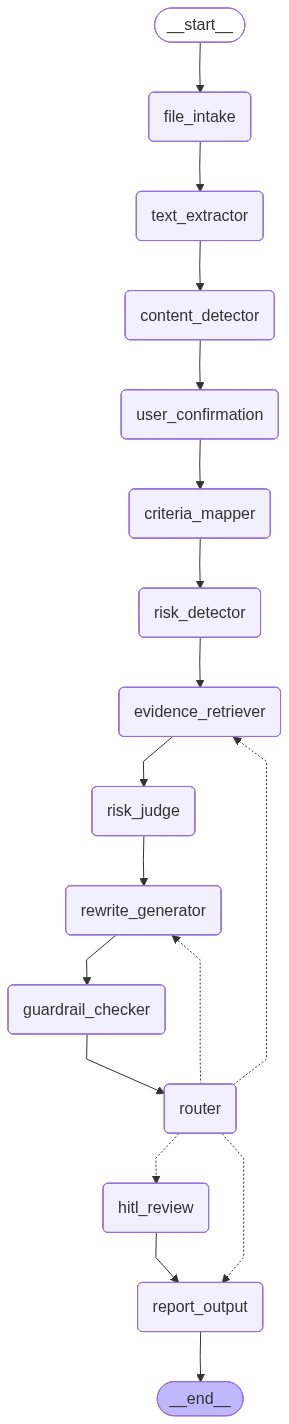

In [175]:
compliance_app

In [178]:
# ============================================================
# 실제 샘플 PDF End-to-End 실행 테스트
# 대상: medium_card_01.pdf
# 경로 자동 탐색 버전
# ============================================================

from pathlib import Path
from pprint import pprint

target_file_name = "high_loan_01.pdf"

# 1. 현재 작업 위치 확인
print("현재 작업 디렉터리:", Path.cwd())

# 2. 가능한 후보 경로들
candidate_paths = [
    Path("data/samples") / target_file_name,
    Path("./data/samples") / target_file_name,
    Path("../data/samples") / target_file_name,
    Path("../../data/samples") / target_file_name,
    Path("samples") / target_file_name,
]

# 3. 후보 경로 중 존재하는 파일 찾기
sample_pdf_path = None

for path in candidate_paths:
    print("check:", path, "->", path.exists())
    if path.exists():
        sample_pdf_path = path
        break

# 4. 그래도 못 찾으면 프로젝트 하위 전체 검색
if sample_pdf_path is None:
    search_roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
    ]

    for root in search_roots:
        matched_files = list(root.rglob(target_file_name))

        if matched_files:
            sample_pdf_path = matched_files[0]
            break

if sample_pdf_path is None:
    raise FileNotFoundError(
        f"{target_file_name} 파일을 찾을 수 없습니다. 현재 작업 위치: {Path.cwd()}"
    )

sample_pdf_path = sample_pdf_path.resolve()

print("\n사용할 PDF 경로:", sample_pdf_path)
print("파일 존재 여부:", sample_pdf_path.exists())

expected_result = {
    "expected_risk_level": "High",
    "expected_product_type": "loan",
    "expected_file_name": "high_loan_01.pdf",
}

initial_state: ComplianceState = {
    "file_path": str(sample_pdf_path),
    "uploaded_file": None,

    "errors": [],
    "warnings": [],
    "workflow_status": "initialized",
    "current_node": "start",

    "next_action": "report",
    "next_route": "",
    "retry_count": 0,
    "retrieval_retry_count": 0,
    "rewrite_retry_count": 0,
    "max_retry": 2,

    "action_required": False,
    "compliance_review_required": False,
    "review_required": False,
}

final_state = compliance_app.invoke(
    initial_state,
    config={"recursion_limit": 60},
)

print("=" * 80)
print("✅ End-to-End 실행 완료:", target_file_name)
print("=" * 80)

print("\n[workflow]")
print("workflow_status:", final_state.get("workflow_status"))
print("current_node:", final_state.get("current_node"))
print("next_action:", final_state.get("next_action"))
print("next_route:", final_state.get("next_route"))

print("\n[judgment]")
print("expected_risk_level:", expected_result["expected_risk_level"])
print("actual_risk_level:", final_state.get("risk_level"))
print("risk_reason:", final_state.get("risk_reason"))
print("action_required:", final_state.get("action_required"))
print("compliance_review_required:", final_state.get("compliance_review_required"))
print("review_required:", final_state.get("review_required"))
print("review_status:", final_state.get("review_status", "not_required"))

actual_risk_level = final_state.get("risk_level")

if actual_risk_level == expected_result["expected_risk_level"]:
    print("risk_level_match: PASS")
else:
    print("risk_level_match: CHECK_REQUIRED")

print("\n[guardrail]")
print("guardrail_status:", final_state.get("guardrail_status"))
print("needs_hitl:", final_state.get("needs_hitl"))
print("needs_rewrite:", final_state.get("needs_rewrite"))
print("needs_retrieval_retry:", final_state.get("needs_retrieval_retry"))

print("\n[routing]")
routing_detail = final_state.get("routing_detail", {})
print("route_case:", routing_detail.get("route_case"))
print("route_reason:", routing_detail.get("route_reason"))
print("retry_count:", final_state.get("retry_count", 0))
print("retrieval_retry_count:", final_state.get("retrieval_retry_count", 0))
print("rewrite_retry_count:", final_state.get("rewrite_retry_count", 0))
print("max_retry:", final_state.get("max_retry", 2))

print("\n[saved_result]")
saved_result = final_state.get("saved_result", {})
print("status:", saved_result.get("status"))
print("report_id:", saved_result.get("report_id"))
print("json_path:", saved_result.get("json_path"))
print("csv_path:", saved_result.get("csv_path"))
print("saved_at:", saved_result.get("saved_at"))
print("error:", saved_result.get("error"))

json_path = saved_result.get("json_path")
csv_path = saved_result.get("csv_path")

if json_path:
    print("json_exists:", Path(json_path).exists())

if csv_path:
    print("csv_exists:", Path(csv_path).exists())

print("\n[content]")
print("file_name:", final_state.get("file_name"))
print("file_type:", final_state.get("file_type"))
print("file_ext:", final_state.get("file_ext"))
print("product:", final_state.get("confirmed_product_type") or final_state.get("detected_product_type"))
print("channel:", final_state.get("confirmed_channel") or final_state.get("detected_channel"))
print("language:", final_state.get("confirmed_language") or final_state.get("detected_language"))
print("extraction_method:", final_state.get("extraction_method"))
print("extraction_confidence:", final_state.get("extraction_confidence"))

print("\n[counts]")
print("sentences:", len(final_state.get("sentences", [])))
print("detected_risks:", len(final_state.get("detected_risks", [])))
print("missing_disclaimers:", len(final_state.get("missing_disclaimers", [])))
print("evidence_list:", len(final_state.get("evidence_list", [])))

print("\n[detected_risks]")
for risk in final_state.get("detected_risks", []):
    print(
        "-",
        risk.get("risk_type"),
        "|",
        risk.get("keyword"),
        "|",
        risk.get("base_level"),
        "|",
        risk.get("reason"),
    )

print("\n[missing_disclaimers]")
for item in final_state.get("missing_disclaimers", []):
    print(
        "-",
        item.get("disclaimer"),
        "|",
        item.get("base_level", "Medium"),
        "|",
        item.get("reason"),
    )

print("\n[evidence]")
print("evidence_score:", final_state.get("evidence_score"))
print("evidence_quality:", final_state.get("evidence_quality"))

print("\n[rewrite]")
rewrite_detail = final_state.get("rewrite_detail", {})
print("rewrite_required:", rewrite_detail.get("rewrite_required"))
print("used_openai:", rewrite_detail.get("used_openai"))
print("polish_reason:", rewrite_detail.get("polish_reason"))
print("required_disclaimer:")
print(final_state.get("required_disclaimer", ""))

print("\n[rewrite_text_preview]")
print((final_state.get("rewrite_text", "") or "")[:1500])

print("\n[errors]")
if final_state.get("errors"):
    for error in final_state.get("errors", []):
        print("-", error)
else:
    print("없음")

print("\n[warnings]")
if final_state.get("warnings"):
    for warning in final_state.get("warnings", []):
        print("-", warning)
else:
    print("없음")

print("\n" + "=" * 80)
print("최종 판정")
print("=" * 80)

save_ok = saved_result.get("status") == "saved"
workflow_ok = final_state.get("workflow_status") == "completed"
action_ok = final_state.get("next_action") == "end"
route_ok = final_state.get("next_route") == "end"
risk_match = actual_risk_level == expected_result["expected_risk_level"]

print("save_ok:", save_ok)
print("workflow_ok:", workflow_ok)
print("action_ok:", action_ok)
print("route_ok:", route_ok)
print("risk_match:", risk_match)

if save_ok and workflow_ok and action_ok and route_ok and risk_match:
    print("RESULT: PASS")
else:
    print("RESULT: CHECK_REQUIRED")

현재 작업 디렉터리: c:\Users\USER\Desktop\complypilot-jb\notebooks
check: data\samples\high_loan_01.pdf -> False
check: data\samples\high_loan_01.pdf -> False
check: ..\data\samples\high_loan_01.pdf -> True

사용할 PDF 경로: C:\Users\USER\Desktop\complypilot-jb\data\samples\high_loan_01.pdf
파일 존재 여부: True
✅ End-to-End 실행 완료: high_loan_01.pdf

[workflow]
workflow_status: completed
current_node: report_builder
next_action: end
next_route: None

[judgment]
expected_risk_level: High
actual_risk_level: Pass
risk_reason: 위험 표현 및 필수 고지 누락 가능성이 뚜렷하게 탐지되지 않았습니다. 관련 근거 3건이 검색되었습니다. evidence_score=0.278, evidence_quality=weak
action_required: True
compliance_review_required: True
review_required: True
review_status: pending_human_review
risk_level_match: CHECK_REQUIRED

[guardrail]
guardrail_status: rewrite_needed
needs_hitl: True
needs_rewrite: True
needs_retrieval_retry: False

[routing]
route_case: rewrite_needed_or_legal_assertion
route_reason: 수정안에 위험 표현 또는 법률 단정 표현이 있어 Rewrite Generator 재작성을 수행합니다.
retr

In [168]:
# state 값 확인
final_state

{'current_node': 'text_extractor',
 'workflow_status': 'running',
 'updated_at': '2026-06-09T16:50:31',
 'errors': [],
 'warnings': [],
 'uploaded_file': None,
 'file_path': 'C:\\Users\\USER\\Desktop\\complypilot-jb\\data\\samples\\high_loan_01.pdf',
 'file_name': 'high_loan_01.pdf',
 'file_type': 'pdf',
 'file_ext': '.pdf',
 'mime_type': '',
 'file_size': 301162,
 'file_status': 'ok',
 'is_supported_file': True,
 'file_error': '',
 'input_mode': 'file_path',
 'raw_text': 'JB 금융그룹\nJB 누구나 승인 신용대출 안내문\n상품명\nJB 누구나 승인 신용대출\n상품 유형\n대출 (모바일 전용 신용대출)\n안내 채널\n모바일 앱 광고\n제공 언어\n한국어 (Korean)\nJB 누구나 승인 신용대출은 빠른 대출 실행을 원하는 고객을 위한 모바일 전용 신용대출 상품입니다. 복잡한 절차 없이\n앱에서 간편하게 신청할 수 있으며, 고객은 빠르게 한도와 금리를 확인할 수 있습니다. \n1. 대출 대상 및 자격 요건\n본 상품은 누구나 승인 가능한 100% 승인 대출입니다. 소득이 낮거나 기존 대출이 있어도 신청할 수 있으며, 간단한 본\n인 인증만으로 대출 가능 여부를 확인할 수 있습니다.\n2. 금리 및 수수료 혜택 안내\n업계 최저금리로 지금 바로 신청할 수 있으며, 모바일 신청 고객에게는 수수료 무료 혜택도 제공됩니다. 빠른 심사를 통\n해 당일 실행이 가능할 수 있고, 필요한 자금을 신속하게 마련할 수 있습니다.\n3. 대출 한도 및 상환 방식\n대출 한도는 고객이 입력한 정보에 따라 안내되